# Distribution of the learned user mask

Notebook này phân tích learned user-level scalar mask của `MASKED_GLORIA_EX`:

$$m_u = \sigma(\text{user\_mask\_logits}_u), \qquad a_u = 1-m_u.$$

Mục tiêu là kiểm tra $m_u$ có thực sự personalized hay gần như một global scalar $c$. Notebook chỉ đọc checkpoint; không cần khởi tạo model hoặc dataset.

## 1. Load `user_mask_logits` from the checkpoint

In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Markdown, display

CHECKPOINT_PATH = Path(
    r"C:\study\Master_papers\Robust MM\CaMuRe\saved\MASKED_GLORIA_EX-book-seed999-Aug-16-2026-09-43-18.pth"
)

if not CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(f"Checkpoint not found: {CHECKPOINT_PATH}")

# weights_only=True avoids unpickling arbitrary Python objects on recent PyTorch.
# The fallback keeps the notebook compatible with older PyTorch versions.
try:
    checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=True)
except TypeError:
    checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu")

if not isinstance(checkpoint, dict):
    raise TypeError(f"Expected a dictionary-like checkpoint, got {type(checkpoint).__name__}")

# Support a raw state_dict and common wrapped-checkpoint formats.
state_dict = checkpoint
for wrapper_key in ("state_dict", "model_state_dict", "model", "net"):
    candidate = checkpoint.get(wrapper_key)
    if isinstance(candidate, dict):
        state_dict = candidate
        break

mask_candidates = [
    (key, value)
    for key, value in state_dict.items()
    if str(key).endswith("user_mask_logits") and torch.is_tensor(value)
]

if len(mask_candidates) != 1:
    available_mask_keys = [str(key) for key in state_dict if "mask" in str(key).lower()]
    raise KeyError(
        f"Expected exactly one '*user_mask_logits' tensor, found {len(mask_candidates)}. "
        f"Mask-related keys: {available_mask_keys}"
    )

mask_key, user_mask_logits = mask_candidates[0]
user_mask_logits = user_mask_logits.detach().to(dtype=torch.float64, device="cpu").reshape(-1)
user_mask = torch.sigmoid(user_mask_logits)

if user_mask.numel() == 0 or not torch.isfinite(user_mask).all():
    raise ValueError("The learned user mask is empty or contains non-finite values.")

mask_values = user_mask.numpy()
attenuation_values = 1.0 - mask_values

print(f"Checkpoint : {CHECKPOINT_PATH}")
print(f"Tensor key : {mask_key}")
print(f"Users      : {mask_values.size:,}")

Checkpoint : C:\study\Master_papers\Robust MM\CaMuRe\saved\MASKED_GLORIA_EX-book-seed999-Aug-16-2026-09-43-18.pth
Tensor key : user_mask_logits
Users      : 11,000


## 2. Summary statistics and quantiles

`std` bên dưới là population standard deviation (`ddof=0`), nhất quán với `torch.std(unbiased=False)` trong model.

In [12]:
quantile_levels = np.array([0.10, 0.25, 0.50, 0.75, 0.90])

def summarize(values):
    quantiles = np.quantile(values, quantile_levels)
    return {
        "mean": np.mean(values),
        "std (ddof=0)": np.std(values, ddof=0),
        "min": np.min(values),
        "Q10": quantiles[0],
        "Q25": quantiles[1],
        "Q50": quantiles[2],
        "Q75": quantiles[3],
        "Q90": quantiles[4],
        "max": np.max(values),
    }

def show_markdown_table(headers, rows):
    header = "| " + " | ".join(headers) + " |"
    separator = "| " + " | ".join(["---"] * len(headers)) + " |"
    body = ["| " + " | ".join(map(str, row)) + " |" for row in rows]
    display(Markdown("\n".join([header, separator, *body])))

stat_names = ["mean", "std (ddof=0)", "min", "Q10", "Q25", "Q50", "Q75", "Q90", "max"]
summary_rows = []
for label, values in ((r"mask $m_u$", mask_values), (r"attenuation $a_u = 1-m_u$", attenuation_values)):
    stats = summarize(values)
    summary_rows.append([label, *[f"{stats[name]:.8f}" for name in stat_names]])

show_markdown_table(["quantity", *stat_names], summary_rows)

| quantity | mean | std (ddof=0) | min | Q10 | Q25 | Q50 | Q75 | Q90 | max |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| mask $m_u$ | 0.99146787 | 0.01474961 | 0.75212465 | 0.98844911 | 0.99216531 | 0.99427786 | 0.99572500 | 0.99683304 | 0.99918599 |
| attenuation $a_u = 1-m_u$ | 0.00853213 | 0.01474961 | 0.00081401 | 0.00316696 | 0.00427500 | 0.00572214 | 0.00783469 | 0.01155089 | 0.24787535 |

## 3. How close is the mask to a global scalar?

Global scalar tốt nhất theo mean squared error là $c = \operatorname{mean}(m_u)$, và $\operatorname{RMSE}(m_u,c) = \operatorname{std}(m_u)$. Xem thêm IQR và $Q_{90}-Q_{10}$ để tránh kết luận chỉ dựa trên một vài outlier.

In [13]:
q10, q25, q50, q75, q90 = np.quantile(mask_values, quantile_levels)
global_scalar = mask_values.mean()
diagnostic_rows = [
    [r"best global scalar $c = \mathrm{mean}(m_u)$", f"{global_scalar:.8f}"],
    [r"RMSE from $c$ (= population std)", f"{np.sqrt(np.mean((mask_values - global_scalar) ** 2)):.8f}"],
    [r"MAE from $c$", f"{np.mean(np.abs(mask_values - global_scalar)):.8f}"],
    [r"IQR = Q75 - Q25", f"{q75 - q25:.8f}"],
    [r"central spread = Q90 - Q10", f"{q90 - q10:.8f}"],
    [r"full range = max - min", f"{mask_values.max() - mask_values.min():.8f}"],
    [r"coefficient of variation = std / mean", f"{mask_values.std(ddof=0) / global_scalar:.8f}"],
]
show_markdown_table(["diagnostic", "value"], diagnostic_rows)

tolerances = np.array([0.001, 0.005, 0.010, 0.050])
tolerance_rows = [
    [f"{tol:.3f}", f"{np.mean(np.abs(mask_values - q50) <= tol):.2%}"]
    for tol in tolerances
]
show_markdown_table(["absolute tolerance around median", "fraction of users"], tolerance_rows)

| diagnostic | value |
| --- | --- |
| best global scalar $c = \mathrm{mean}(m_u)$ | 0.99146787 |
| RMSE from $c$ (= population std) | 0.01474961 |
| MAE from $c$ | 0.00541025 |
| IQR = Q75 - Q25 | 0.00355969 |
| central spread = Q90 - Q10 | 0.00838392 |
| full range = max - min | 0.24706134 |
| coefficient of variation = std / mean | 0.01487654 |

| absolute tolerance around median | fraction of users |
| --- | --- |
| 0.001 | 31.71% |
| 0.005 | 88.25% |
| 0.010 | 94.17% |
| 0.050 | 98.20% |

## 4. Distribution plots

Hai histogram full-range giữ trục $[0,1]$ để không phóng đại variation. Zoom trung tâm 98% và sorted curve giúp nhìn rõ personalization khi phần lớn giá trị tập trung trong một vùng hẹp.

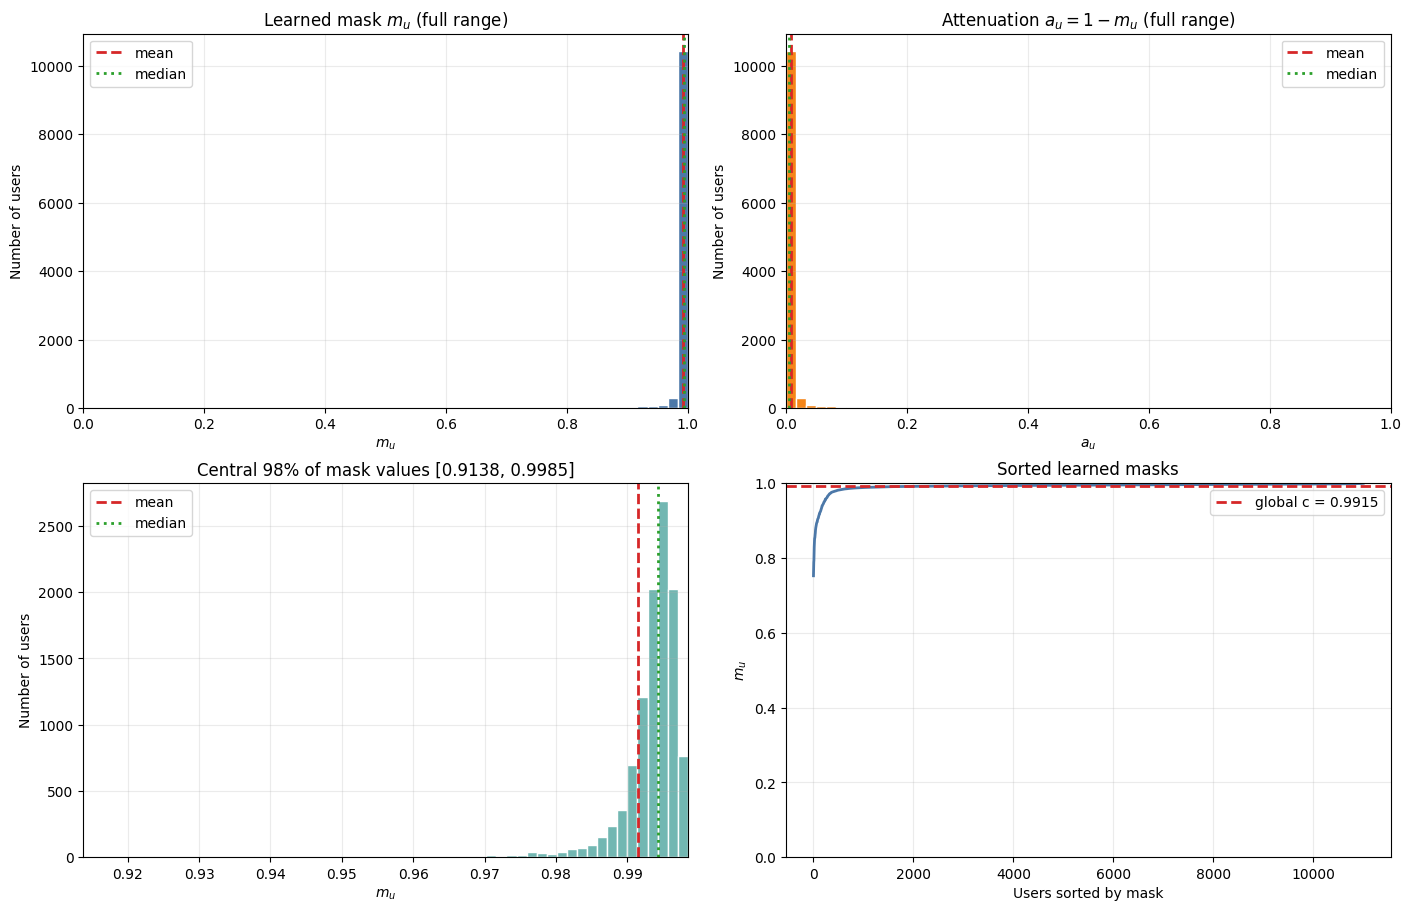

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)

def add_reference_lines(ax, values):
    ax.axvline(np.mean(values), color="#d62728", linestyle="--", linewidth=2, label="mean")
    ax.axvline(np.median(values), color="#2ca02c", linestyle=":", linewidth=2, label="median")
    ax.legend()

axes[0, 0].hist(mask_values, bins=60, range=(0, 1), color="#4c78a8", edgecolor="white")
add_reference_lines(axes[0, 0], mask_values)
axes[0, 0].set(title=r"Learned mask $m_u$ (full range)", xlabel=r"$m_u$", ylabel="Number of users", xlim=(0, 1))

axes[0, 1].hist(attenuation_values, bins=60, range=(0, 1), color="#f58518", edgecolor="white")
add_reference_lines(axes[0, 1], attenuation_values)
axes[0, 1].set(title=r"Attenuation $a_u = 1-m_u$ (full range)", xlabel=r"$a_u$", ylabel="Number of users", xlim=(0, 1))

zoom_low, zoom_high = np.quantile(mask_values, [0.01, 0.99])
if np.isclose(zoom_low, zoom_high):
    zoom_low = max(0.0, zoom_low - 0.01)
    zoom_high = min(1.0, zoom_high + 0.01)
axes[1, 0].hist(mask_values, bins=60, range=(zoom_low, zoom_high), color="#72b7b2", edgecolor="white")
add_reference_lines(axes[1, 0], mask_values)
axes[1, 0].set(
    title=f"Central 98% of mask values [{zoom_low:.4f}, {zoom_high:.4f}]",
    xlabel=r"$m_u$",
    ylabel="Number of users",
    xlim=(zoom_low, zoom_high),
)

sorted_mask = np.sort(mask_values)
axes[1, 1].plot(np.arange(sorted_mask.size), sorted_mask, color="#4c78a8", linewidth=2)
axes[1, 1].axhline(global_scalar, color="#d62728", linestyle="--", linewidth=2, label=f"global c = {global_scalar:.4f}")
axes[1, 1].set(title="Sorted learned masks", xlabel="Users sorted by mask", ylabel=r"$m_u$", ylim=(0, 1))
axes[1, 1].legend()

for ax in axes.flat:
    ax.grid(alpha=0.25)

plt.show()

## 5. Mask vs user degree

Training rows       : 120,464
Unique train edges : 120,464
Users analyzed     : 11,000 / 11,000
Spearman rho(degree, 1 - m_u) = -0.685311
Two-sided p-value                = 0.000e+00


| degree group | users | mean degree | $E[1-m_u \mid group]$ | std$(1-m_u)$ | $E[m_u \mid group]$ |
| --- | --- | --- | --- | --- | --- |
| 1–5 | 3,631 | 3.88 | 0.01324649 | 0.02115116 | 0.98675351 |
| 6–20 | 6,215 | 9.64 | 0.00673659 | 0.00982207 | 0.99326341 |
| 21–50 | 902 | 30.09 | 0.00377688 | 0.00638088 | 0.99622312 |
| 51+ | 252 | 76.71 | 0.00190791 | 0.00078942 | 0.99809209 |

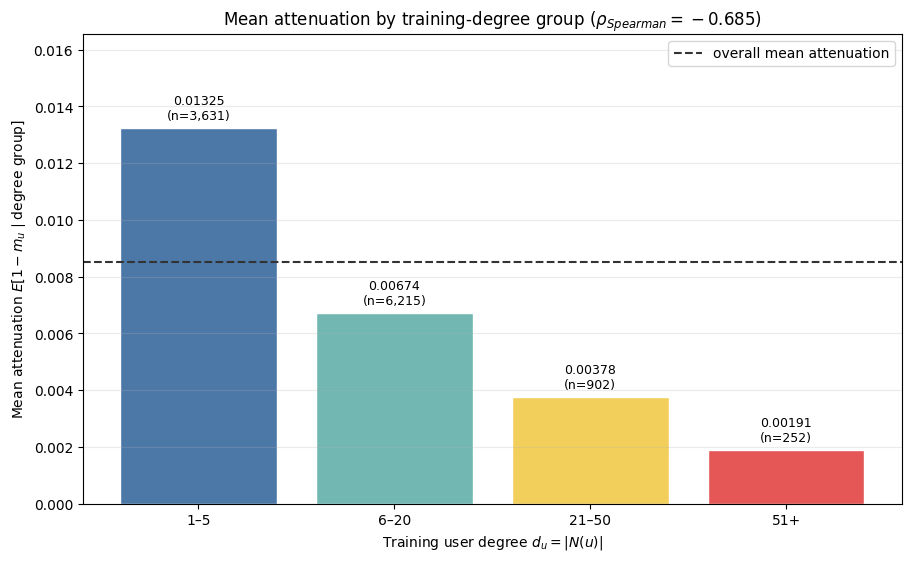

**Observed direction:** Attenuation tends to decrease with degree: this checkpoint compresses low-degree users more, the opposite of the active-user-compression hypothesis.

In [15]:
display(Markdown("## 5. Mask vs user degree"))

import csv
from scipy.stats import spearmanr

INTERACTION_PATH = Path(r"C:\study\Master_papers\Robust MM\CaMuRe\data\book\book.inter")
TRAIN_SPLIT_LABEL = 0

if not INTERACTION_PATH.is_file():
    raise FileNotFoundError(f"Interaction file not found: {INTERACTION_PATH}")

# The model graph is constructed from dataset.inter_matrix() on the training split.
# Count unique item neighbors so d_u is exactly |N(u)|.
train_neighbors = [set() for _ in range(mask_values.size)]
train_row_count = 0
with INTERACTION_PATH.open("r", encoding="utf-8", newline="") as handle:
    reader = csv.DictReader(handle, delimiter="\t")
    required_columns = {"userID", "itemID", "x_label"}
    missing_columns = required_columns.difference(reader.fieldnames or [])
    if missing_columns:
        raise KeyError(f"Missing columns in interaction file: {sorted(missing_columns)}")

    for row in reader:
        if int(row["x_label"]) != TRAIN_SPLIT_LABEL:
            continue
        user_id = int(row["userID"])
        item_id = int(row["itemID"])
        if not 0 <= user_id < mask_values.size:
            raise IndexError(
                f"Training userID {user_id} is outside mask indices [0, {mask_values.size - 1}]."
            )
        train_neighbors[user_id].add(item_id)
        train_row_count += 1

user_degree = np.fromiter((len(items) for items in train_neighbors), dtype=np.int64, count=mask_values.size)
unique_edge_count = int(user_degree.sum())
valid_users = user_degree >= 1

if not valid_users.all():
    print(f"Warning: excluding {(~valid_users).sum():,} zero-degree users from this analysis.")
if unique_edge_count != train_row_count:
    print(f"Note: collapsed {train_row_count - unique_edge_count:,} duplicate training rows to unique neighbors.")

rho, p_value = spearmanr(user_degree[valid_users], attenuation_values[valid_users])
print(f"Training rows       : {train_row_count:,}")
print(f"Unique train edges : {unique_edge_count:,}")
print(f"Users analyzed     : {valid_users.sum():,} / {mask_values.size:,}")
print(f"Spearman rho(degree, 1 - m_u) = {rho:.6f}")
print(f"Two-sided p-value                = {p_value:.3e}")

degree_group_labels = ["1–5", "6–20", "21–50", "51+"]
degree_group_masks = [
    valid_users & (user_degree <= 5),
    (user_degree >= 6) & (user_degree <= 20),
    (user_degree >= 21) & (user_degree <= 50),
    user_degree >= 51,
]

group_rows = []
group_means = []
group_counts = []
for label, group_mask in zip(degree_group_labels, degree_group_masks):
    count = int(group_mask.sum())
    if count == 0:
        mean_degree = mean_attenuation = std_attenuation = mean_mask = np.nan
    else:
        mean_degree = user_degree[group_mask].mean()
        mean_attenuation = attenuation_values[group_mask].mean()
        std_attenuation = attenuation_values[group_mask].std(ddof=0)
        mean_mask = mask_values[group_mask].mean()
    group_counts.append(count)
    group_means.append(mean_attenuation)
    group_rows.append(
        [label, f"{count:,}", f"{mean_degree:.2f}", f"{mean_attenuation:.8f}", f"{std_attenuation:.8f}", f"{mean_mask:.8f}"]
    )

show_markdown_table(
    ["degree group", "users", "mean degree", r"$E[1-m_u \mid group]$", r"std$(1-m_u)$", r"$E[m_u \mid group]$"],
    group_rows,
)

fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)
bars = ax.bar(degree_group_labels, group_means, color=["#4c78a8", "#72b7b2", "#f2cf5b", "#e45756"], edgecolor="white")
ax.axhline(attenuation_values[valid_users].mean(), color="#333333", linestyle="--", linewidth=1.5, label="overall mean attenuation")
ax.bar_label(
    bars,
    labels=[f"{mean:.5f}\n(n={count:,})" if np.isfinite(mean) else "no users" for mean, count in zip(group_means, group_counts)],
    padding=4,
    fontsize=9,
)
finite_group_means = np.asarray(group_means)[np.isfinite(group_means)]
if finite_group_means.size:
    ax.set_ylim(0, max(finite_group_means.max(), attenuation_values[valid_users].mean()) * 1.25)
ax.set(
    title=rf"Mean attenuation by training-degree group ($\rho_{{Spearman}}={rho:.3f}$)",
    xlabel=r"Training user degree $d_u = |N(u)|$",
    ylabel=r"Mean attenuation $E[1-m_u \mid \mathrm{degree\ group}]$",
)
ax.grid(axis="y", alpha=0.25)
ax.legend()
plt.show()

if rho > 0:
    direction_note = (
        r"Attenuation tends to increase with degree: this checkpoint compresses more-active users more."
    )
elif rho < 0:
    direction_note = (
        r"Attenuation tends to decrease with degree: this checkpoint compresses low-degree users more, "
        r"the opposite of the active-user-compression hypothesis."
    )
else:
    direction_note = r"There is no monotonic degree–attenuation direction in this checkpoint."

display(Markdown(f"**Observed direction:** {direction_note}"))

## 6. Degree-matched analysis (Analysis 3)

| degree window | users | mean | std | min | Q10 | Q50 | Q90 | max | Q90 - Q10 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 1–5 | 3,631 | 0.98675351 | 0.02115116 | 0.75212465 | 0.98123071 | 0.99216000 | 0.99481107 | 0.99673562 | 0.01358036 |
| 6–10 | 4,261 | 0.99273490 | 0.00994531 | 0.77703295 | 0.99065492 | 0.99435218 | 0.99599706 | 0.99750661 | 0.00534214 |
| 11–15 | 1,315 | 0.99410935 | 0.01015945 | 0.76030514 | 0.99290149 | 0.99557875 | 0.99680447 | 0.99779677 | 0.00390298 |
| 16–20 | 639 | 0.99504673 | 0.00773562 | 0.87994851 | 0.99374976 | 0.99608988 | 0.99726935 | 0.99806991 | 0.00351959 |
| 21–25 | 347 | 0.99567394 | 0.00601020 | 0.92404432 | 0.99470913 | 0.99672068 | 0.99763686 | 0.99835607 | 0.00292773 |
| 26–30 | 195 | 0.99560541 | 0.00924599 | 0.91454102 | 0.99537292 | 0.99705674 | 0.99798538 | 0.99846071 | 0.00261247 |
| 31–40 | 234 | 0.99681345 | 0.00543768 | 0.91541416 | 0.99598632 | 0.99744985 | 0.99817641 | 0.99862093 | 0.00219008 |
| 41–50 | 126 | 0.99759517 | 0.00090857 | 0.99376906 | 0.99647107 | 0.99781175 | 0.99843147 | 0.99886881 | 0.00196040 |
| 51+ | 252 | 0.99809209 | 0.00078942 | 0.99468084 | 0.99708086 | 0.99830880 | 0.99883830 | 0.99918599 | 0.00175744 |

**Window $20 \leq d_u \leq 30$:** 640 users; $m_u$ ranges from **0.91454102** (user 40, degree 29) to **0.99846071** (user 4623, degree 27). The central 80% span $Q_{90}-Q_{10}$ is **0.00291835**.

| exact degree | users | min | Q10 | Q50 | Q90 | max | full range | Q90 - Q10 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 20 | 98 | 0.99242755 | 0.99476575 | 0.99634658 | 0.99754107 | 0.99792349 | 0.00549594 | 0.00277532 |
| 21 | 106 | 0.95712461 | 0.99360834 | 0.99651451 | 0.99754090 | 0.99829616 | 0.04117155 | 0.00393256 |
| 22 | 65 | 0.94637866 | 0.99517407 | 0.99676755 | 0.99774201 | 0.99801071 | 0.05163205 | 0.00256794 |
| 23 | 81 | 0.96587548 | 0.99469786 | 0.99667868 | 0.99756041 | 0.99785033 | 0.03197485 | 0.00286255 |
| 24 | 46 | 0.99181008 | 0.99513122 | 0.99689713 | 0.99760061 | 0.99809504 | 0.00628496 | 0.00246939 |
| 25 | 49 | 0.92404432 | 0.99496465 | 0.99689336 | 0.99772035 | 0.99835607 | 0.07431175 | 0.00275570 |
| 26 | 44 | 0.99080703 | 0.99572152 | 0.99682907 | 0.99770368 | 0.99790099 | 0.00709396 | 0.00198216 |
| 27 | 40 | 0.94911687 | 0.99551773 | 0.99710996 | 0.99819529 | 0.99846071 | 0.04934384 | 0.00267756 |
| 28 | 45 | 0.92934890 | 0.99464883 | 0.99684050 | 0.99788648 | 0.99828169 | 0.06893279 | 0.00323764 |
| 29 | 34 | 0.91454102 | 0.99621168 | 0.99737945 | 0.99791827 | 0.99829153 | 0.08375051 | 0.00170659 |
| 30 | 32 | 0.99083606 | 0.99577440 | 0.99751595 | 0.99817801 | 0.99835781 | 0.00752175 | 0.00240361 |

**Strict degree match:** among exact degrees 20–30, $d_u=29$ has the largest observed full range. User 40 has $m_u=0.91454102$ while user 1222 has $m_u=0.99829153$, despite identical degree. This is evidence of user-level variation beyond activity, but the full range is driven by extremes.

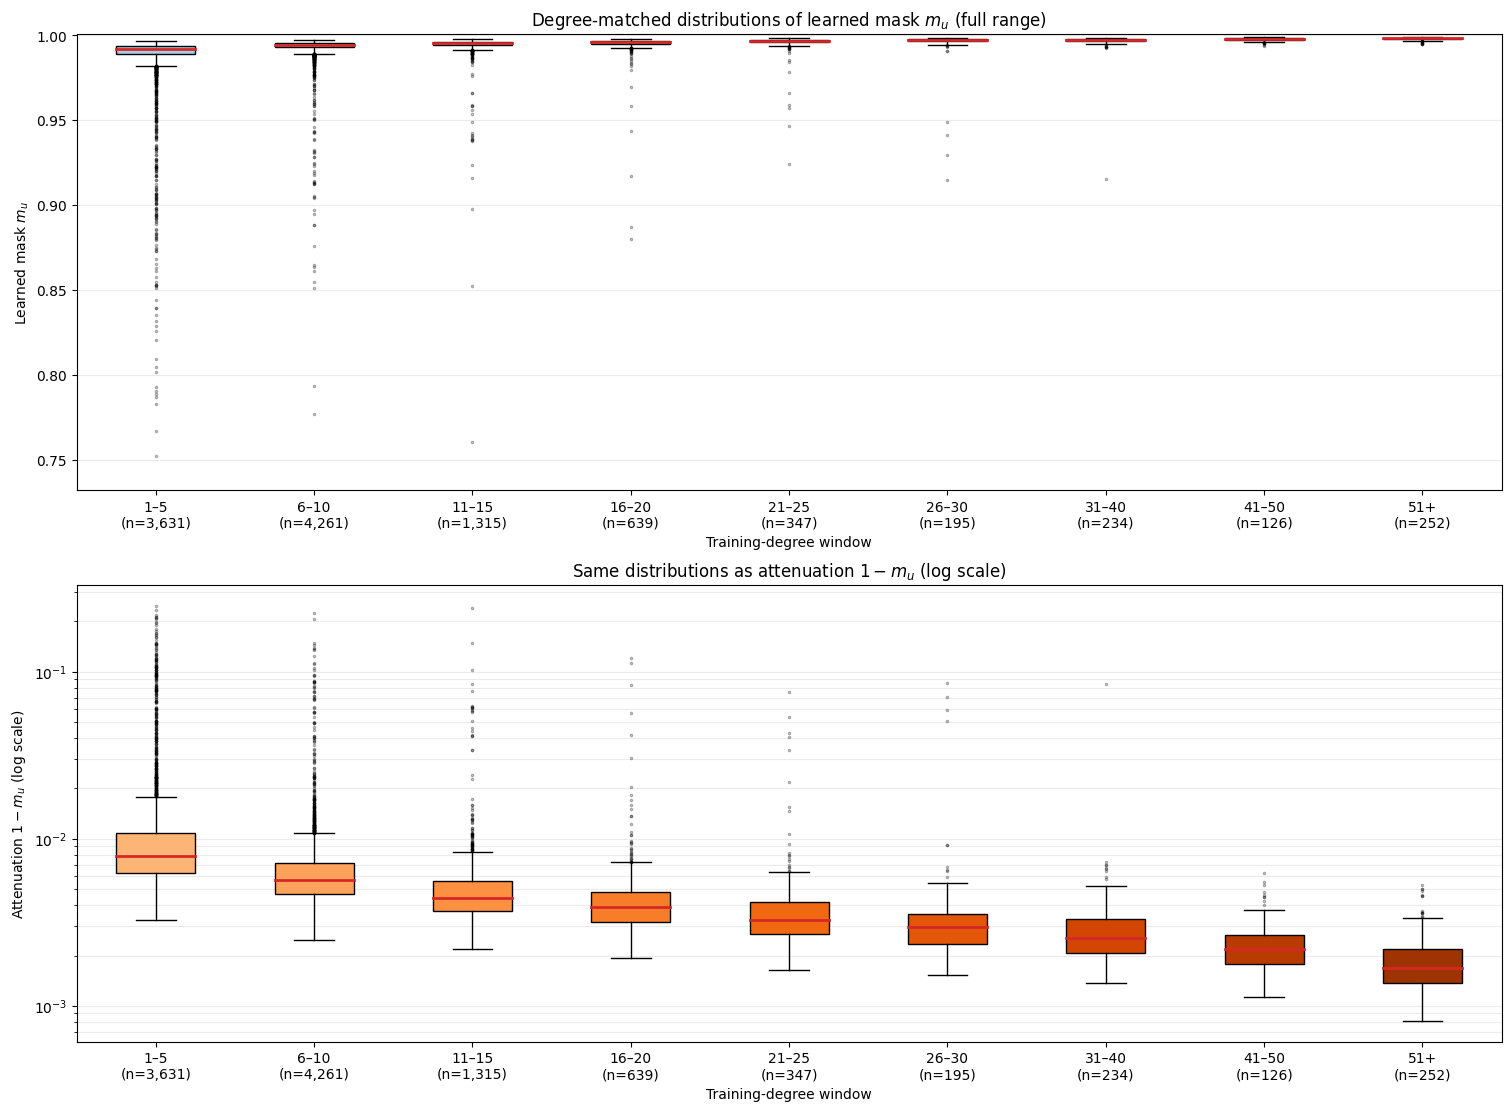

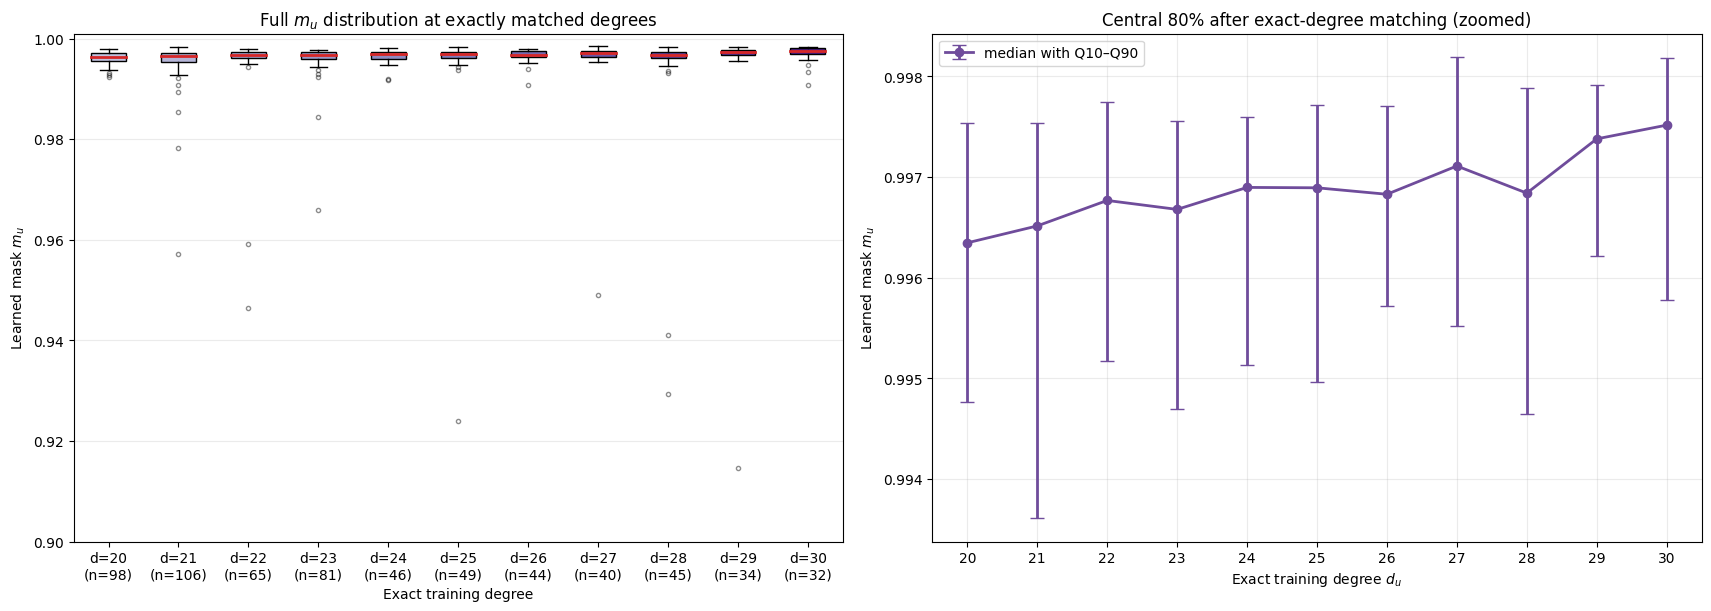

In [16]:
display(Markdown("## 6. Degree-matched analysis (Analysis 3)"))

# Narrow, non-overlapping degree windows spanning the dataset.
matched_group_specs = [
    ("1–5", 1, 5),
    ("6–10", 6, 10),
    ("11–15", 11, 15),
    ("16–20", 16, 20),
    ("21–25", 21, 25),
    ("26–30", 26, 30),
    ("31–40", 31, 40),
    ("41–50", 41, 50),
    ("51+", 51, None),
]

def degree_window_mask(low, high):
    selected = user_degree >= low
    if high is not None:
        selected &= user_degree <= high
    return selected

def distribution_statistics(values):
    q10, q25, q50, q75, q90 = np.quantile(values, [0.10, 0.25, 0.50, 0.75, 0.90])
    return {
        "mean": values.mean(),
        "std": values.std(ddof=0),
        "min": values.min(),
        "Q10": q10,
        "Q25": q25,
        "Q50": q50,
        "Q75": q75,
        "Q90": q90,
        "max": values.max(),
        "Q90 - Q10": q90 - q10,
    }

matched_labels = []
matched_masks = []
matched_attenuations = []
matched_rows = []
for label, low, high in matched_group_specs:
    selected = degree_window_mask(low, high)
    values = mask_values[selected]
    if values.size == 0:
        continue
    stats = distribution_statistics(values)
    matched_labels.append(label)
    matched_masks.append(values)
    matched_attenuations.append(1.0 - values)
    matched_rows.append(
        [
            label, f"{values.size:,}", f"{stats['mean']:.8f}", f"{stats['std']:.8f}",
            f"{stats['min']:.8f}", f"{stats['Q10']:.8f}", f"{stats['Q50']:.8f}",
            f"{stats['Q90']:.8f}", f"{stats['max']:.8f}", f"{stats['Q90 - Q10']:.8f}",
        ]
    )

show_markdown_table(
    ["degree window", "users", "mean", "std", "min", "Q10", "Q50", "Q90", "max", "Q90 - Q10"],
    matched_rows,
)

# Requested example: all users in the same 20 <= d_u <= 30 window.
requested_window = (user_degree >= 20) & (user_degree <= 30)
requested_user_ids = np.flatnonzero(requested_window)
requested_values = mask_values[requested_window]
requested_stats = distribution_statistics(requested_values)
requested_min_user = requested_user_ids[np.argmin(requested_values)]
requested_max_user = requested_user_ids[np.argmax(requested_values)]

display(
    Markdown(
        f"**Window $20 \leq d_u \leq 30$:** {requested_values.size:,} users; "
        f"$m_u$ ranges from **{requested_stats['min']:.8f}** "
        f"(user {requested_min_user}, degree {user_degree[requested_min_user]}) to "
        f"**{requested_stats['max']:.8f}** "
        f"(user {requested_max_user}, degree {user_degree[requested_max_user]}). "
        f"The central 80% span $Q_{{90}}-Q_{{10}}$ is **{requested_stats['Q90 - Q10']:.8f}**."
    )
)

# Strict matching: compare users with exactly the same degree from 20 through 30.
exact_degrees = np.arange(20, 31)
exact_degree_masks = [mask_values[user_degree == degree] for degree in exact_degrees]
exact_degree_rows = []
exact_degree_stats = []
for degree, values in zip(exact_degrees, exact_degree_masks):
    stats = distribution_statistics(values)
    exact_degree_stats.append(stats)
    exact_degree_rows.append(
        [
            str(degree), f"{values.size:,}", f"{stats['min']:.8f}", f"{stats['Q10']:.8f}",
            f"{stats['Q50']:.8f}", f"{stats['Q90']:.8f}", f"{stats['max']:.8f}",
            f"{stats['max'] - stats['min']:.8f}", f"{stats['Q90 - Q10']:.8f}",
        ]
    )

show_markdown_table(
    ["exact degree", "users", "min", "Q10", "Q50", "Q90", "max", "full range", "Q90 - Q10"],
    exact_degree_rows,
)

# Descriptive exact-degree counterexample. Full range is outlier-sensitive, so report central spread too.
exact_full_ranges = np.array([stats['max'] - stats['min'] for stats in exact_degree_stats])
widest_index = int(np.argmax(exact_full_ranges))
widest_degree = int(exact_degrees[widest_index])
widest_user_ids = np.flatnonzero(user_degree == widest_degree)
widest_values = mask_values[user_degree == widest_degree]
low_user = widest_user_ids[np.argmin(widest_values)]
high_user = widest_user_ids[np.argmax(widest_values)]
display(
    Markdown(
        f"**Strict degree match:** among exact degrees 20–30, $d_u={widest_degree}$ has the largest observed "
        f"full range. User {low_user} has $m_u={mask_values[low_user]:.8f}$ while user {high_user} "
        f"has $m_u={mask_values[high_user]:.8f}$, despite identical degree. "
        f"This is evidence of user-level variation beyond activity, but the full range is driven by extremes."
    )
)

# Matplotlib renamed boxplot's 'labels' argument to 'tick_labels'.
# This wrapper supports both the project's older kernel and newer Matplotlib.
def boxplot_with_labels(ax, data, tick_labels, **kwargs):
    try:
        return ax.boxplot(data, tick_labels=tick_labels, **kwargs)
    except TypeError:
        return ax.boxplot(data, labels=tick_labels, **kwargs)

# Plot 1: distributions across narrow degree windows.
plot_labels = [f"{label}\n(n={values.size:,})" for label, values in zip(matched_labels, matched_masks)]
fig, axes = plt.subplots(2, 1, figsize=(15, 11), constrained_layout=True)

mask_box = boxplot_with_labels(
    axes[0], matched_masks, plot_labels, patch_artist=True, showfliers=True,
    medianprops={"color": "#d62728", "linewidth": 2},
    flierprops={"marker": ".", "markersize": 3, "alpha": 0.35},
)
for patch, color in zip(mask_box["boxes"], plt.cm.Blues(np.linspace(0.35, 0.90, len(matched_masks)))):
    patch.set_facecolor(color)
axes[0].set(
    title=r"Degree-matched distributions of learned mask $m_u$ (full range)",
    xlabel=r"Training-degree window", ylabel=r"Learned mask $m_u$", ylim=(max(0, mask_values.min() - 0.02), 1.001),
)
axes[0].grid(axis="y", alpha=0.25)

attenuation_box = boxplot_with_labels(
    axes[1], matched_attenuations, plot_labels, patch_artist=True, showfliers=True,
    medianprops={"color": "#d62728", "linewidth": 2},
    flierprops={"marker": ".", "markersize": 3, "alpha": 0.35},
)
for patch, color in zip(attenuation_box["boxes"], plt.cm.Oranges(np.linspace(0.35, 0.90, len(matched_attenuations)))):
    patch.set_facecolor(color)
axes[1].set_yscale("log")
axes[1].set(
    title=r"Same distributions as attenuation $1-m_u$ (log scale)",
    xlabel=r"Training-degree window", ylabel=r"Attenuation $1-m_u$ (log scale)",
)
axes[1].grid(axis="y", which="both", alpha=0.25)
plt.show()

# Plot 2: strict exact-degree matching for d_u = 20, ..., 30.
fig, axes = plt.subplots(1, 2, figsize=(17, 6), constrained_layout=True)
exact_labels = [f"d={degree}\n(n={values.size})" for degree, values in zip(exact_degrees, exact_degree_masks)]
exact_box = boxplot_with_labels(
    axes[0], exact_degree_masks, exact_labels, patch_artist=True, showfliers=True,
    medianprops={"color": "#d62728", "linewidth": 2},
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.45},
)
for patch, color in zip(exact_box["boxes"], plt.cm.Purples(np.linspace(0.35, 0.90, len(exact_degree_masks)))):
    patch.set_facecolor(color)
axes[0].set(
    title=r"Full $m_u$ distribution at exactly matched degrees",
    xlabel=r"Exact training degree", ylabel=r"Learned mask $m_u$", ylim=(0.90, 1.001),
)
axes[0].grid(axis="y", alpha=0.25)

exact_q10 = np.array([stats['Q10'] for stats in exact_degree_stats])
exact_q50 = np.array([stats['Q50'] for stats in exact_degree_stats])
exact_q90 = np.array([stats['Q90'] for stats in exact_degree_stats])
axes[1].errorbar(
    exact_degrees, exact_q50, yerr=np.vstack((exact_q50 - exact_q10, exact_q90 - exact_q50)),
    fmt="o-", color="#6f4c9b", capsize=5, linewidth=2, label="median with Q10–Q90",
)
axes[1].set(
    title=r"Central 80% after exact-degree matching (zoomed)",
    xlabel=r"Exact training degree $d_u$", ylabel=r"Learned mask $m_u$", xticks=exact_degrees,
)
axes[1].grid(alpha=0.25)
axes[1].legend()
plt.show()

In [17]:
display(Markdown("## 7. User-mask permutation test (Analysis 4)"))

import os
import sys
import time

# 100 gives a minimum attainable one-sided permutation p-value of 1 / 101 ≈ 0.0099.
# Increase to 500 for a minimum p-value of 1 / 501 ≈ 0.0020.
N_PERMUTATIONS = 500
PERMUTATION_SEED = 20260816
REPORT_METRICS = ("Recall@20", "NDCG@20", "Precision@20", "MAP@20")

PROJECT_ROOT = Path(r"C:\study\Master_papers\Robust MM\CaMuRe")
PROJECT_SRC = PROJECT_ROOT / "src"
if str(PROJECT_SRC) not in sys.path:
    sys.path.insert(0, str(PROJECT_SRC))

from utils.configurator import Config
from utils.dataset import RecDataset
from utils.dataloader import EvalDataLoader, TrainDataLoader
from utils.metrics import metrics_dict
from utils.utils import get_model

permutation_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if permutation_device.type == "cpu":
    print("Warning: CUDA is unavailable; 100–500 full-ranking permutations may be slow on CPU.")
print(f"Permutation-test device: {permutation_device}")

# These are the settings used by src/main.py for this checkpoint.
# Architecture-related list values from overall.yaml are resolved to their first/only search value below.
config_overrides = {
    "dropout": [0.2],
    "reg_weight": [0.001],
    "learning_rate": [0.003],
    "gpu_id": 0,
    "fusion": "add",
    "save_recommended_topk": False,
}

original_working_directory = Path.cwd()
try:
    # Config resolves src/configs and data/ relative to the project root.
    os.chdir(PROJECT_ROOT)
    permutation_config = Config("MASKED_GLORIA_EX", "book", config_overrides)
    for hyperparameter in permutation_config["hyper_parameters"]:
        value = permutation_config[hyperparameter]
        if isinstance(value, (list, tuple)):
            if len(value) != 1:
                raise ValueError(
                    f"Expected one saved-run value for {hyperparameter}, got {value}. "
                    "Set it explicitly before running the permutation test."
                )
            permutation_config[hyperparameter] = value[0]
    permutation_config["device"] = permutation_device
    permutation_config["save_recommended_topk"] = False

    permutation_dataset = RecDataset(permutation_config)
    permutation_train_dataset, _, permutation_test_dataset = permutation_dataset.split()
    permutation_train_data = TrainDataLoader(
        permutation_config, permutation_train_dataset,
        batch_size=permutation_config["train_batch_size"], shuffle=False,
    )
    permutation_test_data = EvalDataLoader(
        permutation_config, permutation_test_dataset,
        additional_dataset=permutation_train_dataset,
        batch_size=permutation_config["eval_batch_size"],
    )
    permutation_model = get_model("MASKED_GLORIA_EX")(
        permutation_config, permutation_train_data
    ).to(permutation_device)
finally:
    os.chdir(original_working_directory)

# During training, forward() also registers the returned GCN preference Parameters under
# top-level aliases. A fresh model exposes them at their nested module locations until its
# first forward pass, so map the checkpoint aliases back to those same Parameters.
checkpoint_parameter_aliases = {
    "full_preference": "full_gcn.preference",
    "mask_preference": "mask_gcn.preference",
}
raw_parameter_state = checkpoint.get("state_dict", checkpoint)
if not isinstance(raw_parameter_state, dict):
    raise TypeError("Checkpoint does not contain a dictionary-like state_dict.")
permutation_parameter_state = {}
for raw_name, tensor in raw_parameter_state.items():
    clean_name = str(raw_name)
    if clean_name.startswith("module."):
        clean_name = clean_name[len("module."):]
    clean_name = checkpoint_parameter_aliases.get(clean_name, clean_name)
    permutation_parameter_state[clean_name] = tensor

model_parameters = dict(permutation_model.named_parameters())
missing_parameters = sorted(set(model_parameters) - set(permutation_parameter_state))
unexpected_parameters = sorted(set(permutation_parameter_state) - set(model_parameters))
if missing_parameters or unexpected_parameters:
    raise KeyError(
        f"Checkpoint/model parameter mismatch. Missing={missing_parameters}; "
        f"unexpected={unexpected_parameters}"
    )

with torch.no_grad():
    for name, parameter in model_parameters.items():
        saved_tensor = permutation_parameter_state[name]
        if tuple(saved_tensor.shape) != tuple(parameter.shape):
            raise ValueError(
                f"Shape mismatch for {name}: checkpoint {tuple(saved_tensor.shape)} "
                f"vs model {tuple(parameter.shape)}"
            )
        parameter.copy_(saved_tensor.to(device=parameter.device, dtype=parameter.dtype))

# Freeze every parameter. The only mutation below is an explicit no-grad copy into user_mask_logits.
permutation_model.eval()
for parameter in permutation_model.parameters():
    parameter.requires_grad_(False)
learned_user_mask_logits = permutation_model.user_mask_logits.detach().clone()
if learned_user_mask_logits.numel() != mask_values.size:
    raise ValueError(
        f"Model has {learned_user_mask_logits.numel()} user masks but the analysis loaded {mask_values.size}."
    )

test_positive_sets = [
    set(map(int, positive_items))
    for positive_items in permutation_test_data.get_eval_items()
]
test_positive_lengths = np.asarray(permutation_test_data.get_eval_len_list())
report_k = max(int(metric_name.split("@")[1]) for metric_name in REPORT_METRICS)
if report_k > max(permutation_config["topk"]):
    raise ValueError("REPORT_METRICS requests a K larger than the configured evaluation top-k.")

def recompute_result_embedding():
    # full_sort_predict() reads result_embed cached by forward(), so this is mandatory after every shuffle.
    dummy_index = torch.zeros(1, dtype=torch.long, device=permutation_device)
    permutation_model([dummy_index, dummy_index, dummy_index])

@torch.no_grad()
def evaluate_current_mask_assignment():
    permutation_model.eval()
    recompute_result_embedding()
    permutation_test_data.pr = 0
    permutation_test_data.inter_pr = 0
    topk_batches = []
    try:
        for batched_data in permutation_test_data:
            scores = permutation_model.full_sort_predict(batched_data)
            training_items = batched_data[1]
            scores[training_items[0], training_items[1]] = -1e10
            topk_batches.append(torch.topk(scores, report_k, dim=-1).indices.cpu())
    finally:
        permutation_test_data.pr = 0
        permutation_test_data.inter_pr = 0

    topk_items = torch.cat(topk_batches, dim=0).numpy()
    if topk_items.shape[0] != len(test_positive_sets):
        raise RuntimeError(
            f"Evaluation alignment mismatch: {topk_items.shape[0]} rankings vs "
            f"{len(test_positive_sets)} test users."
        )
    hit_matrix = np.asarray(
        [
            [int(item_id) in test_positive_sets[row] for item_id in recommendations]
            for row, recommendations in enumerate(topk_items)
        ],
        dtype=bool,
    )

    metric_curves = {
        metric_name: metrics_dict[metric_name](hit_matrix, test_positive_lengths)
        for metric_name in {name.split("@")[0].lower() for name in REPORT_METRICS}
    }
    return {
        report_name: float(
            metric_curves[report_name.split("@")[0].lower()][int(report_name.split("@")[1]) - 1]
        )
        for report_name in REPORT_METRICS
    }

permutation_scores = {metric_name: [] for metric_name in REPORT_METRICS}
permutation_generator = torch.Generator(device="cpu")
permutation_generator.manual_seed(PERMUTATION_SEED)
identity_permutation = torch.arange(learned_user_mask_logits.numel(), device="cpu")
test_start_time = time.perf_counter()

try:
    # Evaluate the learned u -> m_u assignment once.
    with torch.no_grad():
        permutation_model.user_mask_logits.copy_(learned_user_mask_logits)
    learned_assignment_scores = evaluate_current_mask_assignment()
    print("Learned assignment:", {k: f"{v:.8f}" for k, v in learned_assignment_scores.items()})

    progress_interval = max(1, N_PERMUTATIONS // 10)
    for permutation_index in range(N_PERMUTATIONS):
        # Exclude the identity so every null draw actually breaks the assignment.
        while True:
            shuffled_indices_cpu = torch.randperm(
                learned_user_mask_logits.numel(), generator=permutation_generator, device="cpu"
            )
            if not torch.equal(shuffled_indices_cpu, identity_permutation):
                break
        shuffled_indices = shuffled_indices_cpu.to(learned_user_mask_logits.device)
        with torch.no_grad():
            permutation_model.user_mask_logits.copy_(learned_user_mask_logits[shuffled_indices])

        if permutation_index == 0:
            # Exact check: permutation preserves the multiset/distribution of mask logits.
            original_sorted = torch.sort(learned_user_mask_logits).values
            shuffled_sorted = torch.sort(permutation_model.user_mask_logits.detach()).values
            if not torch.equal(original_sorted, shuffled_sorted):
                raise RuntimeError("The shuffle changed the mask distribution.")

        shuffled_scores = evaluate_current_mask_assignment()
        for metric_name in REPORT_METRICS:
            permutation_scores[metric_name].append(shuffled_scores[metric_name])

        completed = permutation_index + 1
        if completed % progress_interval == 0 or completed == N_PERMUTATIONS:
            elapsed = time.perf_counter() - test_start_time
            remaining = elapsed / completed * (N_PERMUTATIONS - completed)
            print(
                f"Completed {completed:>{len(str(N_PERMUTATIONS))}}/{N_PERMUTATIONS} permutations "
                f"| elapsed {elapsed:.1f}s | ETA {remaining:.1f}s"
            )
finally:
    # Always leave the model with its learned assignment, including after interruption/error.
    with torch.no_grad():
        permutation_model.user_mask_logits.copy_(learned_user_mask_logits)
        recompute_result_embedding()

permutation_scores = {
    metric_name: np.asarray(values, dtype=np.float64)
    for metric_name, values in permutation_scores.items()
}

permutation_summary_rows = []
permutation_statistics = {}
for metric_name in REPORT_METRICS:
    learned_score = learned_assignment_scores[metric_name]
    shuffled = permutation_scores[metric_name]
    shuffle_mean = shuffled.mean()
    shuffle_std = shuffled.std(ddof=1) if shuffled.size > 1 else np.nan
    q025, q50, q975 = np.quantile(shuffled, [0.025, 0.50, 0.975])
    delta = learned_score - shuffle_mean
    relative_delta = delta / shuffle_mean * 100.0 if shuffle_mean != 0 else np.nan
    z_score = delta / shuffle_std if shuffle_std > 0 else np.nan
    # One-sided randomization p-value for H1: learned assignment performs better.
    p_value_assignment = (1 + np.count_nonzero(shuffled >= learned_score)) / (shuffled.size + 1)
    permutation_statistics[metric_name] = {
        "learned": learned_score, "shuffle_mean": shuffle_mean, "shuffle_std": shuffle_std,
        "q025": q025, "median": q50, "q975": q975, "delta": delta,
        "relative_delta_percent": relative_delta, "z": z_score, "p_one_sided": p_value_assignment,
    }
    permutation_summary_rows.append(
        [
            metric_name, f"{learned_score:.8f}", f"{shuffle_mean:.8f}", f"{shuffle_std:.8f}",
            f"[{q025:.8f}, {q975:.8f}]", f"{delta:+.8f}", f"{relative_delta:+.4f}%",
            f"{z_score:+.3f}", f"{p_value_assignment:.6f}",
        ]
    )

show_markdown_table(
    [
        "metric", "learned", "shuffle mean", "shuffle std", "shuffle 95% interval",
        "learned - shuffle", "relative delta", "z", "one-sided p",
    ],
    permutation_summary_rows,
)

figure, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
histogram_bins = min(30, max(10, int(np.sqrt(N_PERMUTATIONS) * 2)))
for ax, metric_name in zip(axes.flat, REPORT_METRICS):
    shuffled = permutation_scores[metric_name]
    stats = permutation_statistics[metric_name]
    ax.hist(shuffled, bins=histogram_bins, color="#4c78a8", alpha=0.80, edgecolor="white", label="shuffled assignments")
    ax.axvline(stats["shuffle_mean"], color="#333333", linestyle="--", linewidth=2, label="shuffle mean")
    ax.axvline(stats["learned"], color="#d62728", linewidth=2.5, label="learned assignment")
    ax.set(
        title=f"{metric_name}: one-sided p={stats['p_one_sided']:.4f}",
        xlabel=metric_name, ylabel="Number of permutations",
    )
    ax.grid(axis="y", alpha=0.25)
    ax.legend(fontsize=9)
plt.show()

primary_metric = "Recall@20"
primary_stats = permutation_statistics[primary_metric]
if primary_stats["delta"] > 0 and primary_stats["p_one_sided"] < 0.05:
    assignment_conclusion = (
        f"The learned user–mask assignment outperforms shuffled assignments for {primary_metric} "
        f"(one-sided p={primary_stats['p_one_sided']:.4f}). This supports assignment-specific personalization: "
        f"which user receives which mask matters beyond the mask distribution itself."
    )
elif primary_stats["delta"] > 0:
    assignment_conclusion = (
        f"The learned assignment is above the shuffle mean for {primary_metric}, but the current permutation "
        f"test is not significant at 0.05 (p={primary_stats['p_one_sided']:.4f}). Increase N_PERMUTATIONS "
        f"or treat the evidence as inconclusive."
    )
else:
    assignment_conclusion = (
        f"The learned assignment does not outperform the shuffle mean for {primary_metric}. This test therefore "
        f"does not support assignment-specific personalization, even though the masks may still have a nontrivial distribution."
    )
display(Markdown(f"**Permutation-test conclusion:** {assignment_conclusion}"))

## 7. User-mask permutation test (Analysis 4)

Permutation-test device: cuda
Loading pre-extracted features from C:\study\Master_papers\Robust MM\CaMuRe\data\book\text_feat.npy
number of users: 11000, number of items: 9332


KeyboardInterrupt: 

## 8. Mask quantile × performance (requested Analysis 9)

**Ablation definition:** `FullOnly` and `MaskOnly` are inference-time branch ablations of the frozen trained model. Scores use only the full-branch or masked-branch half of the embedding, respectively; neither ablation is separately retrained.

**How to read the comparison:** `MaskOnly` reports standalone masked-branch performance. The reported gain, paired difference, confidence interval, and plot annotation remain `Full+UserMask - FullOnly`, matching the original analysis hypothesis.

| group | compression | all users | $m_u$ range | mean $m_u$ | mean $1-m_u$ |
| --- | --- | --- | --- | --- | --- |
| Q1 | strongest compression | 2,200 | [0.75212465, 0.99143961] | 0.97794233 | 0.02205767 |
| Q2 | strong compression | 2,200 | [0.99143988, 0.99362730] | 0.99267806 | 0.00732194 |
| Q3 | medium compression | 2,200 | [0.99362859, 0.99486950] | 0.99427160 | 0.00572840 |
| Q4 | weak compression | 2,200 | [0.99486953, 0.99603615] | 0.99543313 | 0.00456687 |
| Q5 | weakest compression | 2,200 | [0.99603704, 0.99918599] | 0.99701422 | 0.00298578 |

| group | compression | test users | FullOnly R@20 | MaskOnly R@20 | Full+Mask R@20 | R gain | paired ΔR [95% CI] | FullOnly N@20 | MaskOnly N@20 | Full+Mask N@20 | N gain | paired ΔN [95% CI] |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Q1 | strongest compression | 1,902 | 0.21576338 | 0.16720092 | 0.24499777 | +13.549% | +0.02923439 [+0.01976610, +0.03870268] | 0.13086250 | 0.10662581 | 0.15161041 | +15.855% | +0.02074791 [+0.01559462, +0.02590121] |
| Q2 | strong compression | 1,918 | 0.15644268 | 0.10281899 | 0.18165892 | +16.119% | +0.02521624 [+0.01580234, +0.03463015] | 0.09234690 | 0.06699843 | 0.11105463 | +20.258% | +0.01870773 [+0.01401068, +0.02340478] |
| Q3 | medium compression | 1,948 | 0.15684012 | 0.09696247 | 0.18003283 | +14.787% | +0.02319271 [+0.01353159, +0.03285383] | 0.09195272 | 0.06220041 | 0.11329989 | +23.215% | +0.02134717 [+0.01583157, +0.02686278] |
| Q4 | weak compression | 1,973 | 0.12577771 | 0.08030312 | 0.15043202 | +19.601% | +0.02465430 [+0.01690406, +0.03240454] | 0.07747334 | 0.05209901 | 0.09999533 | +29.071% | +0.02252199 [+0.01759213, +0.02745185] |
| Q5 | weakest compression | 2,119 | 0.10156428 | 0.05999463 | 0.13187001 | +29.839% | +0.03030573 [+0.02415728, +0.03645419] | 0.08082931 | 0.04652807 | 0.10521904 | +30.174% | +0.02438973 [+0.02047397, +0.02830548] |

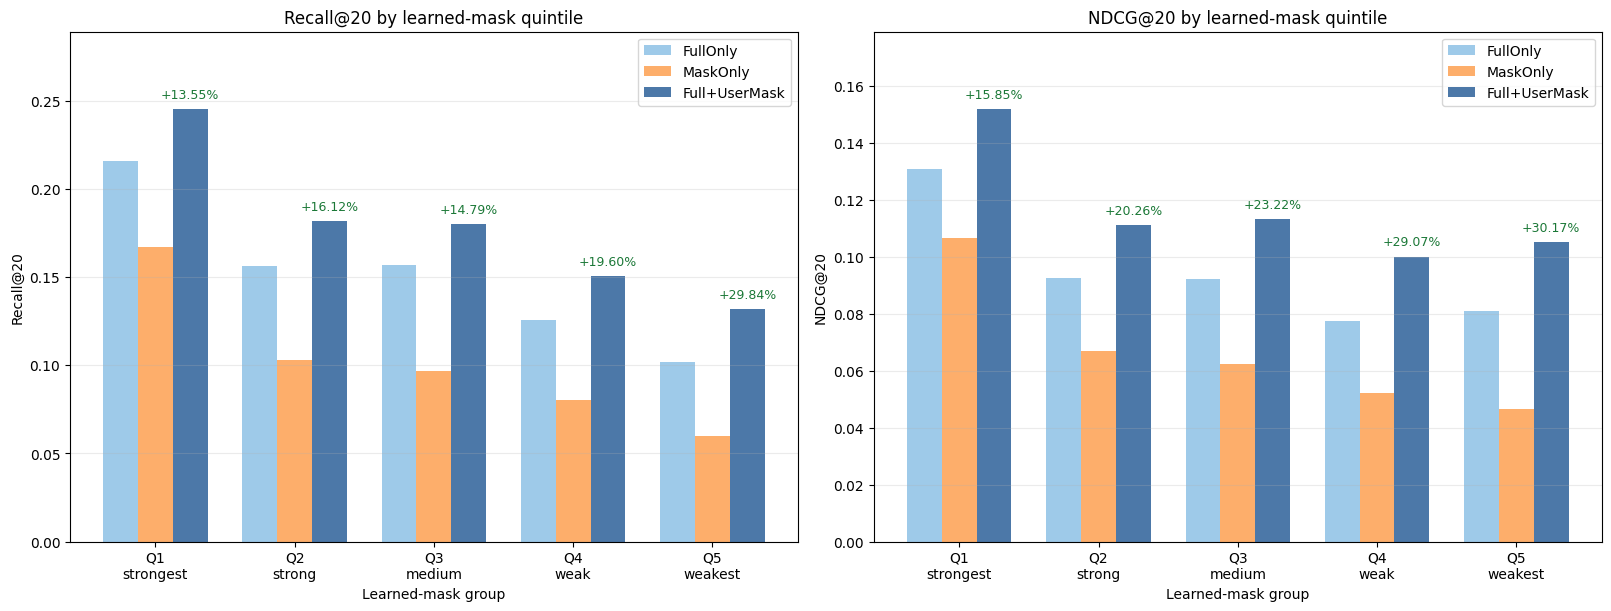

**Mask-quantile conclusion:** Full+UserMask does improve Q1, and its paired Recall@20 confidence interval is above zero. However, the largest relative Recall gain occurs in Q5 (weakest compression, +29.84%), while the largest relative NDCG gain occurs in Q5 (+30.17%). Thus the masked branch helps, but the strongest-compression users are not the users benefiting most from it.

In [21]:
display(Markdown("## 8. Mask quantile × performance (requested Analysis 9)"))

GROUP_METRIC_K = 20
N_MASK_QUANTILES = 5

required_objects = (
    "permutation_model", "permutation_test_data", "learned_user_mask_logits",
    "permutation_device",
)
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError(
        f"Missing {missing_objects}. Run the user-mask permutation-test cell first; "
        "its setup loads and freezes the checkpoint model used here."
    )

# Explicitly restore the learned assignment before comparing the two model branches.
with torch.no_grad():
    permutation_model.user_mask_logits.copy_(learned_user_mask_logits)
    dummy_index = torch.zeros(1, dtype=torch.long, device=permutation_device)
    permutation_model([dummy_index, dummy_index, dummy_index])

model_mask_values = torch.sigmoid(
    learned_user_mask_logits.to(dtype=torch.float64)
).detach().cpu().numpy()
if not np.allclose(model_mask_values, mask_values, rtol=0.0, atol=1e-10):
    raise RuntimeError("The evaluation model masks do not match the masks analyzed above.")

# Rank-based quintiles guarantee equal-sized groups even if quantile boundaries contain ties.
# Low m_u = high attenuation = strongest compression.
mask_rank_order = np.argsort(model_mask_values, kind="stable")
quantile_user_ids = np.array_split(mask_rank_order, N_MASK_QUANTILES)
user_quantile = np.empty(model_mask_values.size, dtype=np.int64)
for quantile_index, user_ids in enumerate(quantile_user_ids):
    user_quantile[user_ids] = quantile_index

quantile_labels = ["Q1", "Q2", "Q3", "Q4", "Q5"]
compression_labels = [
    "strongest compression", "strong compression", "medium compression",
    "weak compression", "weakest compression",
]

evaluation_user_ids = permutation_test_data.get_eval_users().detach().cpu().numpy().astype(np.int64)
evaluation_positive_sets = [
    set(map(int, positive_items))
    for positive_items in permutation_test_data.get_eval_items()
]
evaluation_positive_lengths = np.asarray(permutation_test_data.get_eval_len_list(), dtype=np.int64)
if not (
    evaluation_user_ids.size
    == len(evaluation_positive_sets)
    == evaluation_positive_lengths.size
):
    raise RuntimeError("Test user IDs and positive-item lists are not aligned.")
evaluation_quantiles = user_quantile[evaluation_user_ids]

# FullOnly and MaskOnly use the first and second halves of result_embed, respectively.
# item_item() is sparse linear propagation applied independently to each dimension,
# so these slices are clean inference-time branch ablations of the frozen model.
full_branch_dimension = permutation_model.id_embedding_full.embedding_dim
if permutation_model.result_embed.shape[1] != 2 * full_branch_dimension:
    raise ValueError(
        f"Expected concatenated Full+Mask dimension {2 * full_branch_dimension}, got "
        f"{permutation_model.result_embed.shape[1]}."
    )
display(
    Markdown(
        "**Ablation definition:** `FullOnly` and `MaskOnly` are inference-time branch ablations of the "
        "frozen trained model. Scores use only the full-branch or masked-branch half of the embedding, "
        "respectively; neither ablation is separately retrained."
    )
)
display(
    Markdown(
        "**How to read the comparison:** `MaskOnly` reports standalone masked-branch performance. "
        "The reported gain, paired difference, confidence interval, and plot annotation remain "
        "`Full+UserMask - FullOnly`, matching the original analysis hypothesis."
    )
)
full_only_user_embedding = permutation_model.result_embed[
    :permutation_model.n_users, :full_branch_dimension
]
full_only_item_embedding = permutation_model.result_embed[
    permutation_model.n_users:, :full_branch_dimension
]
mask_only_user_embedding = permutation_model.result_embed[
    :permutation_model.n_users, full_branch_dimension:
]
mask_only_item_embedding = permutation_model.result_embed[
    permutation_model.n_users:, full_branch_dimension:
]

@torch.no_grad()
def collect_branch_ablation_topk():
    permutation_model.eval()
    permutation_test_data.pr = 0
    permutation_test_data.inter_pr = 0
    full_only_batches = []
    mask_only_batches = []
    full_mask_batches = []
    try:
        for batched_data in permutation_test_data:
            batch_users = batched_data[0]
            training_items = batched_data[1]

            full_mask_scores = permutation_model.full_sort_predict(batched_data)
            full_only_scores = torch.matmul(
                full_only_user_embedding[batch_users], full_only_item_embedding.t()
            )
            mask_only_scores = torch.matmul(
                mask_only_user_embedding[batch_users], mask_only_item_embedding.t()
            )
            full_mask_scores[training_items[0], training_items[1]] = -1e10
            full_only_scores[training_items[0], training_items[1]] = -1e10
            mask_only_scores[training_items[0], training_items[1]] = -1e10

            full_mask_batches.append(
                torch.topk(full_mask_scores, GROUP_METRIC_K, dim=-1).indices.cpu()
            )
            full_only_batches.append(
                torch.topk(full_only_scores, GROUP_METRIC_K, dim=-1).indices.cpu()
            )
            mask_only_batches.append(
                torch.topk(mask_only_scores, GROUP_METRIC_K, dim=-1).indices.cpu()
            )
    finally:
        permutation_test_data.pr = 0
        permutation_test_data.inter_pr = 0

    return (
        torch.cat(full_only_batches, dim=0).numpy(),
        torch.cat(mask_only_batches, dim=0).numpy(),
        torch.cat(full_mask_batches, dim=0).numpy(),
    )

full_only_topk, mask_only_topk, full_mask_topk = collect_branch_ablation_topk()
if not all(
    rankings.shape[0] == evaluation_user_ids.size
    for rankings in (full_only_topk, mask_only_topk, full_mask_topk)
):
    raise RuntimeError("Branch-ablation rankings are not aligned with evaluation users.")

def per_user_recall_and_ndcg(topk_items, k):
    hits = np.asarray(
        [
            [int(item_id) in evaluation_positive_sets[row] for item_id in recommendations[:k]]
            for row, recommendations in enumerate(topk_items)
        ],
        dtype=np.float64,
    )
    recall = hits.sum(axis=1) / evaluation_positive_lengths

    discounts = 1.0 / np.log2(np.arange(2, k + 2))
    dcg = (hits * discounts).sum(axis=1)
    ideal_hit_counts = np.minimum(evaluation_positive_lengths, k)
    cumulative_discounts = np.cumsum(discounts)
    idcg = cumulative_discounts[ideal_hit_counts - 1]
    ndcg = dcg / idcg
    return recall, ndcg

full_only_recall, full_only_ndcg = per_user_recall_and_ndcg(full_only_topk, GROUP_METRIC_K)
mask_only_recall, mask_only_ndcg = per_user_recall_and_ndcg(mask_only_topk, GROUP_METRIC_K)
full_mask_recall, full_mask_ndcg = per_user_recall_and_ndcg(full_mask_topk, GROUP_METRIC_K)

def paired_mean_ci95(differences):
    mean_difference = differences.mean()
    if differences.size < 2:
        return mean_difference, np.nan, np.nan
    standard_error = differences.std(ddof=1) / np.sqrt(differences.size)
    return (
        mean_difference,
        mean_difference - 1.96 * standard_error,
        mean_difference + 1.96 * standard_error,
    )

quantile_definition_rows = []
group_performance_rows = []
group_performance = []
for quantile_index, (quantile_label, compression_label) in enumerate(
    zip(quantile_labels, compression_labels)
):
    all_group_users = quantile_user_ids[quantile_index]
    group_eval_mask = evaluation_quantiles == quantile_index
    group_mask_values = model_mask_values[all_group_users]
    group_attenuation = 1.0 - group_mask_values

    recall_full = full_only_recall[group_eval_mask].mean()
    recall_mask_only = mask_only_recall[group_eval_mask].mean()
    recall_full_mask = full_mask_recall[group_eval_mask].mean()
    ndcg_full = full_only_ndcg[group_eval_mask].mean()
    ndcg_mask_only = mask_only_ndcg[group_eval_mask].mean()
    ndcg_full_mask = full_mask_ndcg[group_eval_mask].mean()
    recall_relative_gain = (recall_full_mask - recall_full) / recall_full * 100.0
    ndcg_relative_gain = (ndcg_full_mask - ndcg_full) / ndcg_full * 100.0
    recall_difference, recall_ci_low, recall_ci_high = paired_mean_ci95(
        full_mask_recall[group_eval_mask] - full_only_recall[group_eval_mask]
    )
    ndcg_difference, ndcg_ci_low, ndcg_ci_high = paired_mean_ci95(
        full_mask_ndcg[group_eval_mask] - full_only_ndcg[group_eval_mask]
    )

    quantile_definition_rows.append(
        [
            quantile_label, compression_label, f"{all_group_users.size:,}",
            f"[{group_mask_values.min():.8f}, {group_mask_values.max():.8f}]",
            f"{group_mask_values.mean():.8f}", f"{group_attenuation.mean():.8f}",
        ]
    )
    group_performance_rows.append(
        [
            quantile_label, compression_label, f"{group_eval_mask.sum():,}",
            f"{recall_full:.8f}", f"{recall_mask_only:.8f}", f"{recall_full_mask:.8f}",
            f"{recall_relative_gain:+.3f}%",
            f"{recall_difference:+.8f} [{recall_ci_low:+.8f}, {recall_ci_high:+.8f}]",
            f"{ndcg_full:.8f}", f"{ndcg_mask_only:.8f}", f"{ndcg_full_mask:.8f}",
            f"{ndcg_relative_gain:+.3f}%",
            f"{ndcg_difference:+.8f} [{ndcg_ci_low:+.8f}, {ndcg_ci_high:+.8f}]",
        ]
    )
    group_performance.append(
        {
            "quantile": quantile_label, "compression": compression_label,
            "recall_full": recall_full, "recall_mask_only": recall_mask_only,
            "recall_full_mask": recall_full_mask,
            "recall_gain_percent": recall_relative_gain, "recall_diff": recall_difference,
            "recall_ci_low": recall_ci_low, "recall_ci_high": recall_ci_high,
            "ndcg_full": ndcg_full, "ndcg_mask_only": ndcg_mask_only,
            "ndcg_full_mask": ndcg_full_mask,
            "ndcg_gain_percent": ndcg_relative_gain, "ndcg_diff": ndcg_difference,
            "ndcg_ci_low": ndcg_ci_low, "ndcg_ci_high": ndcg_ci_high,
        }
    )

show_markdown_table(
    ["group", "compression", "all users", r"$m_u$ range", r"mean $m_u$", r"mean $1-m_u$"],
    quantile_definition_rows,
)
show_markdown_table(
    [
        "group", "compression", "test users", f"FullOnly R@{GROUP_METRIC_K}",
        f"MaskOnly R@{GROUP_METRIC_K}", f"Full+Mask R@{GROUP_METRIC_K}",
        "R gain", "paired ΔR [95% CI]", f"FullOnly N@{GROUP_METRIC_K}",
        f"MaskOnly N@{GROUP_METRIC_K}", f"Full+Mask N@{GROUP_METRIC_K}",
        "N gain", "paired ΔN [95% CI]",
    ],
    group_performance_rows,
)

x_positions = np.arange(N_MASK_QUANTILES)
bar_width = 0.25
figure, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

def plot_group_metric(ax, metric_prefix, metric_title):
    full_values = np.array([row[f"{metric_prefix}_full"] for row in group_performance])
    mask_only_values = np.array([row[f"{metric_prefix}_mask_only"] for row in group_performance])
    full_mask_values = np.array([row[f"{metric_prefix}_full_mask"] for row in group_performance])
    gains = np.array([row[f"{metric_prefix}_gain_percent"] for row in group_performance])
    ax.bar(x_positions - bar_width, full_values, bar_width, label="FullOnly", color="#9ecae9")
    ax.bar(x_positions, mask_only_values, bar_width, label="MaskOnly", color="#fdae6b")
    mask_bars = ax.bar(
        x_positions + bar_width, full_mask_values, bar_width,
        label="Full+UserMask", color="#4c78a8",
    )
    plot_maximum = max(full_values.max(), mask_only_values.max(), full_mask_values.max())
    annotation_offset = plot_maximum * 0.018
    for bar, gain in zip(mask_bars, gains):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + annotation_offset,
            f"{gain:+.2f}%", ha="center", va="bottom", fontsize=9,
            color="#b22222" if gain < 0 else "#1b7837",
        )
    ax.set(
        title=f"{metric_title} by learned-mask quintile", xlabel="Learned-mask group",
        ylabel=metric_title, xticks=x_positions,
        xticklabels=[f"{q}\n{label.split()[0]}" for q, label in zip(quantile_labels, compression_labels)],
    )
    ax.set_ylim(0, plot_maximum * 1.18)
    ax.grid(axis="y", alpha=0.25)
    ax.legend()

plot_group_metric(axes[0], "recall", f"Recall@{GROUP_METRIC_K}")
plot_group_metric(axes[1], "ndcg", f"NDCG@{GROUP_METRIC_K}")
plt.show()

q1 = group_performance[0]
q5 = group_performance[-1]
best_recall_gain_group = max(group_performance, key=lambda row: row['recall_gain_percent'])
best_ndcg_gain_group = max(group_performance, key=lambda row: row['ndcg_gain_percent'])
if (
    q1["recall_diff"] > 0
    and q1["recall_ci_low"] > 0
    and q1["recall_gain_percent"] > q5["recall_gain_percent"]
):
    quantile_performance_conclusion = (
        f"Q1 has a positive Recall@{GROUP_METRIC_K} gain with a paired 95% CI above zero, and its gain "
        f"exceeds Q5. This supports the hypothesis that the users assigned stronger compression are the "
        f"users benefiting most from the masked branch."
    )
elif (
    q1["recall_diff"] > 0
    and q1["recall_ci_low"] > 0
    and best_recall_gain_group["quantile"] != "Q1"
):
    quantile_performance_conclusion = (
        f"Full+UserMask does improve Q1, and its paired Recall@{GROUP_METRIC_K} confidence interval is above zero. "
        f"However, the largest relative Recall gain occurs in {best_recall_gain_group['quantile']} "
        f"({best_recall_gain_group['compression']}, {best_recall_gain_group['recall_gain_percent']:+.2f}%), "
        f"while the largest relative NDCG gain occurs in {best_ndcg_gain_group['quantile']} "
        f"({best_ndcg_gain_group['ndcg_gain_percent']:+.2f}%). Thus the masked branch helps, but the "
        f"strongest-compression users are not the users benefiting most from it."
    )
else:
    quantile_performance_conclusion = (
        f"The strongest-compression group Q1 does not gain more Recall@{GROUP_METRIC_K} than Q5. "
        f"This analysis therefore does not support the claim that strongly compressed users are exactly "
        f"those benefiting most from the masked branch."
    )
display(Markdown(f"**Mask-quantile conclusion:** {quantile_performance_conclusion}"))

## 9. Degree-matched mask-quantile performance

| matching diagnostic | value |
| --- | --- |
| eligible exact-degree strata | 33 |
| eligible degree range | 1–36 |
| matched users per conditional quantile | 1,856 |
| total matched test users | 9,280 / 9,860 |
| test-user coverage | 94.12% |
| identical mean degree in every group | 8.8626 |
| identical median degree in every group | 7.0000 |

| conditional group | compression | users | mean $m_u$ | mean $1-m_u$ | mean degree | FullOnly R@20 | MaskOnly R@20 | Full+Mask R@20 | R gain | paired ΔR [95% CI] | FullOnly N@20 | MaskOnly N@20 | Full+Mask N@20 | N gain | paired ΔN [95% CI] |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| CQ1 | strongest within degree | 1,856 | 0.98082421 | 0.01917579 | 8.8626 | 0.23784806 | 0.18011241 | 0.27390423 | +15.159% | +0.03605617 [+0.02644612, +0.04566621] | 0.14785612 | 0.11495845 | 0.17156660 | +16.036% | +0.02371048 [+0.01849806, +0.02892290] |
| CQ2 | strong within degree | 1,856 | 0.99249224 | 0.00750776 | 8.8626 | 0.15293186 | 0.10242461 | 0.17978491 | +17.559% | +0.02685305 [+0.01808764, +0.03561847] | 0.09372817 | 0.06745866 | 0.11450694 | +22.169% | +0.02077877 [+0.01576732, +0.02579023] |
| CQ3 | medium within degree | 1,856 | 0.99386066 | 0.00613934 | 8.8626 | 0.13950181 | 0.08626115 | 0.16246711 | +16.462% | +0.02296530 [+0.01339395, +0.03253665] | 0.08347933 | 0.05662851 | 0.10286778 | +23.225% | +0.01938845 [+0.01417707, +0.02459983] |
| CQ4 | weak within degree | 1,856 | 0.99478327 | 0.00521673 | 8.8626 | 0.12512367 | 0.07471516 | 0.14639125 | +16.997% | +0.02126758 [+0.01225215, +0.03028302] | 0.07362368 | 0.04950092 | 0.09279219 | +26.036% | +0.01916851 [+0.01396735, +0.02436968] |
| CQ5 | weakest within degree | 1,856 | 0.99582516 | 0.00417484 | 8.8626 | 0.11150428 | 0.07395590 | 0.13684558 | +22.727% | +0.02534131 [+0.01746842, +0.03321419] | 0.06843156 | 0.04712235 | 0.09077814 | +32.655% | +0.02234658 [+0.01767473, +0.02701844] |

| metric | CQ1 absolute gain | CQ5 absolute gain | CQ1 - CQ5 contrast | contrast 95% CI | z | one-sided p (CQ1 > CQ5) |
| --- | --- | --- | --- | --- | --- | --- |
| Recall@20 | +0.03605617 | +0.02534131 | +0.01071486 | [-0.00170831, +0.02313803] | +1.690 | 0.045468 |
| NDCG@20 | +0.02371048 | +0.02234658 | +0.00136390 | [-0.00563579, +0.00836358] | +0.382 | 0.351265 |

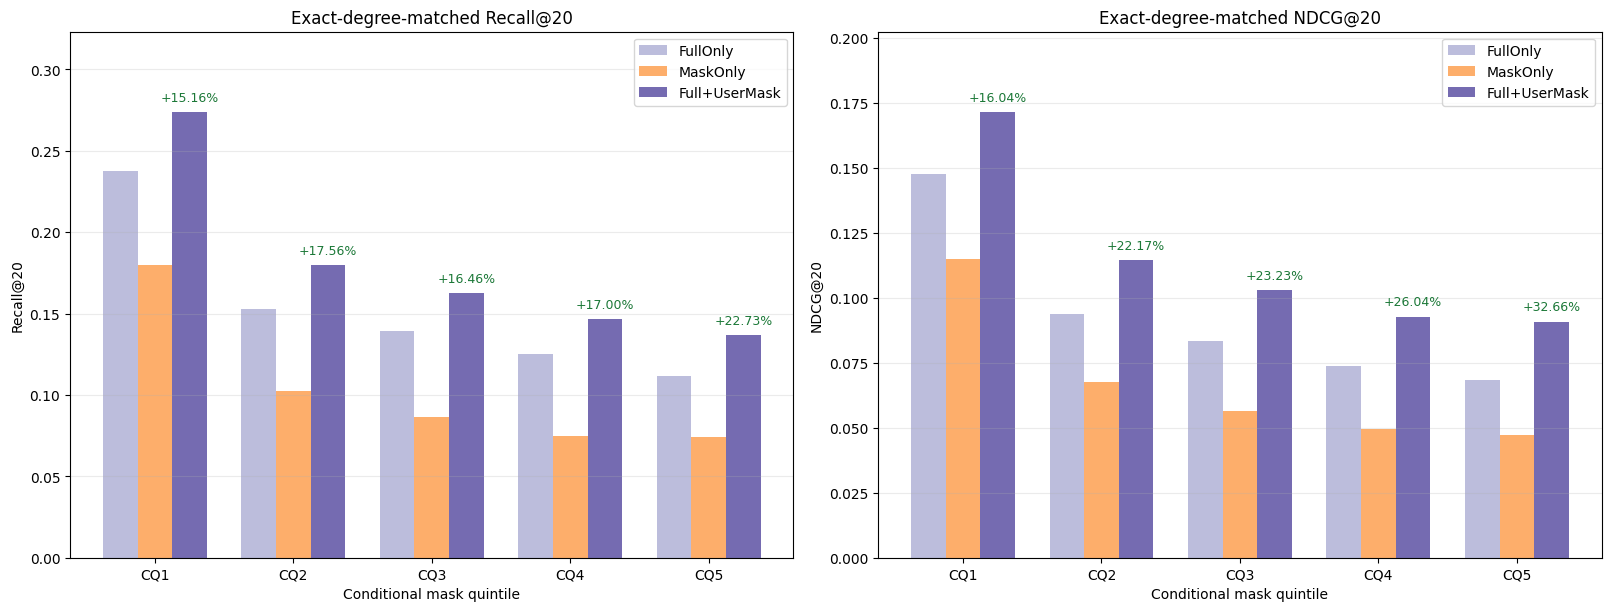

**Degree-matched conclusion:** After exact-degree matching, CQ1 has a larger absolute Recall@20 gain than CQ5 with marginal directional evidence under the prespecified one-sided hypothesis (p=0.0455), but the two-sided 95% CI still includes zero. NDCG does not corroborate this contrast (one-sided p=0.3513), so this is suggestive rather than robust multi-metric evidence of mask-specific targeting beyond activity.

In [22]:
display(Markdown("## 9. Degree-matched mask-quantile performance"))

from scipy.stats import norm

N_CONDITIONAL_QUANTILES = 5
MIN_TEST_USERS_PER_EXACT_DEGREE = 25

degree_matched_required = (
    "evaluation_user_ids", "user_degree", "model_mask_values",
    "full_only_recall", "mask_only_recall", "full_mask_recall",
    "full_only_ndcg", "mask_only_ndcg", "full_mask_ndcg",
)
degree_matched_missing = [name for name in degree_matched_required if name not in globals()]
if degree_matched_missing:
    raise RuntimeError(
        f"Missing {degree_matched_missing}. Run the mask-quantile × performance cell first."
    )

evaluation_degrees = user_degree[evaluation_user_ids]
eligible_exact_degrees = np.array(
    [
        degree
        for degree in np.unique(evaluation_degrees)
        if np.count_nonzero(evaluation_degrees == degree) >= MIN_TEST_USERS_PER_EXACT_DEGREE
    ],
    dtype=np.int64,
)
if eligible_exact_degrees.size == 0:
    raise ValueError("No exact-degree stratum has enough test users for five conditional quantiles.")

# Within every exact degree, rank users by m_u and split into five conditional quantiles.
# Keep the same number from every stratum in each quantile, so the pooled degree
# distribution is exactly identical across CQ1,...,CQ5.
conditional_rows_by_quantile = [[] for _ in range(N_CONDITIONAL_QUANTILES)]
matched_users_per_degree_per_quantile = {}
for degree in eligible_exact_degrees:
    stratum_rows = np.flatnonzero(evaluation_degrees == degree)
    sorted_rows = stratum_rows[
        np.argsort(model_mask_values[evaluation_user_ids[stratum_rows]], kind="stable")
    ]
    provisional_quantiles = np.array_split(sorted_rows, N_CONDITIONAL_QUANTILES)
    users_per_quantile = min(chunk.size for chunk in provisional_quantiles)
    matched_users_per_degree_per_quantile[int(degree)] = int(users_per_quantile)

    for quantile_index, chunk in enumerate(provisional_quantiles):
        # When n is not divisible by five, retain evenly spaced ranks from the larger chunks.
        if chunk.size == users_per_quantile:
            selected_rows = chunk
        else:
            selected_positions = np.rint(
                np.linspace(0, chunk.size - 1, num=users_per_quantile)
            ).astype(np.int64)
            selected_rows = chunk[selected_positions]
        conditional_rows_by_quantile[quantile_index].append(selected_rows)

conditional_rows_by_quantile = [
    np.concatenate(row_chunks).astype(np.int64)
    for row_chunks in conditional_rows_by_quantile
]
conditional_group_size = conditional_rows_by_quantile[0].size
if not all(rows.size == conditional_group_size for rows in conditional_rows_by_quantile):
    raise RuntimeError("Conditional quantile groups do not have equal sample sizes.")

# Exact verification that every conditional quantile has the same degree histogram.
reference_degree_histogram = np.bincount(
    evaluation_degrees[conditional_rows_by_quantile[0]],
    minlength=int(evaluation_degrees.max()) + 1,
)
for quantile_index, rows in enumerate(conditional_rows_by_quantile[1:], start=2):
    current_histogram = np.bincount(
        evaluation_degrees[rows], minlength=reference_degree_histogram.size
    )
    if not np.array_equal(reference_degree_histogram, current_histogram):
        raise RuntimeError(f"CQ{quantile_index} does not match CQ1's exact-degree distribution.")

all_matched_rows = np.concatenate(conditional_rows_by_quantile)
if np.unique(all_matched_rows).size != all_matched_rows.size:
    raise RuntimeError("A test user was assigned to more than one conditional quantile.")
matched_coverage = all_matched_rows.size / evaluation_user_ids.size
matched_degree_mean = evaluation_degrees[conditional_rows_by_quantile[0]].mean()
matched_degree_median = np.median(evaluation_degrees[conditional_rows_by_quantile[0]])

matching_diagnostics_rows = [
    ["eligible exact-degree strata", f"{eligible_exact_degrees.size:,}"],
    ["eligible degree range", f"{eligible_exact_degrees.min()}–{eligible_exact_degrees.max()}"],
    ["matched users per conditional quantile", f"{conditional_group_size:,}"],
    ["total matched test users", f"{all_matched_rows.size:,} / {evaluation_user_ids.size:,}"],
    ["test-user coverage", f"{matched_coverage:.2%}"],
    ["identical mean degree in every group", f"{matched_degree_mean:.4f}"],
    ["identical median degree in every group", f"{matched_degree_median:.4f}"],
]
show_markdown_table(["matching diagnostic", "value"], matching_diagnostics_rows)

conditional_quantile_labels = ["CQ1", "CQ2", "CQ3", "CQ4", "CQ5"]
conditional_compression_labels = [
    "strongest within degree", "strong within degree", "medium within degree",
    "weak within degree", "weakest within degree",
]
degree_matched_performance = []
degree_matched_rows = []
for quantile_label, compression_label, rows in zip(
    conditional_quantile_labels, conditional_compression_labels, conditional_rows_by_quantile
):
    selected_user_ids = evaluation_user_ids[rows]
    selected_masks = model_mask_values[selected_user_ids]
    selected_degrees = evaluation_degrees[rows]

    recall_full = full_only_recall[rows].mean()
    recall_mask_only = mask_only_recall[rows].mean()
    recall_full_mask = full_mask_recall[rows].mean()
    ndcg_full = full_only_ndcg[rows].mean()
    ndcg_mask_only = mask_only_ndcg[rows].mean()
    ndcg_full_mask = full_mask_ndcg[rows].mean()
    recall_user_differences = full_mask_recall[rows] - full_only_recall[rows]
    ndcg_user_differences = full_mask_ndcg[rows] - full_only_ndcg[rows]
    recall_difference, recall_ci_low, recall_ci_high = paired_mean_ci95(recall_user_differences)
    ndcg_difference, ndcg_ci_low, ndcg_ci_high = paired_mean_ci95(ndcg_user_differences)
    recall_gain_percent = recall_difference / recall_full * 100.0
    ndcg_gain_percent = ndcg_difference / ndcg_full * 100.0

    degree_matched_performance.append(
        {
            "quantile": quantile_label, "compression": compression_label, "rows": rows,
            "mean_mask": selected_masks.mean(), "mean_attenuation": (1.0 - selected_masks).mean(),
            "mean_degree": selected_degrees.mean(),
            "recall_full": recall_full, "recall_mask_only": recall_mask_only,
            "recall_full_mask": recall_full_mask,
            "recall_diff": recall_difference, "recall_ci_low": recall_ci_low,
            "recall_ci_high": recall_ci_high, "recall_gain_percent": recall_gain_percent,
            "recall_user_differences": recall_user_differences,
            "ndcg_full": ndcg_full, "ndcg_mask_only": ndcg_mask_only,
            "ndcg_full_mask": ndcg_full_mask,
            "ndcg_diff": ndcg_difference, "ndcg_ci_low": ndcg_ci_low,
            "ndcg_ci_high": ndcg_ci_high, "ndcg_gain_percent": ndcg_gain_percent,
            "ndcg_user_differences": ndcg_user_differences,
        }
    )
    degree_matched_rows.append(
        [
            quantile_label, compression_label, f"{rows.size:,}", f"{selected_masks.mean():.8f}",
            f"{(1.0 - selected_masks).mean():.8f}", f"{selected_degrees.mean():.4f}",
            f"{recall_full:.8f}", f"{recall_mask_only:.8f}", f"{recall_full_mask:.8f}",
            f"{recall_gain_percent:+.3f}%",
            f"{recall_difference:+.8f} [{recall_ci_low:+.8f}, {recall_ci_high:+.8f}]",
            f"{ndcg_full:.8f}", f"{ndcg_mask_only:.8f}", f"{ndcg_full_mask:.8f}",
            f"{ndcg_gain_percent:+.3f}%",
            f"{ndcg_difference:+.8f} [{ndcg_ci_low:+.8f}, {ndcg_ci_high:+.8f}]",
        ]
    )

show_markdown_table(
    [
        "conditional group", "compression", "users", r"mean $m_u$", r"mean $1-m_u$",
        "mean degree", f"FullOnly R@{GROUP_METRIC_K}", f"MaskOnly R@{GROUP_METRIC_K}",
        f"Full+Mask R@{GROUP_METRIC_K}", "R gain", "paired ΔR [95% CI]",
        f"FullOnly N@{GROUP_METRIC_K}", f"MaskOnly N@{GROUP_METRIC_K}",
        f"Full+Mask N@{GROUP_METRIC_K}", "N gain", "paired ΔN [95% CI]",
    ],
    degree_matched_rows,
)

def independent_gain_contrast(group_a_differences, group_b_differences):
    contrast = group_a_differences.mean() - group_b_differences.mean()
    standard_error = np.sqrt(
        group_a_differences.var(ddof=1) / group_a_differences.size
        + group_b_differences.var(ddof=1) / group_b_differences.size
    )
    if standard_error > 0:
        z_score = contrast / standard_error
        p_one_sided = norm.sf(z_score)  # H1: CQ1 gain > CQ5 gain
        ci_low = contrast - 1.96 * standard_error
        ci_high = contrast + 1.96 * standard_error
    else:
        z_score = p_one_sided = ci_low = ci_high = np.nan
    return contrast, ci_low, ci_high, z_score, p_one_sided

cq1_matched = degree_matched_performance[0]
cq5_matched = degree_matched_performance[-1]
recall_contrast = independent_gain_contrast(
    cq1_matched["recall_user_differences"], cq5_matched["recall_user_differences"]
)
ndcg_contrast = independent_gain_contrast(
    cq1_matched["ndcg_user_differences"], cq5_matched["ndcg_user_differences"]
)
contrast_rows = [
    [
        f"Recall@{GROUP_METRIC_K}", f"{cq1_matched['recall_diff']:+.8f}",
        f"{cq5_matched['recall_diff']:+.8f}", f"{recall_contrast[0]:+.8f}",
        f"[{recall_contrast[1]:+.8f}, {recall_contrast[2]:+.8f}]",
        f"{recall_contrast[3]:+.3f}", f"{recall_contrast[4]:.6f}",
    ],
    [
        f"NDCG@{GROUP_METRIC_K}", f"{cq1_matched['ndcg_diff']:+.8f}",
        f"{cq5_matched['ndcg_diff']:+.8f}", f"{ndcg_contrast[0]:+.8f}",
        f"[{ndcg_contrast[1]:+.8f}, {ndcg_contrast[2]:+.8f}]",
        f"{ndcg_contrast[3]:+.3f}", f"{ndcg_contrast[4]:.6f}",
    ],
]
show_markdown_table(
    [
        "metric", "CQ1 absolute gain", "CQ5 absolute gain", "CQ1 - CQ5 contrast",
        "contrast 95% CI", "z", "one-sided p (CQ1 > CQ5)",
    ],
    contrast_rows,
)

matched_x = np.arange(N_CONDITIONAL_QUANTILES)
matched_bar_width = 0.25
figure, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

def plot_degree_matched_metric(ax, metric_prefix, metric_title):
    full_values = np.array([row[f"{metric_prefix}_full"] for row in degree_matched_performance])
    mask_only_values = np.array([row[f"{metric_prefix}_mask_only"] for row in degree_matched_performance])
    full_mask_values = np.array([row[f"{metric_prefix}_full_mask"] for row in degree_matched_performance])
    gains = np.array([row[f"{metric_prefix}_gain_percent"] for row in degree_matched_performance])
    ax.bar(matched_x - matched_bar_width, full_values, matched_bar_width, label="FullOnly", color="#bcbddc")
    ax.bar(matched_x, mask_only_values, matched_bar_width, label="MaskOnly", color="#fdae6b")
    mask_bars = ax.bar(
        matched_x + matched_bar_width, full_mask_values, matched_bar_width,
        label="Full+UserMask", color="#756bb1",
    )
    plot_maximum = max(full_values.max(), mask_only_values.max(), full_mask_values.max())
    annotation_offset = plot_maximum * 0.018
    for bar, gain in zip(mask_bars, gains):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + annotation_offset,
            f"{gain:+.2f}%", ha="center", va="bottom", fontsize=9,
            color="#b22222" if gain < 0 else "#1b7837",
        )
    ax.set(
        title=f"Exact-degree-matched {metric_title}", xlabel="Conditional mask quintile",
        ylabel=metric_title, xticks=matched_x, xticklabels=conditional_quantile_labels,
    )
    ax.set_ylim(0, plot_maximum * 1.18)
    ax.grid(axis="y", alpha=0.25)
    ax.legend()

plot_degree_matched_metric(axes[0], "recall", f"Recall@{GROUP_METRIC_K}")
plot_degree_matched_metric(axes[1], "ndcg", f"NDCG@{GROUP_METRIC_K}")
plt.show()

if recall_contrast[1] > 0 and recall_contrast[4] < 0.05:
    degree_matched_conclusion = (
        f"After exact-degree matching, CQ1 has a larger absolute Recall@{GROUP_METRIC_K} gain than CQ5 "
        f"(one-sided p={recall_contrast[4]:.4f}). This supports mask-specific targeting beyond activity."
    )
elif recall_contrast[0] > 0 and recall_contrast[4] < 0.05:
    degree_matched_conclusion = (
        f"After exact-degree matching, CQ1 has a larger absolute Recall@{GROUP_METRIC_K} gain than CQ5 "
        f"with marginal directional evidence under the prespecified one-sided hypothesis "
        f"(p={recall_contrast[4]:.4f}), but the two-sided 95% CI still includes zero. "
        f"NDCG does not corroborate this contrast (one-sided p={ndcg_contrast[4]:.4f}), so this is "
        f"suggestive rather than robust multi-metric evidence of mask-specific targeting beyond activity."
    )
elif recall_contrast[2] < 0:
    degree_matched_conclusion = (
        f"After exact-degree matching, CQ1 has a reliably smaller absolute Recall@{GROUP_METRIC_K} gain than CQ5. "
        f"The evidence runs opposite to the hypothesis that stronger compression targets the users benefiting most."
    )
else:
    degree_matched_conclusion = (
        f"After exact-degree matching, the CQ1-minus-CQ5 Recall@{GROUP_METRIC_K} gain contrast includes zero "
        f"(one-sided p={recall_contrast[4]:.4f}). Degree is controlled, but there is no reliable evidence that "
        f"stronger compression identifies users benefiting more from the masked branch."
    )
display(Markdown(f"**Degree-matched conclusion:** {degree_matched_conclusion}"))

## 10. User degree conditional on learned mask

$\rho_{\mathrm{Spearman}}(m_u,d_u)=0.685311$ (two-sided $p=0.000e+00$). Unlike Spearman correlation, $E[d_u\mid m_u]$ is not obtained by simply inverting $E[1-m_u\mid d_u]$, so we estimate it directly with mask bins.

| mask group | compression | users | $m_u$ range | mean $m_u$ | mean $1-m_u$ | $E[d_u\mid m_u\ group]$ | mean-degree 95% CI | median degree | degree IQR |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Q1 | strongest compression | 2,200 | [0.75212465, 0.99143961] | 0.97794233 | 0.02205767 | 5.0127 | [4.8704, 5.1550] | 4.00 | [3.00, 6.00] |
| Q2 | strong compression | 2,200 | [0.99143988, 0.99362730] | 0.99267806 | 0.00732194 | 6.2236 | [6.0804, 6.3668] | 5.00 | [4.00, 7.00] |
| Q3 | medium compression | 2,200 | [0.99362859, 0.99486950] | 0.99427160 | 0.00572840 | 7.6750 | [7.4962, 7.8538] | 7.00 | [5.00, 9.00] |
| Q4 | weak compression | 2,200 | [0.99486953, 0.99603615] | 0.99543313 | 0.00456687 | 9.9173 | [9.6755, 10.1590] | 8.00 | [6.00, 12.00] |
| Q5 | weakest compression | 2,200 | [0.99603704, 0.99918599] | 0.99701422 | 0.00298578 | 25.9277 | [24.9604, 26.8950] | 19.00 | [12.00, 31.00] |

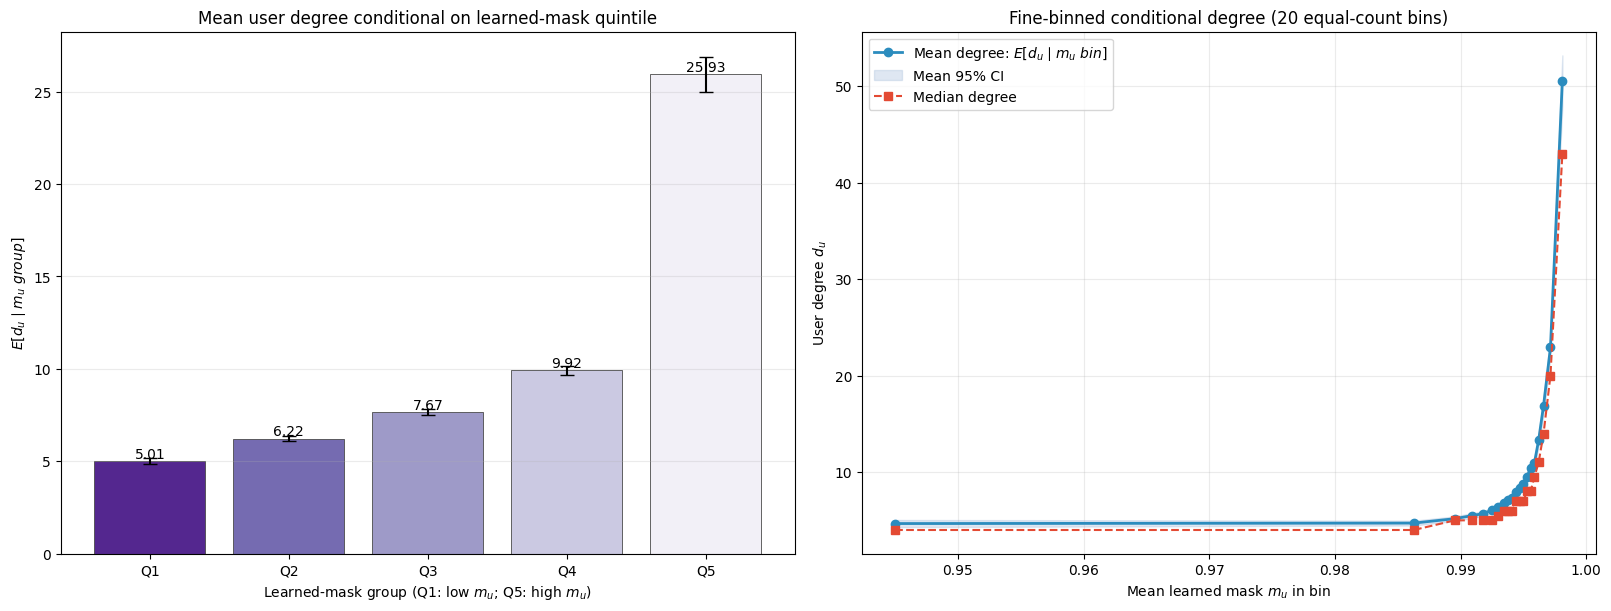

**Conditional-degree conclusion:** Q1 mean degree = 5.013, while Q5 mean degree = 25.928 (Q5/Q1 ratio = 5.172). Thus the `higher-mask / weaker-compression` users are more active on average. This is a descriptive conditional association, not a causal effect of the mask.

In [23]:
display(Markdown("## 10. User degree conditional on learned mask"))

from scipy.stats import spearmanr

N_DEGREE_GIVEN_MASK_QUANTILES = 5
N_FINE_MASK_BINS = 20

degree_given_mask_required = ("mask_values", "user_degree", "show_markdown_table")
degree_given_mask_missing = [
    name for name in degree_given_mask_required if name not in globals()
]
if degree_given_mask_missing:
    raise RuntimeError(
        f"Missing {degree_given_mask_missing}. Run the mask-distribution and Mask-vs-degree cells first."
    )

degree_given_mask_values = np.asarray(mask_values, dtype=np.float64)
degree_given_mask_degrees = np.asarray(user_degree, dtype=np.float64)
if degree_given_mask_values.shape != degree_given_mask_degrees.shape:
    raise ValueError(
        f"Mask and degree arrays must align, got {degree_given_mask_values.shape} and "
        f"{degree_given_mask_degrees.shape}."
    )
if not (np.isfinite(degree_given_mask_values).all() and np.isfinite(degree_given_mask_degrees).all()):
    raise ValueError("Mask or degree contains non-finite values.")

# Spearman is symmetric, while the conditional expectation is not. Because m_u = 1 - a_u,
# rho(m_u, degree) must have the opposite sign of rho(1 - m_u, degree).
rho_mask_degree, p_mask_degree = spearmanr(
    degree_given_mask_values, degree_given_mask_degrees
)
display(
    Markdown(
        rf"$\rho_{{\mathrm{{Spearman}}}}(m_u,d_u)={rho_mask_degree:.6f}$ "
        rf"(two-sided $p={p_mask_degree:.3e}$). "
        r"Unlike Spearman correlation, $E[d_u\mid m_u]$ is not obtained by simply "
        r"inverting $E[1-m_u\mid d_u]$, so we estimate it directly with mask bins."
    )
)

# Equal-count rank bins remain informative even though the learned masks occupy a narrow range.
degree_given_mask_order = np.argsort(degree_given_mask_values, kind="stable")
degree_given_mask_user_groups = np.array_split(
    degree_given_mask_order, N_DEGREE_GIVEN_MASK_QUANTILES
)
degree_given_mask_labels = ["Q1", "Q2", "Q3", "Q4", "Q5"]
degree_given_mask_compression = [
    "strongest compression", "strong compression", "medium compression",
    "weak compression", "weakest compression",
]

degree_given_mask_statistics = []
degree_given_mask_rows = []
for group_label, compression_label, user_ids in zip(
    degree_given_mask_labels, degree_given_mask_compression, degree_given_mask_user_groups
):
    group_masks = degree_given_mask_values[user_ids]
    group_degrees = degree_given_mask_degrees[user_ids]
    degree_q25, degree_median, degree_q75 = np.quantile(group_degrees, [0.25, 0.50, 0.75])
    degree_mean = group_degrees.mean()
    degree_se = group_degrees.std(ddof=1) / np.sqrt(group_degrees.size)
    degree_ci_low = degree_mean - 1.96 * degree_se
    degree_ci_high = degree_mean + 1.96 * degree_se

    degree_given_mask_statistics.append(
        {
            "group": group_label, "compression": compression_label,
            "mean_mask": group_masks.mean(),
            "mean_attenuation": (1.0 - group_masks).mean(),
            "mean_degree": degree_mean, "median_degree": degree_median,
            "degree_q25": degree_q25, "degree_q75": degree_q75,
            "degree_ci_low": degree_ci_low, "degree_ci_high": degree_ci_high,
        }
    )
    degree_given_mask_rows.append(
        [
            group_label, compression_label, f"{user_ids.size:,}",
            f"[{group_masks.min():.8f}, {group_masks.max():.8f}]",
            f"{group_masks.mean():.8f}", f"{(1.0 - group_masks).mean():.8f}",
            f"{degree_mean:.4f}", f"[{degree_ci_low:.4f}, {degree_ci_high:.4f}]",
            f"{degree_median:.2f}", f"[{degree_q25:.2f}, {degree_q75:.2f}]",
        ]
    )

show_markdown_table(
    [
        "mask group", "compression", "users", r"$m_u$ range", r"mean $m_u$",
        r"mean $1-m_u$", r"$E[d_u\mid m_u\ group]$", "mean-degree 95% CI",
        "median degree", "degree IQR",
    ],
    degree_given_mask_rows,
)

# A finer equal-count estimate of E[d_u | m_u] shows whether the quintile trend is smooth.
fine_mask_user_groups = np.array_split(degree_given_mask_order, N_FINE_MASK_BINS)
fine_mask_centers = []
fine_degree_means = []
fine_degree_medians = []
fine_degree_ci_lows = []
fine_degree_ci_highs = []
for user_ids in fine_mask_user_groups:
    bin_masks = degree_given_mask_values[user_ids]
    bin_degrees = degree_given_mask_degrees[user_ids]
    bin_mean = bin_degrees.mean()
    bin_se = bin_degrees.std(ddof=1) / np.sqrt(bin_degrees.size)
    fine_mask_centers.append(bin_masks.mean())
    fine_degree_means.append(bin_mean)
    fine_degree_medians.append(np.median(bin_degrees))
    fine_degree_ci_lows.append(bin_mean - 1.96 * bin_se)
    fine_degree_ci_highs.append(bin_mean + 1.96 * bin_se)

fine_mask_centers = np.asarray(fine_mask_centers)
fine_degree_means = np.asarray(fine_degree_means)
fine_degree_medians = np.asarray(fine_degree_medians)
fine_degree_ci_lows = np.asarray(fine_degree_ci_lows)
fine_degree_ci_highs = np.asarray(fine_degree_ci_highs)

conditional_x = np.arange(N_DEGREE_GIVEN_MASK_QUANTILES)
conditional_means = np.asarray([row["mean_degree"] for row in degree_given_mask_statistics])
conditional_ci_lows = np.asarray([row["degree_ci_low"] for row in degree_given_mask_statistics])
conditional_ci_highs = np.asarray([row["degree_ci_high"] for row in degree_given_mask_statistics])
conditional_error = np.vstack(
    [conditional_means - conditional_ci_lows, conditional_ci_highs - conditional_means]
)

figure, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
axes[0].bar(
    conditional_x, conditional_means, yerr=conditional_error, capsize=5,
    color=["#54278f", "#756bb1", "#9e9ac8", "#cbc9e2", "#f2f0f7"],
    edgecolor="#4a4a4a", linewidth=0.6,
)
for x_value, mean_value in zip(conditional_x, conditional_means):
    axes[0].text(x_value, mean_value, f"{mean_value:.2f}", ha="center", va="bottom")
axes[0].set(
    title=r"Mean user degree conditional on learned-mask quintile",
    xlabel=r"Learned-mask group (Q1: low $m_u$; Q5: high $m_u$)",
    ylabel=r"$E[d_u\mid m_u\ group]$",
    xticks=conditional_x, xticklabels=degree_given_mask_labels,
)
axes[0].grid(axis="y", alpha=0.25)

axes[1].plot(
    fine_mask_centers, fine_degree_means, marker="o", linewidth=2,
    label=r"Mean degree: $E[d_u\mid m_u\ bin]$", color="#2b8cbe",
)
axes[1].fill_between(
    fine_mask_centers, fine_degree_ci_lows, fine_degree_ci_highs,
    color="#a6bddb", alpha=0.35, label="Mean 95% CI",
)
axes[1].plot(
    fine_mask_centers, fine_degree_medians, marker="s", linestyle="--",
    label="Median degree", color="#e34a33",
)
axes[1].set(
    title=f"Fine-binned conditional degree ({N_FINE_MASK_BINS} equal-count bins)",
    xlabel=r"Mean learned mask $m_u$ in bin", ylabel=r"User degree $d_u$",
)
axes[1].grid(alpha=0.25)
axes[1].legend()
plt.show()

q1_degree_given_mask = degree_given_mask_statistics[0]
q5_degree_given_mask = degree_given_mask_statistics[-1]
degree_mean_ratio = q5_degree_given_mask["mean_degree"] / q1_degree_given_mask["mean_degree"]
if q5_degree_given_mask["mean_degree"] > q1_degree_given_mask["mean_degree"]:
    conditional_degree_direction = "higher-mask / weaker-compression"
else:
    conditional_degree_direction = "lower-mask / stronger-compression"
display(
    Markdown(
        f"**Conditional-degree conclusion:** Q1 mean degree = "
        f"{q1_degree_given_mask['mean_degree']:.3f}, while Q5 mean degree = "
        f"{q5_degree_given_mask['mean_degree']:.3f} (Q5/Q1 ratio = {degree_mean_ratio:.3f}). "
        f"Thus the `{conditional_degree_direction}` users are more active on average. "
        f"This is a descriptive conditional association, not a causal effect of the mask."
    )
)

## 11. Performance by user-degree group

| degree group | activity | test users | mean degree | median degree | mean $m_u$ | mean $1-m_u$ |
| --- | --- | --- | --- | --- | --- | --- |
| 1–5 | low activity | 3,126 | 3.877 | 4.0 | 0.98765803 | 0.01234197 |
| 6–20 | medium activity | 5,580 | 9.831 | 9.0 | 0.99327101 | 0.00672899 |
| 21–50 | high activity | 902 | 30.093 | 28.0 | 0.99622312 | 0.00377688 |
| 51+ | very high activity | 252 | 76.706 | 66.5 | 0.99809209 | 0.00190791 |

| degree group | FullOnly R@20 | MaskOnly R@20 | Full+Mask R@20 | paired absolute gain [95% CI] | relative gain [bootstrap 95% CI] |
| --- | --- | --- | --- | --- | --- |
| 1–5 | 0.16426096 | 0.11297033 | 0.18277961 | +0.01851865 [+0.01135302, +0.02568427] | +11.274% [+6.743%, +15.959%] |
| 6–20 | 0.15205464 | 0.10165903 | 0.18221425 | +0.03015961 [+0.02491047, +0.03540875] | +19.835% [+16.165%, +23.665%] |
| 21–50 | 0.10622546 | 0.06678695 | 0.13969946 | +0.03347400 [+0.02610780, +0.04084019] | +31.512% [+23.826%, +39.586%] |
| 51+ | 0.08562580 | 0.03582581 | 0.10798809 | +0.02236229 [+0.01551405, +0.02921053] | +26.116% [+17.479%, +35.573%] |

| degree group | FullOnly N@20 | MaskOnly N@20 | Full+Mask N@20 | paired absolute gain [95% CI] | relative gain [bootstrap 95% CI] |
| --- | --- | --- | --- | --- | --- |
| 1–5 | 0.09453939 | 0.07232424 | 0.11345395 | +0.01891456 [+0.01494589, +0.02288324] | +20.007% [+15.681%, +24.763%] |
| 6–20 | 0.09387821 | 0.06525513 | 0.11504600 | +0.02116779 [+0.01821283, +0.02412275] | +22.548% [+19.042%, +26.109%] |
| 21–50 | 0.08839674 | 0.05763753 | 0.11970863 | +0.03131188 [+0.02574243, +0.03688134] | +35.422% [+28.381%, +43.267%] |
| 51+ | 0.11973615 | 0.04626082 | 0.14973412 | +0.02999797 [+0.02142446, +0.03857148] | +25.053% [+17.393%, +33.379%] |

| metric | 1–5 relative gain | 51+ relative gain | 51+ minus 1–5 | bootstrap 95% CI | one-sided bootstrap p (51+ > 1–5) |
| --- | --- | --- | --- | --- | --- |
| Recall@20 | +11.274% | +26.116% | +14.842 pp | [+5.556, +25.214] pp | 0.002499 |
| NDCG@20 | +20.007% | +25.053% | +5.046 pp | [-3.560, +14.287] pp | 0.135932 |

| metric | degree 1–5 relative gain | degree 21+ relative gain | 21+ minus 1–5 | bootstrap 95% CI | bootstrap Pr(contrast <= 0) |
| --- | --- | --- | --- | --- | --- |
| Recall@20 | +11.274% | +30.520% | +19.246 pp | [+11.396, +27.491] pp | 0.000500 |
| NDCG@20 | +20.007% | +32.575% | +12.568 pp | [+5.427, +20.076] pp | 0.000500 |

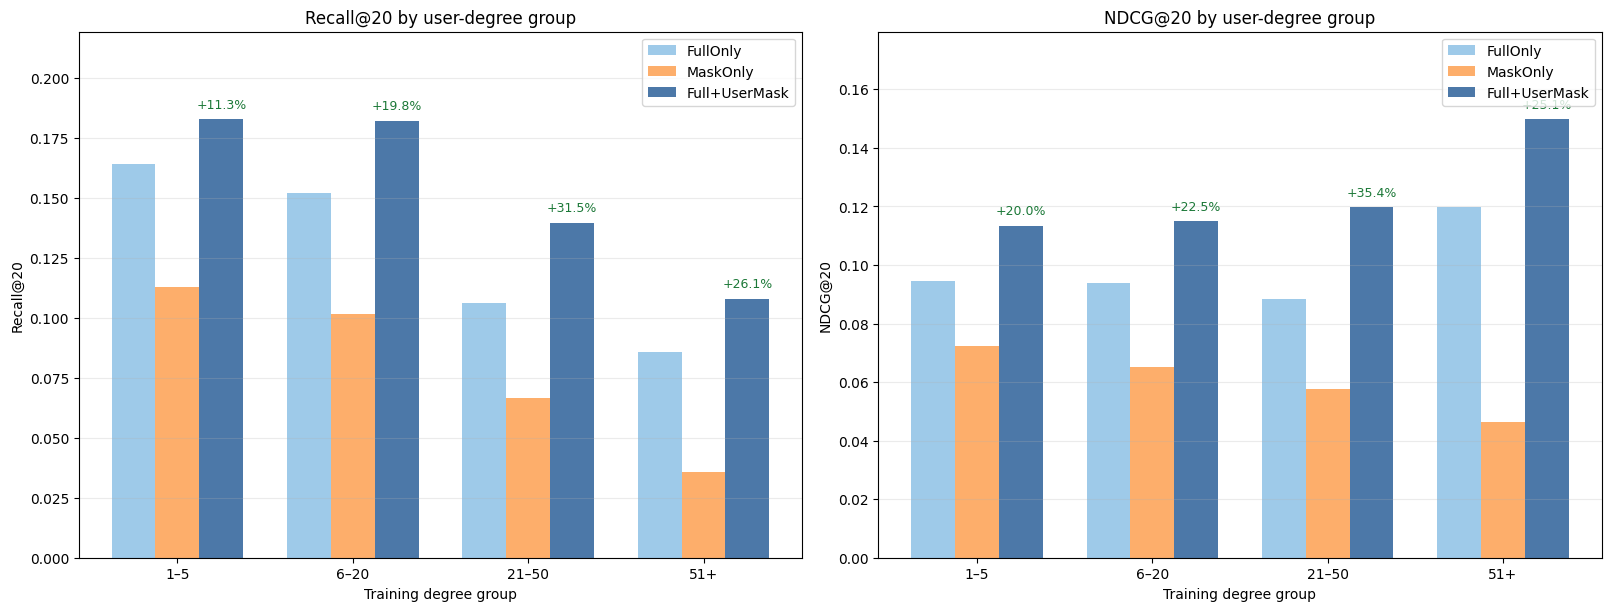

**Degree-performance conclusion:** The pooled degree-21+ users have a larger relative gain than degree-1–5 users for both Recall and NDCG, with bootstrap 95% contrast intervals above zero. This directly supports the claim that active users benefit more proportionally from Full+UserMask. The largest binned relative gains occur at degree 21–50 for Recall (+31.51%) and degree 21–50 for NDCG (+35.42%). Because the gain falls from 21–50 to 51+, the relationship is not strictly monotonic at the highest activity level.

In [24]:
display(Markdown("## 11. Performance by user-degree group"))

DEGREE_PERFORMANCE_BOOTSTRAPS = 2000
DEGREE_PERFORMANCE_SEED = 20260816
degree_performance_bin_specs = [
    ("1–5", 1, 5, "low activity"),
    ("6–20", 6, 20, "medium activity"),
    ("21–50", 21, 50, "high activity"),
    ("51+", 51, None, "very high activity"),
]

degree_performance_required = (
    "evaluation_user_ids", "user_degree", "model_mask_values",
    "full_only_recall", "mask_only_recall", "full_mask_recall",
    "full_only_ndcg", "mask_only_ndcg", "full_mask_ndcg",
    "GROUP_METRIC_K", "show_markdown_table", "paired_mean_ci95",
)
degree_performance_missing = [
    name for name in degree_performance_required if name not in globals()
]
if degree_performance_missing:
    raise RuntimeError(
        f"Missing {degree_performance_missing}. Run Mask-vs-degree and Analysis 8 first."
    )

degree_performance_eval_degrees = np.asarray(
    user_degree[evaluation_user_ids], dtype=np.int64
)
degree_performance_eval_masks = np.asarray(
    model_mask_values[evaluation_user_ids], dtype=np.float64
)
degree_performance_metric_arrays = (
    full_only_recall, mask_only_recall, full_mask_recall,
    full_only_ndcg, mask_only_ndcg, full_mask_ndcg,
)
if not all(
    np.asarray(values).shape == degree_performance_eval_degrees.shape
    for values in degree_performance_metric_arrays
):
    raise ValueError("Per-user metrics, test users, and degrees are not aligned.")

def paired_bootstrap_relative_gain(baseline, combined, rng, n_bootstrap, batch_size=100):
    baseline = np.asarray(baseline, dtype=np.float64)
    combined = np.asarray(combined, dtype=np.float64)
    if baseline.shape != combined.shape or baseline.size == 0:
        raise ValueError("Bootstrap inputs must be non-empty aligned arrays.")
    bootstrap_gains = np.empty(n_bootstrap, dtype=np.float64)
    for start in range(0, n_bootstrap, batch_size):
        stop = min(start + batch_size, n_bootstrap)
        sampled_rows = rng.integers(
            0, baseline.size, size=(stop - start, baseline.size)
        )
        sampled_baseline = baseline[sampled_rows].mean(axis=1)
        sampled_combined = combined[sampled_rows].mean(axis=1)
        bootstrap_gains[start:stop] = (
            (sampled_combined - sampled_baseline) / sampled_baseline * 100.0
        )
    return bootstrap_gains

degree_performance_rng = np.random.default_rng(DEGREE_PERFORMANCE_SEED)
degree_group_membership = np.zeros(evaluation_user_ids.size, dtype=np.int64)
degree_group_performance = []
degree_group_summary_rows = []
degree_group_recall_rows = []
degree_group_ndcg_rows = []

for group_index, (degree_label, lower, upper, activity_label) in enumerate(
    degree_performance_bin_specs
):
    if upper is None:
        group_rows = degree_performance_eval_degrees >= lower
    else:
        group_rows = (degree_performance_eval_degrees >= lower) & (
            degree_performance_eval_degrees <= upper
        )
    if not group_rows.any():
        raise ValueError(f"Degree group {degree_label} contains no test users.")
    degree_group_membership += group_rows.astype(np.int64)

    selected_degrees = degree_performance_eval_degrees[group_rows]
    selected_masks = degree_performance_eval_masks[group_rows]
    recall_full = full_only_recall[group_rows].mean()
    recall_mask_only = mask_only_recall[group_rows].mean()
    recall_full_mask = full_mask_recall[group_rows].mean()
    ndcg_full = full_only_ndcg[group_rows].mean()
    ndcg_mask_only = mask_only_ndcg[group_rows].mean()
    ndcg_full_mask = full_mask_ndcg[group_rows].mean()

    recall_user_differences = full_mask_recall[group_rows] - full_only_recall[group_rows]
    ndcg_user_differences = full_mask_ndcg[group_rows] - full_only_ndcg[group_rows]
    recall_diff, recall_ci_low, recall_ci_high = paired_mean_ci95(
        recall_user_differences
    )
    ndcg_diff, ndcg_ci_low, ndcg_ci_high = paired_mean_ci95(
        ndcg_user_differences
    )
    recall_gain_percent = recall_diff / recall_full * 100.0
    ndcg_gain_percent = ndcg_diff / ndcg_full * 100.0
    recall_gain_bootstrap = paired_bootstrap_relative_gain(
        full_only_recall[group_rows], full_mask_recall[group_rows],
        degree_performance_rng, DEGREE_PERFORMANCE_BOOTSTRAPS,
    )
    ndcg_gain_bootstrap = paired_bootstrap_relative_gain(
        full_only_ndcg[group_rows], full_mask_ndcg[group_rows],
        degree_performance_rng, DEGREE_PERFORMANCE_BOOTSTRAPS,
    )
    recall_gain_ci = np.quantile(recall_gain_bootstrap, [0.025, 0.975])
    ndcg_gain_ci = np.quantile(ndcg_gain_bootstrap, [0.025, 0.975])

    group_result = {
        "degree_group": degree_label, "activity": activity_label,
        "rows": group_rows, "users": int(group_rows.sum()),
        "mean_degree": selected_degrees.mean(),
        "median_degree": np.median(selected_degrees),
        "mean_mask": selected_masks.mean(),
        "recall_full": recall_full, "recall_mask_only": recall_mask_only,
        "recall_full_mask": recall_full_mask, "recall_diff": recall_diff,
        "recall_ci_low": recall_ci_low, "recall_ci_high": recall_ci_high,
        "recall_gain_percent": recall_gain_percent,
        "recall_gain_bootstrap": recall_gain_bootstrap,
        "recall_gain_ci": recall_gain_ci,
        "ndcg_full": ndcg_full, "ndcg_mask_only": ndcg_mask_only,
        "ndcg_full_mask": ndcg_full_mask, "ndcg_diff": ndcg_diff,
        "ndcg_ci_low": ndcg_ci_low, "ndcg_ci_high": ndcg_ci_high,
        "ndcg_gain_percent": ndcg_gain_percent,
        "ndcg_gain_bootstrap": ndcg_gain_bootstrap,
        "ndcg_gain_ci": ndcg_gain_ci,
    }
    degree_group_performance.append(group_result)
    degree_group_summary_rows.append(
        [
            degree_label, activity_label, f"{group_rows.sum():,}",
            f"{selected_degrees.mean():.3f}", f"{np.median(selected_degrees):.1f}",
            f"{selected_masks.mean():.8f}", f"{(1.0 - selected_masks).mean():.8f}",
        ]
    )
    degree_group_recall_rows.append(
        [
            degree_label, f"{recall_full:.8f}", f"{recall_mask_only:.8f}",
            f"{recall_full_mask:.8f}",
            f"{recall_diff:+.8f} [{recall_ci_low:+.8f}, {recall_ci_high:+.8f}]",
            f"{recall_gain_percent:+.3f}% "
            f"[{recall_gain_ci[0]:+.3f}%, {recall_gain_ci[1]:+.3f}%]",
        ]
    )
    degree_group_ndcg_rows.append(
        [
            degree_label, f"{ndcg_full:.8f}", f"{ndcg_mask_only:.8f}",
            f"{ndcg_full_mask:.8f}",
            f"{ndcg_diff:+.8f} [{ndcg_ci_low:+.8f}, {ndcg_ci_high:+.8f}]",
            f"{ndcg_gain_percent:+.3f}% "
            f"[{ndcg_gain_ci[0]:+.3f}%, {ndcg_gain_ci[1]:+.3f}%]",
        ]
    )

if not np.all(degree_group_membership == 1):
    uncovered = int(np.count_nonzero(degree_group_membership == 0))
    duplicated = int(np.count_nonzero(degree_group_membership > 1))
    raise RuntimeError(
        f"Degree bins must cover every test user exactly once; "
        f"uncovered={uncovered}, duplicated={duplicated}."
    )

show_markdown_table(
    [
        "degree group", "activity", "test users", "mean degree", "median degree",
        r"mean $m_u$", r"mean $1-m_u$",
    ],
    degree_group_summary_rows,
)
show_markdown_table(
    [
        "degree group", f"FullOnly R@{GROUP_METRIC_K}",
        f"MaskOnly R@{GROUP_METRIC_K}", f"Full+Mask R@{GROUP_METRIC_K}",
        "paired absolute gain [95% CI]", "relative gain [bootstrap 95% CI]",
    ],
    degree_group_recall_rows,
)
show_markdown_table(
    [
        "degree group", f"FullOnly N@{GROUP_METRIC_K}",
        f"MaskOnly N@{GROUP_METRIC_K}", f"Full+Mask N@{GROUP_METRIC_K}",
        "paired absolute gain [95% CI]", "relative gain [bootstrap 95% CI]",
    ],
    degree_group_ndcg_rows,
)

# Direct extreme-group test of the relative-gain hypothesis: 51+ versus 1–5.
low_activity_group = degree_group_performance[0]
high_activity_group = degree_group_performance[-1]
degree_relative_gain_contrasts = {}
degree_relative_gain_contrast_rows = []
for metric_prefix, metric_title in (
    ("recall", f"Recall@{GROUP_METRIC_K}"),
    ("ndcg", f"NDCG@{GROUP_METRIC_K}"),
):
    observed_contrast = (
        high_activity_group[f"{metric_prefix}_gain_percent"]
        - low_activity_group[f"{metric_prefix}_gain_percent"]
    )
    bootstrap_contrast = (
        high_activity_group[f"{metric_prefix}_gain_bootstrap"]
        - low_activity_group[f"{metric_prefix}_gain_bootstrap"]
    )
    contrast_ci = np.quantile(bootstrap_contrast, [0.025, 0.975])
    p_one_sided = (
        1.0 + np.count_nonzero(bootstrap_contrast <= 0.0)
    ) / (DEGREE_PERFORMANCE_BOOTSTRAPS + 1.0)
    degree_relative_gain_contrasts[metric_prefix] = {
        "contrast": observed_contrast, "ci_low": contrast_ci[0],
        "ci_high": contrast_ci[1], "p_one_sided_bootstrap": p_one_sided,
    }
    degree_relative_gain_contrast_rows.append(
        [
            metric_title,
            f"{low_activity_group[f'{metric_prefix}_gain_percent']:+.3f}%",
            f"{high_activity_group[f'{metric_prefix}_gain_percent']:+.3f}%",
            f"{observed_contrast:+.3f} pp",
            f"[{contrast_ci[0]:+.3f}, {contrast_ci[1]:+.3f}] pp",
            f"{p_one_sided:.6f}",
        ]
    )

show_markdown_table(
    [
        "metric", "1–5 relative gain", "51+ relative gain",
        "51+ minus 1–5", "bootstrap 95% CI",
        "one-sided bootstrap p (51+ > 1–5)",
    ],
    degree_relative_gain_contrast_rows,
)

# A broader, prespecified active-user contrast pools degree >= 21 for better power.
pooled_active_rows = degree_performance_eval_degrees >= 21
pooled_active_relative_gain_contrasts = {}
pooled_active_contrast_rows = []
for metric_prefix, metric_title, baseline_values, combined_values in (
    ("recall", f"Recall@{GROUP_METRIC_K}", full_only_recall, full_mask_recall),
    ("ndcg", f"NDCG@{GROUP_METRIC_K}", full_only_ndcg, full_mask_ndcg),
):
    active_baseline = baseline_values[pooled_active_rows]
    active_combined = combined_values[pooled_active_rows]
    active_gain_percent = (
        (active_combined.mean() - active_baseline.mean()) / active_baseline.mean() * 100.0
    )
    active_gain_bootstrap = paired_bootstrap_relative_gain(
        active_baseline, active_combined, degree_performance_rng,
        DEGREE_PERFORMANCE_BOOTSTRAPS,
    )
    low_gain_percent = low_activity_group[f"{metric_prefix}_gain_percent"]
    low_gain_bootstrap = low_activity_group[f"{metric_prefix}_gain_bootstrap"]
    observed_contrast = active_gain_percent - low_gain_percent
    bootstrap_contrast = active_gain_bootstrap - low_gain_bootstrap
    contrast_ci = np.quantile(bootstrap_contrast, [0.025, 0.975])
    tail_probability = (
        1.0 + np.count_nonzero(bootstrap_contrast <= 0.0)
    ) / (DEGREE_PERFORMANCE_BOOTSTRAPS + 1.0)
    pooled_active_relative_gain_contrasts[metric_prefix] = {
        "low_gain_percent": low_gain_percent,
        "active_gain_percent": active_gain_percent,
        "contrast": observed_contrast, "ci_low": contrast_ci[0],
        "ci_high": contrast_ci[1], "tail_probability": tail_probability,
    }
    pooled_active_contrast_rows.append(
        [
            metric_title, f"{low_gain_percent:+.3f}%", f"{active_gain_percent:+.3f}%",
            f"{observed_contrast:+.3f} pp",
            f"[{contrast_ci[0]:+.3f}, {contrast_ci[1]:+.3f}] pp",
            f"{tail_probability:.6f}",
        ]
    )

show_markdown_table(
    [
        "metric", "degree 1–5 relative gain", "degree 21+ relative gain",
        "21+ minus 1–5", "bootstrap 95% CI",
        "bootstrap Pr(contrast <= 0)",
    ],
    pooled_active_contrast_rows,
)

degree_plot_x = np.arange(len(degree_group_performance))
degree_plot_width = 0.25
figure, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

def plot_degree_group_metric(ax, metric_prefix, metric_title):
    full_values = np.asarray(
        [row[f"{metric_prefix}_full"] for row in degree_group_performance]
    )
    mask_only_values = np.asarray(
        [row[f"{metric_prefix}_mask_only"] for row in degree_group_performance]
    )
    full_mask_values = np.asarray(
        [row[f"{metric_prefix}_full_mask"] for row in degree_group_performance]
    )
    relative_gains = np.asarray(
        [row[f"{metric_prefix}_gain_percent"] for row in degree_group_performance]
    )
    ax.bar(
        degree_plot_x - degree_plot_width, full_values, degree_plot_width,
        label="FullOnly", color="#9ecae9",
    )
    ax.bar(
        degree_plot_x, mask_only_values, degree_plot_width,
        label="MaskOnly", color="#fdae6b",
    )
    combined_bars = ax.bar(
        degree_plot_x + degree_plot_width, full_mask_values, degree_plot_width,
        label="Full+UserMask", color="#4c78a8",
    )
    plot_maximum = max(full_values.max(), mask_only_values.max(), full_mask_values.max())
    for bar, relative_gain in zip(combined_bars, relative_gains):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + plot_maximum * 0.018,
            f"{relative_gain:+.1f}%", ha="center", va="bottom", fontsize=9,
            color="#1b7837" if relative_gain >= 0 else "#b22222",
        )
    ax.set(
        title=f"{metric_title} by user-degree group", xlabel="Training degree group",
        ylabel=metric_title, xticks=degree_plot_x,
        xticklabels=[row["degree_group"] for row in degree_group_performance],
    )
    ax.set_ylim(0, plot_maximum * 1.20)
    ax.grid(axis="y", alpha=0.25)
    ax.legend()

plot_degree_group_metric(axes[0], "recall", f"Recall@{GROUP_METRIC_K}")
plot_degree_group_metric(axes[1], "ndcg", f"NDCG@{GROUP_METRIC_K}")
plt.show()

pooled_recall_contrast = pooled_active_relative_gain_contrasts["recall"]
pooled_ndcg_contrast = pooled_active_relative_gain_contrasts["ndcg"]
pooled_supported_metrics = [
    metric_name
    for metric_name, contrast in (
        (f"Recall@{GROUP_METRIC_K}", pooled_recall_contrast),
        (f"NDCG@{GROUP_METRIC_K}", pooled_ndcg_contrast),
    )
    if contrast["ci_low"] > 0
]
best_recall_degree_group = max(
    degree_group_performance, key=lambda row: row["recall_gain_percent"]
)
best_ndcg_degree_group = max(
    degree_group_performance, key=lambda row: row["ndcg_gain_percent"]
)
peak_sentence = (
    f"The largest binned relative gains occur at degree "
    f"{best_recall_degree_group['degree_group']} for Recall "
    f"({best_recall_degree_group['recall_gain_percent']:+.2f}%) and degree "
    f"{best_ndcg_degree_group['degree_group']} for NDCG "
    f"({best_ndcg_degree_group['ndcg_gain_percent']:+.2f}%)."
)
if len(pooled_supported_metrics) == 2:
    degree_performance_conclusion = (
        f"The pooled degree-21+ users have a larger relative gain than degree-1–5 users for both "
        f"Recall and NDCG, with bootstrap 95% contrast intervals above zero. This directly supports "
        f"the claim that active users benefit more proportionally from Full+UserMask. {peak_sentence} "
        f"Because the gain falls from 21–50 to 51+, the relationship is not strictly monotonic at "
        f"the highest activity level."
    )
elif pooled_supported_metrics:
    degree_performance_conclusion = (
        f"The pooled degree-21+ users have a reliably larger relative gain for "
        f"{pooled_supported_metrics[0]}, but the result is not corroborated by both metrics. "
        f"Evidence that active users benefit more is metric-dependent. {peak_sentence}"
    )
else:
    degree_performance_conclusion = (
        f"The bootstrap contrast intervals do not establish a larger relative gain for pooled "
        f"degree-21+ users on either metric. The direct degree-group analysis does not support the "
        f"claim that active users benefit more proportionally. {peak_sentence}"
    )
display(Markdown(f"**Degree-performance conclusion:** {degree_performance_conclusion}"))

## 12. Test-positive count by user-degree group

$\rho_{\mathrm{Spearman}}(d_u^{train}, |\mathcal{I}_u^{test}|)=0.533007$ (two-sided $p=0.000e+00$).

| degree group | activity | users | mean train degree | mean test positives | mean 95% CI | median [IQR] | max | users with test positives > 20 | mean Recall increment from one hit | mean Recall@20 ceiling |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 1–5 | low activity | 3,126 | 3.877 | 2.2991 | [2.2549, 2.3433] | 2.0 [1.0, 3.0] | 8 | 0.00% | 0.580019 | 1.000000 |
| 6–20 | medium activity | 5,580 | 9.831 | 3.2082 | [3.1535, 3.2630] | 3.0 [2.0, 4.0] | 15 | 0.00% | 0.469222 | 1.000000 |
| 21–50 | high activity | 902 | 30.093 | 9.6851 | [9.3831, 9.9872] | 9.0 [6.0, 12.0] | 34 | 2.00% | 0.136738 | 0.996250 |
| 51+ | very high activity | 252 | 76.706 | 24.9246 | [23.5084, 26.3408] | 22.0 [17.0, 30.0] | 91 | 57.14% | 0.047473 | 0.826562 |

| degree group | FullOnly R@20 | FullOnly mean hits@20 | MaskOnly R@20 | MaskOnly mean hits@20 | Full+Mask R@20 | Full+Mask mean hits@20 |
| --- | --- | --- | --- | --- | --- | --- |
| 1–5 | 0.16426096 | 0.3704 | 0.11297033 | 0.2505 | 0.18277961 | 0.4098 |
| 6–20 | 0.15205464 | 0.4819 | 0.10165903 | 0.3059 | 0.18221425 | 0.5720 |
| 21–50 | 0.10622546 | 0.9967 | 0.06678695 | 0.6175 | 0.13969946 | 1.3082 |
| 51+ | 0.08562580 | 2.0437 | 0.03582581 | 0.7857 | 0.10798809 | 2.5437 |

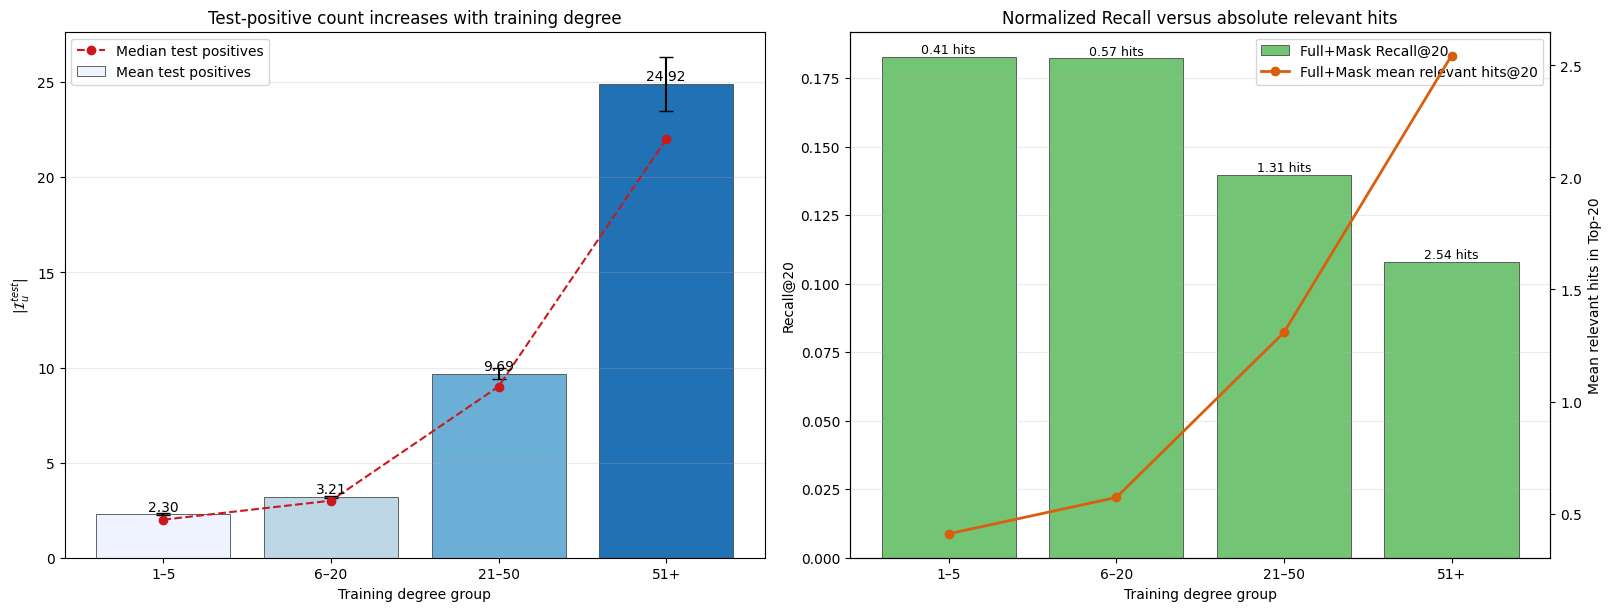

**Test-positive conclusion:** Degree-51+ users have 10.84x as many test positives as degree-1–5 users and Full+Mask retrieves more relevant items for them in absolute count (2.544 versus 0.410 hits/user), yet their normalized Recall is lower. This confirms that the Recall denominator and fixed Top-20 budget materially contribute to the lower Recall of active users, without claiming they are the only cause.

In [25]:
display(Markdown("## 12. Test-positive count by user-degree group"))

from scipy.stats import spearmanr

test_positive_required = (
    "degree_performance_bin_specs", "evaluation_user_ids",
    "evaluation_positive_lengths", "user_degree", "GROUP_METRIC_K",
    "full_only_recall", "mask_only_recall", "full_mask_recall",
    "show_markdown_table",
)
test_positive_missing = [
    name for name in test_positive_required if name not in globals()
]
if test_positive_missing:
    raise RuntimeError(
        f"Missing {test_positive_missing}. Run Analysis 8 and Analysis 11 first."
    )

test_positive_eval_degrees = np.asarray(
    user_degree[evaluation_user_ids], dtype=np.int64
)
test_positive_counts = np.asarray(evaluation_positive_lengths, dtype=np.int64)
if test_positive_eval_degrees.shape != test_positive_counts.shape:
    raise ValueError(
        f"Evaluation degrees and test-positive counts are not aligned: "
        f"{test_positive_eval_degrees.shape} versus {test_positive_counts.shape}."
    )
if np.any(test_positive_counts <= 0):
    raise ValueError("Every evaluated user must have at least one test-positive item.")
if not all(
    np.asarray(values).shape == test_positive_counts.shape
    for values in (full_only_recall, mask_only_recall, full_mask_recall)
):
    raise ValueError("Recall arrays and test-positive counts are not aligned.")

rho_degree_test_count, p_degree_test_count = spearmanr(
    test_positive_eval_degrees, test_positive_counts
)
display(
    Markdown(
        rf"$\rho_{{\mathrm{{Spearman}}}}(d_u^{{train}}, |\mathcal{{I}}_u^{{test}}|)"
        rf"={rho_degree_test_count:.6f}$ (two-sided $p={p_degree_test_count:.3e}$)."
    )
)

test_positive_group_membership = np.zeros(evaluation_user_ids.size, dtype=np.int64)
test_positive_group_statistics = []
test_positive_distribution_rows = []
test_positive_retrieval_rows = []
test_positive_group_values = []

for degree_label, lower, upper, activity_label in degree_performance_bin_specs:
    if upper is None:
        group_rows = test_positive_eval_degrees >= lower
    else:
        group_rows = (test_positive_eval_degrees >= lower) & (
            test_positive_eval_degrees <= upper
        )
    if not group_rows.any():
        raise ValueError(f"Degree group {degree_label} contains no evaluated users.")
    test_positive_group_membership += group_rows.astype(np.int64)

    group_degrees = test_positive_eval_degrees[group_rows]
    group_positive_counts = test_positive_counts[group_rows].astype(np.float64)
    group_recall_ceiling = np.minimum(
        GROUP_METRIC_K, group_positive_counts
    ) / group_positive_counts
    mean_positive_count = group_positive_counts.mean()
    positive_count_se = group_positive_counts.std(ddof=1) / np.sqrt(group_positive_counts.size)
    positive_count_ci_low = mean_positive_count - 1.96 * positive_count_se
    positive_count_ci_high = mean_positive_count + 1.96 * positive_count_se
    positive_q25, positive_median, positive_q75 = np.quantile(
        group_positive_counts, [0.25, 0.50, 0.75]
    )

    recall_full = full_only_recall[group_rows].mean()
    recall_mask_only = mask_only_recall[group_rows].mean()
    recall_full_mask = full_mask_recall[group_rows].mean()
    hits_full = (full_only_recall[group_rows] * group_positive_counts).mean()
    hits_mask_only = (mask_only_recall[group_rows] * group_positive_counts).mean()
    hits_full_mask = (full_mask_recall[group_rows] * group_positive_counts).mean()

    group_result = {
        "degree_group": degree_label, "activity": activity_label,
        "users": int(group_rows.sum()), "mean_degree": group_degrees.mean(),
        "mean_test_positives": mean_positive_count,
        "test_positive_ci_low": positive_count_ci_low,
        "test_positive_ci_high": positive_count_ci_high,
        "median_test_positives": positive_median,
        "test_positive_q25": positive_q25, "test_positive_q75": positive_q75,
        "max_test_positives": group_positive_counts.max(),
        "fraction_above_k": np.mean(group_positive_counts > GROUP_METRIC_K),
        "mean_single_hit_increment": np.mean(1.0 / group_positive_counts),
        "mean_recall_ceiling": group_recall_ceiling.mean(),
        "recall_full": recall_full, "recall_mask_only": recall_mask_only,
        "recall_full_mask": recall_full_mask,
        "hits_full": hits_full, "hits_mask_only": hits_mask_only,
        "hits_full_mask": hits_full_mask,
    }
    test_positive_group_statistics.append(group_result)
    test_positive_group_values.append(group_positive_counts)
    test_positive_distribution_rows.append(
        [
            degree_label, activity_label, f"{group_rows.sum():,}",
            f"{group_degrees.mean():.3f}", f"{mean_positive_count:.4f}",
            f"[{positive_count_ci_low:.4f}, {positive_count_ci_high:.4f}]",
            f"{positive_median:.1f} [{positive_q25:.1f}, {positive_q75:.1f}]",
            f"{group_positive_counts.max():.0f}",
            f"{np.mean(group_positive_counts > GROUP_METRIC_K):.2%}",
            f"{np.mean(1.0 / group_positive_counts):.6f}",
            f"{group_recall_ceiling.mean():.6f}",
        ]
    )
    test_positive_retrieval_rows.append(
        [
            degree_label, f"{recall_full:.8f}", f"{hits_full:.4f}",
            f"{recall_mask_only:.8f}", f"{hits_mask_only:.4f}",
            f"{recall_full_mask:.8f}", f"{hits_full_mask:.4f}",
        ]
    )

if not np.all(test_positive_group_membership == 1):
    raise RuntimeError("Degree groups must cover each evaluated user exactly once.")

show_markdown_table(
    [
        "degree group", "activity", "users", "mean train degree",
        "mean test positives", "mean 95% CI", "median [IQR]", "max",
        f"users with test positives > {GROUP_METRIC_K}",
        "mean Recall increment from one hit", f"mean Recall@{GROUP_METRIC_K} ceiling",
    ],
    test_positive_distribution_rows,
)
show_markdown_table(
    [
        "degree group", f"FullOnly R@{GROUP_METRIC_K}",
        f"FullOnly mean hits@{GROUP_METRIC_K}", f"MaskOnly R@{GROUP_METRIC_K}",
        f"MaskOnly mean hits@{GROUP_METRIC_K}", f"Full+Mask R@{GROUP_METRIC_K}",
        f"Full+Mask mean hits@{GROUP_METRIC_K}",
    ],
    test_positive_retrieval_rows,
)

test_positive_plot_x = np.arange(len(test_positive_group_statistics))
test_positive_means = np.asarray(
    [row["mean_test_positives"] for row in test_positive_group_statistics]
)
test_positive_medians = np.asarray(
    [row["median_test_positives"] for row in test_positive_group_statistics]
)
test_positive_ci_lows = np.asarray(
    [row["test_positive_ci_low"] for row in test_positive_group_statistics]
)
test_positive_ci_highs = np.asarray(
    [row["test_positive_ci_high"] for row in test_positive_group_statistics]
)
test_positive_errors = np.vstack(
    [test_positive_means - test_positive_ci_lows, test_positive_ci_highs - test_positive_means]
)

figure, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
axes[0].bar(
    test_positive_plot_x, test_positive_means, yerr=test_positive_errors, capsize=5,
    color=["#eff3ff", "#bdd7e7", "#6baed6", "#2171b5"],
    edgecolor="#4a4a4a", linewidth=0.6, label="Mean test positives",
)
axes[0].plot(
    test_positive_plot_x, test_positive_medians, color="#cb181d", marker="o",
    linestyle="--", label="Median test positives",
)
for x_value, mean_value in zip(test_positive_plot_x, test_positive_means):
    axes[0].text(x_value, mean_value, f"{mean_value:.2f}", ha="center", va="bottom")
axes[0].set(
    title="Test-positive count increases with training degree",
    xlabel="Training degree group", ylabel=r"$|\mathcal{I}_u^{test}|$",
    xticks=test_positive_plot_x,
    xticklabels=[row["degree_group"] for row in test_positive_group_statistics],
)
axes[0].grid(axis="y", alpha=0.25)
axes[0].legend()

full_mask_group_recall = np.asarray(
    [row["recall_full_mask"] for row in test_positive_group_statistics]
)
full_mask_group_hits = np.asarray(
    [row["hits_full_mask"] for row in test_positive_group_statistics]
)
recall_bars = axes[1].bar(
    test_positive_plot_x, full_mask_group_recall, color="#74c476",
    edgecolor="#4a4a4a", linewidth=0.6, label=f"Full+Mask Recall@{GROUP_METRIC_K}",
)
axes[1].set(
    title="Normalized Recall versus absolute relevant hits",
    xlabel="Training degree group", ylabel=f"Recall@{GROUP_METRIC_K}",
    xticks=test_positive_plot_x,
    xticklabels=[row["degree_group"] for row in test_positive_group_statistics],
)
axes[1].grid(axis="y", alpha=0.25)
hits_axis = axes[1].twinx()
hits_axis.plot(
    test_positive_plot_x, full_mask_group_hits, color="#d95f0e", marker="o",
    linewidth=2, label=f"Full+Mask mean relevant hits@{GROUP_METRIC_K}",
)
hits_axis.set_ylabel(f"Mean relevant hits in Top-{GROUP_METRIC_K}")
for bar, hit_count in zip(recall_bars, full_mask_group_hits):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height(),
        f"{hit_count:.2f} hits", ha="center", va="bottom", fontsize=9,
    )
left_handles, left_labels = axes[1].get_legend_handles_labels()
right_handles, right_labels = hits_axis.get_legend_handles_labels()
axes[1].legend(left_handles + right_handles, left_labels + right_labels, loc="best")
plt.show()

low_positive_group = test_positive_group_statistics[0]
very_active_positive_group = test_positive_group_statistics[-1]
positive_count_ratio = (
    very_active_positive_group["mean_test_positives"]
    / low_positive_group["mean_test_positives"]
)
if (
    very_active_positive_group["mean_test_positives"]
    > low_positive_group["mean_test_positives"]
    and very_active_positive_group["hits_full_mask"]
    > low_positive_group["hits_full_mask"]
    and very_active_positive_group["recall_full_mask"]
    < low_positive_group["recall_full_mask"]
):
    test_positive_conclusion = (
        f"Degree-51+ users have {positive_count_ratio:.2f}x as many test positives as degree-1–5 "
        f"users and Full+Mask retrieves more relevant items for them in absolute count "
        f"({very_active_positive_group['hits_full_mask']:.3f} versus "
        f"{low_positive_group['hits_full_mask']:.3f} hits/user), yet their normalized Recall is lower. "
        f"This confirms that the Recall denominator and fixed Top-{GROUP_METRIC_K} budget materially "
        f"contribute to the lower Recall of active users, without claiming they are the only cause."
    )
else:
    test_positive_conclusion = (
        f"The expected pattern is not fully present: compare test-positive count, relevant hits, and "
        f"normalized Recall in the table before attributing the degree trend to the denominator."
    )
display(Markdown(f"**Test-positive conclusion:** {test_positive_conclusion}"))

## 13. Lowest-mask tails: degree and performance gain

**Cohort definition:** tails are selected by exact rank over all users. `Lowest 1%` is contained in `Lowest 5%`, which is contained in `Lowest 10%`; therefore these three rows are descriptive nested cohorts, not independent groups. `Remaining 90%` is the disjoint complement of `Lowest 10%` and serves as a reference.

| mask tail | all users | test users | $m_u$ range / cutoff | mean $m_u$ | mean $1-m_u$ | all-user degree range | mean degree | median degree [IQR] | test-user degree range |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Lowest 1% | 110 | 80 | [0.75212465, 0.91320928] | 0.87230408 | 0.12769592 | [1, 19] | 4.336 | 4.0 [2.0, 5.0] | [1, 19] |
| Lowest 5% | 550 | 460 | [0.75212465, 0.98260031] | 0.94500863 | 0.05499137 | [1, 31] | 4.667 | 4.0 [2.0, 6.0] | [1, 31] |
| Lowest 10% | 1,100 | 929 | [0.75212465, 0.98844789] | 0.96564289 | 0.03435711 | [1, 31] | 4.691 | 4.0 [2.0, 6.0] | [1, 31] |
| Remaining 90% | 9,900 | 8,931 | [0.98844925, 0.99918599] | 0.99433731 | 0.00566269 | [1, 253] | 11.647 | 7.0 [5.0, 12.0] | [1, 253] |

| mask tail | test users | mean $m_u$ | FullOnly R@20 | MaskOnly R@20 | Full+Mask R@20 | paired absolute gain [95% CI] | relative gain [bootstrap 95% CI] |
| --- | --- | --- | --- | --- | --- | --- | --- |
| Lowest 1% | 80 | 0.87230408 | 0.41023810 | 0.36395833 | 0.46794643 | +0.05770833 [+0.00821140, +0.10720527] | +14.067% [+2.970%, +30.271%] |
| Lowest 5% | 460 | 0.94500863 | 0.30566225 | 0.26509132 | 0.33248730 | +0.02682504 [+0.01053066, +0.04311943] | +8.776% [+3.424%, +14.471%] |
| Lowest 10% | 929 | 0.96564289 | 0.25351442 | 0.20812006 | 0.28013828 | +0.02662386 [+0.01376338, +0.03948434] | +10.502% [+5.591%, +16.255%] |
| Remaining 90% | 8,931 | 0.99433731 | 0.13927027 | 0.08916460 | 0.16583787 | +0.02656759 [+0.02258487, +0.03055032] | +19.076% [+15.959%, +22.194%] |

| mask tail | test users | mean $m_u$ | FullOnly N@20 | MaskOnly N@20 | Full+Mask N@20 | paired absolute gain [95% CI] | relative gain [bootstrap 95% CI] |
| --- | --- | --- | --- | --- | --- | --- | --- |
| Lowest 1% | 80 | 0.87230408 | 0.24942099 | 0.21183009 | 0.29031603 | +0.04089504 [+0.01554442, +0.06624565] | +16.396% [+6.305%, +29.203%] |
| Lowest 5% | 460 | 0.94500863 | 0.18917273 | 0.16489106 | 0.20574795 | +0.01657522 [+0.00695601, +0.02619444] | +8.762% [+3.811%, +14.563%] |
| Lowest 10% | 929 | 0.96564289 | 0.15475761 | 0.12918641 | 0.17080472 | +0.01604710 [+0.00929331, +0.02280090] | +10.369% [+5.861%, +15.248%] |
| Remaining 90% | 8,931 | 0.99433731 | 0.08795298 | 0.05977402 | 0.11013843 | +0.02218545 [+0.01989997, +0.02447093] | +25.224% [+22.305%, +28.313%] |

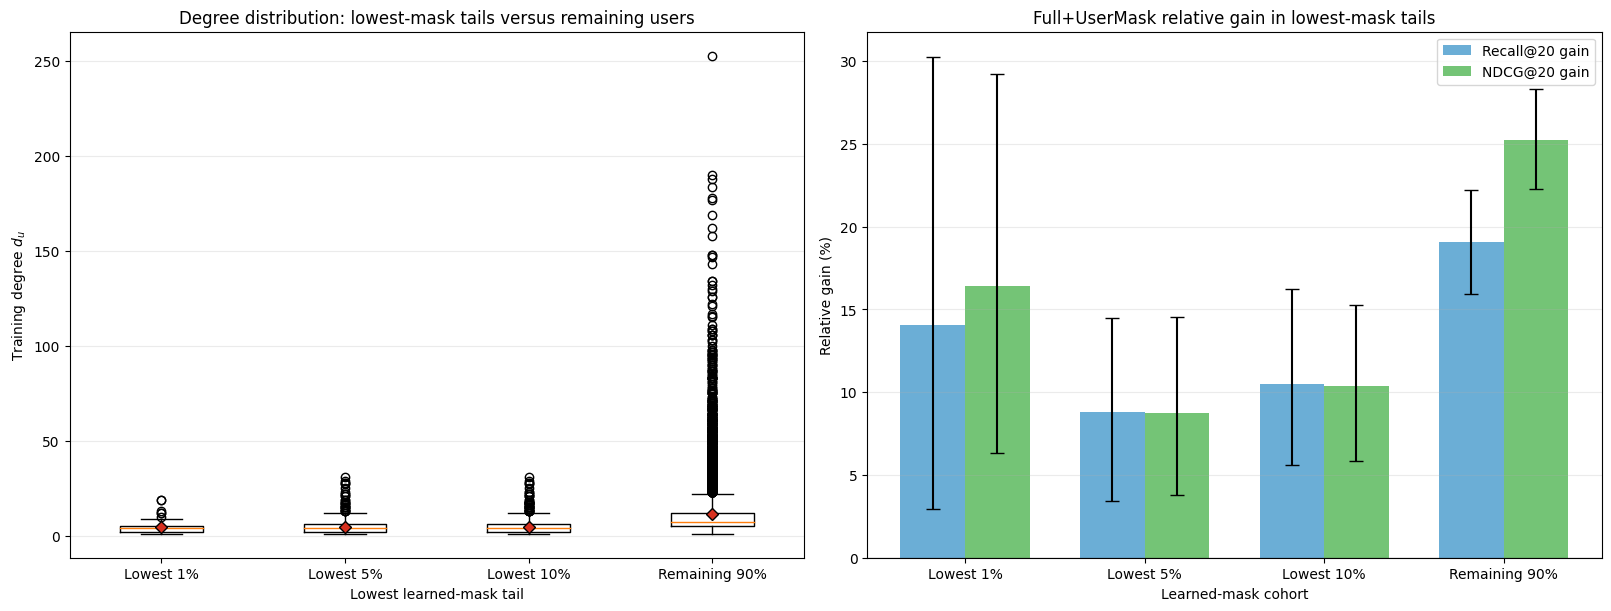

**Lowest-mask-tail conclusion:** The lowest 1% masks cover degrees 1–19 (median 4.0). The largest Recall relative gain among these nested tails occurs in Lowest 1% (+14.07%), while the largest NDCG gain occurs in Lowest 1% (+16.40%). The disjoint Remaining 90% reference has mean mask 0.994337, Recall gain +19.08%, and NDCG gain +25.22%. Because the cohorts overlap, differences across 1%, 5%, and 10% should be interpreted as tail-sensitivity patterns rather than independent-group effects.

In [26]:
display(Markdown("## 13. Lowest-mask tails: degree and performance gain"))

LOWEST_MASK_PERCENTAGES = (1, 5, 10)
LOWEST_MASK_BOOTSTRAPS = 2000
LOWEST_MASK_SEED = 20260816

lowest_mask_required = (
    "model_mask_values", "user_degree", "evaluation_user_ids",
    "full_only_recall", "mask_only_recall", "full_mask_recall",
    "full_only_ndcg", "mask_only_ndcg", "full_mask_ndcg",
    "GROUP_METRIC_K", "show_markdown_table", "paired_mean_ci95",
)
lowest_mask_missing = [name for name in lowest_mask_required if name not in globals()]
if lowest_mask_missing:
    raise RuntimeError(
        f"Missing {lowest_mask_missing}. Run Mask-vs-degree and Analysis 8 first."
    )

lowest_mask_values = np.asarray(model_mask_values, dtype=np.float64)
lowest_mask_degrees = np.asarray(user_degree, dtype=np.int64)
if lowest_mask_values.shape != lowest_mask_degrees.shape:
    raise ValueError("All-user mask values and degrees are not aligned.")
if not all(
    np.asarray(values).shape == evaluation_user_ids.shape
    for values in (
        full_only_recall, mask_only_recall, full_mask_recall,
        full_only_ndcg, mask_only_ndcg, full_mask_ndcg,
    )
):
    raise ValueError("Per-user evaluation metrics are not aligned with evaluation_user_ids.")

def lowest_mask_bootstrap_relative_gain(
    baseline, combined, rng, n_bootstrap, batch_size=100
):
    baseline = np.asarray(baseline, dtype=np.float64)
    combined = np.asarray(combined, dtype=np.float64)
    if baseline.shape != combined.shape or baseline.size == 0:
        raise ValueError("Bootstrap inputs must be non-empty aligned arrays.")
    bootstrap_gain = np.empty(n_bootstrap, dtype=np.float64)
    for start in range(0, n_bootstrap, batch_size):
        stop = min(start + batch_size, n_bootstrap)
        sampled_rows = rng.integers(
            0, baseline.size, size=(stop - start, baseline.size)
        )
        sampled_baseline = baseline[sampled_rows].mean(axis=1)
        sampled_combined = combined[sampled_rows].mean(axis=1)
        bootstrap_gain[start:stop] = (
            (sampled_combined - sampled_baseline) / sampled_baseline * 100.0
        )
    return bootstrap_gain

# Rank-based selection guarantees exact tail sizes even if empirical quantile cutoffs tie.
lowest_mask_rank_order = np.argsort(lowest_mask_values, kind="stable")
lowest_mask_rng = np.random.default_rng(LOWEST_MASK_SEED)
lowest_mask_tail_results = []
lowest_mask_degree_rows = []
lowest_mask_recall_rows = []
lowest_mask_ndcg_rows = []
lowest_mask_degree_values_for_plot = []
previous_selected_users = None

lowest_mask_cohort_specs = []
for percentage in LOWEST_MASK_PERCENTAGES:
    selected_count = max(1, int(round(lowest_mask_values.size * percentage / 100.0)))
    lowest_mask_cohort_specs.append(
        (f"Lowest {percentage}%", percentage, lowest_mask_rank_order[:selected_count], True)
    )
remaining_start = max(
    1, int(round(lowest_mask_values.size * max(LOWEST_MASK_PERCENTAGES) / 100.0))
)
lowest_mask_cohort_specs.append(
    ("Remaining 90%", 100 - max(LOWEST_MASK_PERCENTAGES),
     lowest_mask_rank_order[remaining_start:], False)
)

for tail_label, percentage, selected_user_ids, is_lowest_tail in lowest_mask_cohort_specs:
    selected_count = selected_user_ids.size
    if is_lowest_tail:
        if previous_selected_users is not None and not np.all(
            np.isin(previous_selected_users, selected_user_ids)
        ):
            raise RuntimeError("Lowest-mask tail cohorts must be nested.")
        previous_selected_users = selected_user_ids

    selected_masks = lowest_mask_values[selected_user_ids]
    selected_degrees = lowest_mask_degrees[selected_user_ids]
    selected_eval_rows = np.isin(evaluation_user_ids, selected_user_ids)
    if not selected_eval_rows.any():
        raise ValueError(f"Lowest {percentage}% tail contains no evaluated users.")
    selected_eval_degrees = lowest_mask_degrees[evaluation_user_ids[selected_eval_rows]]

    recall_full = full_only_recall[selected_eval_rows].mean()
    recall_mask_only = mask_only_recall[selected_eval_rows].mean()
    recall_full_mask = full_mask_recall[selected_eval_rows].mean()
    ndcg_full = full_only_ndcg[selected_eval_rows].mean()
    ndcg_mask_only = mask_only_ndcg[selected_eval_rows].mean()
    ndcg_full_mask = full_mask_ndcg[selected_eval_rows].mean()

    recall_user_differences = (
        full_mask_recall[selected_eval_rows] - full_only_recall[selected_eval_rows]
    )
    ndcg_user_differences = (
        full_mask_ndcg[selected_eval_rows] - full_only_ndcg[selected_eval_rows]
    )
    recall_diff, recall_ci_low, recall_ci_high = paired_mean_ci95(
        recall_user_differences
    )
    ndcg_diff, ndcg_ci_low, ndcg_ci_high = paired_mean_ci95(ndcg_user_differences)
    recall_gain_percent = recall_diff / recall_full * 100.0
    ndcg_gain_percent = ndcg_diff / ndcg_full * 100.0
    recall_gain_bootstrap = lowest_mask_bootstrap_relative_gain(
        full_only_recall[selected_eval_rows], full_mask_recall[selected_eval_rows],
        lowest_mask_rng, LOWEST_MASK_BOOTSTRAPS,
    )
    ndcg_gain_bootstrap = lowest_mask_bootstrap_relative_gain(
        full_only_ndcg[selected_eval_rows], full_mask_ndcg[selected_eval_rows],
        lowest_mask_rng, LOWEST_MASK_BOOTSTRAPS,
    )
    recall_gain_bootstrap_ci = np.quantile(recall_gain_bootstrap, [0.025, 0.975])
    ndcg_gain_bootstrap_ci = np.quantile(ndcg_gain_bootstrap, [0.025, 0.975])
    degree_q25, degree_median, degree_q75 = np.quantile(
        selected_degrees, [0.25, 0.50, 0.75]
    )

    tail_result = {
        "label": tail_label, "percentage": percentage,
        "is_lowest_tail": is_lowest_tail,
        "all_users": selected_count, "test_users": int(selected_eval_rows.sum()),
        "mask_min": selected_masks.min(), "mask_cutoff": selected_masks.max(),
        "mean_mask": selected_masks.mean(),
        "mean_attenuation": (1.0 - selected_masks).mean(),
        "degree_min": selected_degrees.min(), "degree_max": selected_degrees.max(),
        "degree_mean": selected_degrees.mean(), "degree_median": degree_median,
        "degree_q25": degree_q25, "degree_q75": degree_q75,
        "test_degree_min": selected_eval_degrees.min(),
        "test_degree_max": selected_eval_degrees.max(),
        "recall_full": recall_full, "recall_mask_only": recall_mask_only,
        "recall_full_mask": recall_full_mask, "recall_diff": recall_diff,
        "recall_ci_low": recall_ci_low, "recall_ci_high": recall_ci_high,
        "recall_gain_percent": recall_gain_percent,
        "recall_gain_bootstrap_ci": recall_gain_bootstrap_ci,
        "ndcg_full": ndcg_full, "ndcg_mask_only": ndcg_mask_only,
        "ndcg_full_mask": ndcg_full_mask, "ndcg_diff": ndcg_diff,
        "ndcg_ci_low": ndcg_ci_low, "ndcg_ci_high": ndcg_ci_high,
        "ndcg_gain_percent": ndcg_gain_percent,
        "ndcg_gain_bootstrap_ci": ndcg_gain_bootstrap_ci,
    }
    lowest_mask_tail_results.append(tail_result)
    lowest_mask_degree_values_for_plot.append(selected_degrees)
    lowest_mask_degree_rows.append(
        [
            tail_label, f"{selected_count:,}", f"{selected_eval_rows.sum():,}",
            f"[{selected_masks.min():.8f}, {selected_masks.max():.8f}]",
            f"{selected_masks.mean():.8f}", f"{(1.0 - selected_masks).mean():.8f}",
            f"[{selected_degrees.min()}, {selected_degrees.max()}]",
            f"{selected_degrees.mean():.3f}",
            f"{degree_median:.1f} [{degree_q25:.1f}, {degree_q75:.1f}]",
            f"[{selected_eval_degrees.min()}, {selected_eval_degrees.max()}]",
        ]
    )
    lowest_mask_recall_rows.append(
        [
            tail_label, f"{selected_eval_rows.sum():,}", f"{selected_masks.mean():.8f}",
            f"{recall_full:.8f}",
            f"{recall_mask_only:.8f}", f"{recall_full_mask:.8f}",
            f"{recall_diff:+.8f} [{recall_ci_low:+.8f}, {recall_ci_high:+.8f}]",
            f"{recall_gain_percent:+.3f}% "
            f"[{recall_gain_bootstrap_ci[0]:+.3f}%, {recall_gain_bootstrap_ci[1]:+.3f}%]",
        ]
    )
    lowest_mask_ndcg_rows.append(
        [
            tail_label, f"{selected_eval_rows.sum():,}", f"{selected_masks.mean():.8f}",
            f"{ndcg_full:.8f}",
            f"{ndcg_mask_only:.8f}", f"{ndcg_full_mask:.8f}",
            f"{ndcg_diff:+.8f} [{ndcg_ci_low:+.8f}, {ndcg_ci_high:+.8f}]",
            f"{ndcg_gain_percent:+.3f}% "
            f"[{ndcg_gain_bootstrap_ci[0]:+.3f}%, {ndcg_gain_bootstrap_ci[1]:+.3f}%]",
        ]
    )

display(
    Markdown(
        "**Cohort definition:** tails are selected by exact rank over all users. "
        "`Lowest 1%` is contained in `Lowest 5%`, which is contained in `Lowest 10%`; "
        "therefore these three rows are descriptive nested cohorts, not independent groups. "
        "`Remaining 90%` is the disjoint complement of `Lowest 10%` and serves as a reference."
    )
)
show_markdown_table(
    [
        "mask tail", "all users", "test users", r"$m_u$ range / cutoff",
        r"mean $m_u$", r"mean $1-m_u$", "all-user degree range",
        "mean degree", "median degree [IQR]", "test-user degree range",
    ],
    lowest_mask_degree_rows,
)
show_markdown_table(
    [
        "mask tail", "test users", r"mean $m_u$",
        f"FullOnly R@{GROUP_METRIC_K}",
        f"MaskOnly R@{GROUP_METRIC_K}", f"Full+Mask R@{GROUP_METRIC_K}",
        "paired absolute gain [95% CI]", "relative gain [bootstrap 95% CI]",
    ],
    lowest_mask_recall_rows,
)
show_markdown_table(
    [
        "mask tail", "test users", r"mean $m_u$",
        f"FullOnly N@{GROUP_METRIC_K}",
        f"MaskOnly N@{GROUP_METRIC_K}", f"Full+Mask N@{GROUP_METRIC_K}",
        "paired absolute gain [95% CI]", "relative gain [bootstrap 95% CI]",
    ],
    lowest_mask_ndcg_rows,
)

figure, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
axes[0].boxplot(
    lowest_mask_degree_values_for_plot, labels=[row["label"] for row in lowest_mask_tail_results],
    showmeans=True, showfliers=True,
    meanprops={"marker": "D", "markerfacecolor": "#d7301f", "markeredgecolor": "black"},
)
axes[0].set(
    title="Degree distribution: lowest-mask tails versus remaining users",
    xlabel=r"Lowest learned-mask tail", ylabel=r"Training degree $d_u$",
)
axes[0].grid(axis="y", alpha=0.25)

tail_plot_x = np.arange(len(lowest_mask_tail_results))
tail_plot_width = 0.36
recall_gains = np.asarray([row["recall_gain_percent"] for row in lowest_mask_tail_results])
ndcg_gains = np.asarray([row["ndcg_gain_percent"] for row in lowest_mask_tail_results])
recall_gain_cis = np.asarray(
    [row["recall_gain_bootstrap_ci"] for row in lowest_mask_tail_results]
)
ndcg_gain_cis = np.asarray(
    [row["ndcg_gain_bootstrap_ci"] for row in lowest_mask_tail_results]
)
recall_gain_errors = np.vstack(
    [recall_gains - recall_gain_cis[:, 0], recall_gain_cis[:, 1] - recall_gains]
)
ndcg_gain_errors = np.vstack(
    [ndcg_gains - ndcg_gain_cis[:, 0], ndcg_gain_cis[:, 1] - ndcg_gains]
)
axes[1].bar(
    tail_plot_x - tail_plot_width / 2, recall_gains, tail_plot_width,
    yerr=recall_gain_errors, capsize=5, label=f"Recall@{GROUP_METRIC_K} gain",
    color="#6baed6",
)
axes[1].bar(
    tail_plot_x + tail_plot_width / 2, ndcg_gains, tail_plot_width,
    yerr=ndcg_gain_errors, capsize=5, label=f"NDCG@{GROUP_METRIC_K} gain",
    color="#74c476",
)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set(
    title="Full+UserMask relative gain in lowest-mask tails",
    xlabel="Learned-mask cohort", ylabel="Relative gain (%)",
    xticks=tail_plot_x, xticklabels=[row["label"] for row in lowest_mask_tail_results],
)
axes[1].grid(axis="y", alpha=0.25)
axes[1].legend()
plt.show()

nested_tail_results = [row for row in lowest_mask_tail_results if row["is_lowest_tail"]]
remaining_mask_result = next(
    row for row in lowest_mask_tail_results if not row["is_lowest_tail"]
)
best_tail_recall = max(nested_tail_results, key=lambda row: row["recall_gain_percent"])
best_tail_ndcg = max(nested_tail_results, key=lambda row: row["ndcg_gain_percent"])
lowest_one_percent = nested_tail_results[0]
display(
    Markdown(
        f"**Lowest-mask-tail conclusion:** The lowest 1% masks cover degrees "
        f"{lowest_one_percent['degree_min']}–{lowest_one_percent['degree_max']} "
        f"(median {lowest_one_percent['degree_median']:.1f}). The largest Recall relative gain "
        f"among these nested tails occurs in {best_tail_recall['label']} "
        f"({best_tail_recall['recall_gain_percent']:+.2f}%), while the largest NDCG gain "
        f"occurs in {best_tail_ndcg['label']} ({best_tail_ndcg['ndcg_gain_percent']:+.2f}%). "
        f"The disjoint Remaining 90% reference has mean mask "
        f"{remaining_mask_result['mean_mask']:.6f}, Recall gain "
        f"{remaining_mask_result['recall_gain_percent']:+.2f}%, and NDCG gain "
        f"{remaining_mask_result['ndcg_gain_percent']:+.2f}%. "
        f"Because the cohorts overlap, differences across 1%, 5%, and 10% should be interpreted "
        f"as tail-sensitivity patterns rather than independent-group effects."
    )
)

## 14. Inference-time mask intervention and strength curve

**Frozen-checkpoint intervention:** all trained parameters remain fixed. Only the inference-time edge mask is replaced by $m_u(\alpha)=1-\alpha(1-m_u)$. At $\alpha=0$, the realized mask is exactly one; at $\alpha=1$, the original learned logits are used exactly.

| $\alpha$ | intervention | mean effective $m_u$ | effective $m_u$ range | mean effective $1-m_u$ | Recall@20 | paired $\Delta R$ vs $\alpha=0$ [95% CI] | relative $\Delta R$ vs $\alpha=0$ | NDCG@20 | paired $\Delta N$ vs $\alpha=0$ [95% CI] | relative $\Delta N$ vs $\alpha=0$ |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 0.00 | all-one mask / no modulation | 1.00000000 | [1.00000000, 1.00000000] | 0.00000000 | 0.17715894 | +0.00000000 [+0.00000000, +0.00000000] | +0.0000% | 0.11598509 | +0.00000000 [+0.00000000, +0.00000000] | +0.0000% |
| 0.25 | 25% of learned deviation | 0.99786699 | [0.93803114, 0.99979657] | 0.00213303 | 0.17674173 | -0.00041721 [-0.00083335, -0.00000107] | -0.2355% | 0.11589848 | -0.00008661 [-0.00020262, +0.00002940] | -0.0747% |
| 0.50 | 50% of learned deviation | 0.99573398 | [0.87606233, 0.99959308] | 0.00426607 | 0.17664801 | -0.00051093 [-0.00109501, +0.00007315] | -0.2884% | 0.11585084 | -0.00013425 [-0.00031303, +0.00004454] | -0.1157% |
| 0.75 | 75% of learned deviation | 0.99360090 | [0.81409347, 0.99938941] | 0.00639910 | 0.17653449 | -0.00062445 [-0.00122903, -0.00001988] | -0.3525% | 0.11581964 | -0.00016545 [-0.00036724, +0.00003635] | -0.1426% |
| 1.00 | learned mask | 0.99146783 | [0.75212467, 0.99918598] | 0.00853213 | 0.17660715 | -0.00055180 [-0.00114528, +0.00004169] | -0.3115% | 0.11585435 | -0.00013074 [-0.00036282, +0.00010135] | -0.1127% |

| metric | all-one mask ($\alpha=0$) | learned mask ($\alpha=1$) | learned minus all-one | paired 95% CI | relative change |
| --- | --- | --- | --- | --- | --- |
| Recall@20 | 0.17715894 | 0.17660715 | -0.00055180 | [-0.00114528, +0.00004169] | -0.3115% |
| NDCG@20 | 0.11598509 | 0.11585435 | -0.00013074 | [-0.00036282, +0.00010135] | -0.1127% |

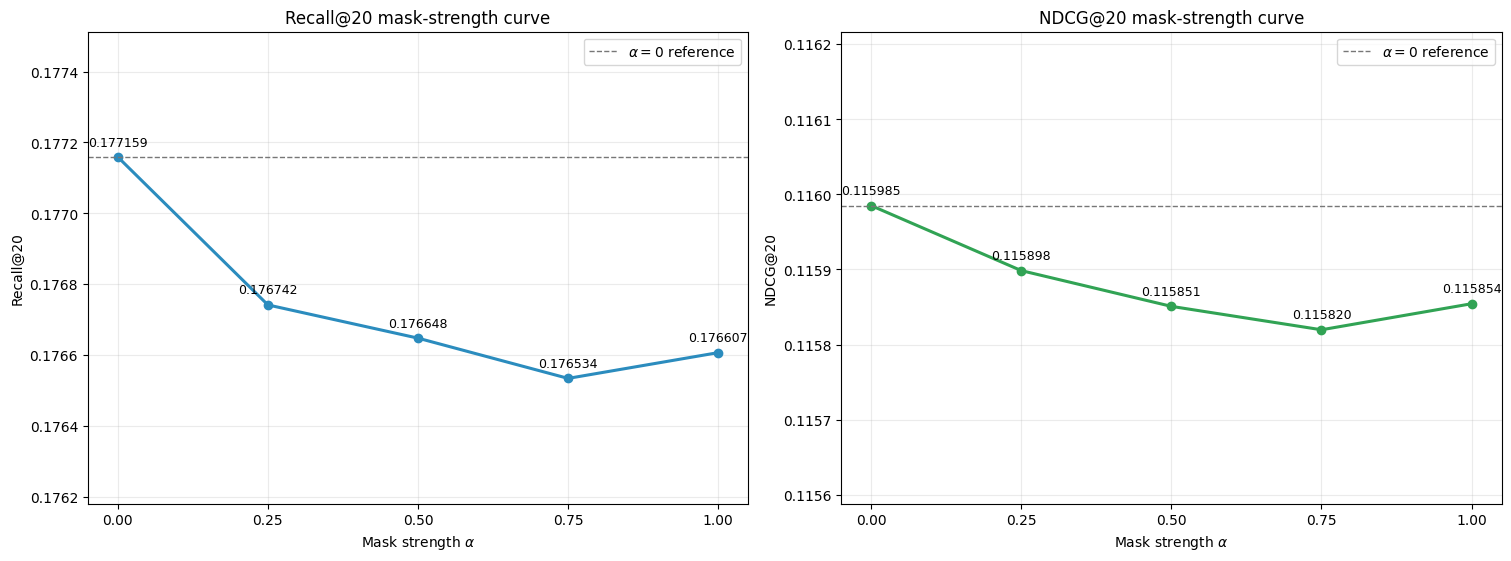

**Mask-strength conclusion:** Both learned-minus-all-one paired 95% CIs include zero. The point estimates slightly favor the all-one intervention, but the differences are not reliable. The current checkpoint does not show evidence that the small deviations are important as inference-time weights; their main role may instead be during optimization/training.

In [27]:
display(Markdown("## 14. Inference-time mask intervention and strength curve"))

MASK_STRENGTH_ALPHAS = (0.0, 0.25, 0.50, 0.75, 1.0)

mask_strength_required = (
    "permutation_model", "permutation_test_data", "permutation_device",
    "learned_user_mask_logits", "recompute_result_embedding",
    "evaluation_user_ids", "evaluation_positive_sets",
    "evaluation_positive_lengths", "per_user_recall_and_ndcg",
    "full_mask_recall", "full_mask_ndcg", "paired_mean_ci95",
    "GROUP_METRIC_K", "show_markdown_table",
)
mask_strength_missing = [name for name in mask_strength_required if name not in globals()]
if mask_strength_missing:
    raise RuntimeError(
        f"Missing {mask_strength_missing}. Run the permutation setup and Analysis 8 first."
    )

trainable_parameter_names = [
    name for name, parameter in permutation_model.named_parameters()
    if parameter.requires_grad
]
if trainable_parameter_names:
    raise RuntimeError(
        f"The intervention requires a fully frozen model; trainable={trainable_parameter_names}."
    )
if not torch.isfinite(learned_user_mask_logits).all():
    raise ValueError("The learned checkpoint mask logits must be finite.")

learned_mask_for_strength_curve = torch.sigmoid(
    learned_user_mask_logits
).detach().clone()

@torch.no_grad()
def collect_current_mask_strength_topk():
    permutation_model.eval()
    recompute_result_embedding()
    permutation_test_data.pr = 0
    permutation_test_data.inter_pr = 0
    topk_batches = []
    try:
        for batched_data in permutation_test_data:
            scores = permutation_model.full_sort_predict(batched_data)
            training_items = batched_data[1]
            scores[training_items[0], training_items[1]] = -1e10
            topk_batches.append(
                torch.topk(scores, GROUP_METRIC_K, dim=-1).indices.cpu()
            )
    finally:
        permutation_test_data.pr = 0
        permutation_test_data.inter_pr = 0
    topk_items = torch.cat(topk_batches, dim=0).numpy()
    if topk_items.shape[0] != evaluation_user_ids.size:
        raise RuntimeError("Mask-strength rankings are not aligned with evaluation users.")
    return topk_items

mask_strength_results = []
try:
    for alpha in MASK_STRENGTH_ALPHAS:
        effective_mask = 1.0 - alpha * (1.0 - learned_mask_for_strength_curve)
        with torch.no_grad():
            if alpha == 0.0:
                # Exact no-modulation intervention: sigmoid(+inf) = 1 for every user.
                permutation_model.user_mask_logits.fill_(float("inf"))
            elif alpha == 1.0:
                # Copy the checkpoint logits exactly, avoiding a sigmoid/logit round trip.
                permutation_model.user_mask_logits.copy_(learned_user_mask_logits)
            else:
                permutation_model.user_mask_logits.copy_(torch.logit(effective_mask))

        realized_mask = permutation_model.get_user_mask().detach()
        if not torch.allclose(realized_mask, effective_mask, rtol=0.0, atol=1e-7):
            maximum_error = torch.max(torch.abs(realized_mask - effective_mask)).item()
            raise RuntimeError(
                f"Effective mask mismatch at alpha={alpha}: max error={maximum_error}."
            )
        if alpha == 0.0 and not torch.equal(realized_mask, torch.ones_like(realized_mask)):
            raise RuntimeError("alpha=0 must realize an exact all-one user mask.")

        strength_topk = collect_current_mask_strength_topk()
        strength_recall, strength_ndcg = per_user_recall_and_ndcg(
            strength_topk, GROUP_METRIC_K
        )
        mask_strength_results.append(
            {
                "alpha": alpha, "effective_mask_min": realized_mask.min().item(),
                "effective_mask_mean": realized_mask.mean().item(),
                "effective_mask_max": realized_mask.max().item(),
                "effective_attenuation_mean": (1.0 - realized_mask).mean().item(),
                "recall_per_user": strength_recall, "ndcg_per_user": strength_ndcg,
                "recall": strength_recall.mean(), "ndcg": strength_ndcg.mean(),
            }
        )
finally:
    # Always restore the learned checkpoint assignment and its cached embedding.
    with torch.no_grad():
        permutation_model.user_mask_logits.copy_(learned_user_mask_logits)
        recompute_result_embedding()

learned_strength_result = mask_strength_results[-1]
if not (
    np.allclose(learned_strength_result["recall_per_user"], full_mask_recall, rtol=0.0, atol=1e-12)
    and np.allclose(learned_strength_result["ndcg_per_user"], full_mask_ndcg, rtol=0.0, atol=1e-12)
):
    raise RuntimeError("alpha=1 does not reproduce the learned-checkpoint evaluation.")

no_modulation_result = mask_strength_results[0]
mask_strength_rows = []
for result in mask_strength_results:
    recall_difference = (
        result["recall_per_user"] - no_modulation_result["recall_per_user"]
    )
    ndcg_difference = (
        result["ndcg_per_user"] - no_modulation_result["ndcg_per_user"]
    )
    recall_diff, recall_ci_low, recall_ci_high = paired_mean_ci95(recall_difference)
    ndcg_diff, ndcg_ci_low, ndcg_ci_high = paired_mean_ci95(ndcg_difference)
    recall_relative_change = (
        recall_diff / no_modulation_result["recall"] * 100.0
    )
    ndcg_relative_change = ndcg_diff / no_modulation_result["ndcg"] * 100.0
    result.update(
        {
            "recall_diff_vs_alpha0": recall_diff,
            "recall_ci_low_vs_alpha0": recall_ci_low,
            "recall_ci_high_vs_alpha0": recall_ci_high,
            "recall_relative_vs_alpha0": recall_relative_change,
            "ndcg_diff_vs_alpha0": ndcg_diff,
            "ndcg_ci_low_vs_alpha0": ndcg_ci_low,
            "ndcg_ci_high_vs_alpha0": ndcg_ci_high,
            "ndcg_relative_vs_alpha0": ndcg_relative_change,
        }
    )
    interpretation = (
        "all-one mask / no modulation" if result["alpha"] == 0.0
        else "learned mask" if result["alpha"] == 1.0
        else f"{result['alpha']:.0%} of learned deviation"
    )
    mask_strength_rows.append(
        [
            f"{result['alpha']:.2f}", interpretation,
            f"{result['effective_mask_mean']:.8f}",
            f"[{result['effective_mask_min']:.8f}, {result['effective_mask_max']:.8f}]",
            f"{result['effective_attenuation_mean']:.8f}",
            f"{result['recall']:.8f}",
            f"{recall_diff:+.8f} [{recall_ci_low:+.8f}, {recall_ci_high:+.8f}]",
            f"{recall_relative_change:+.4f}%",
            f"{result['ndcg']:.8f}",
            f"{ndcg_diff:+.8f} [{ndcg_ci_low:+.8f}, {ndcg_ci_high:+.8f}]",
            f"{ndcg_relative_change:+.4f}%",
        ]
    )

display(
    Markdown(
        r"**Frozen-checkpoint intervention:** all trained parameters remain fixed. Only the "
        r"inference-time edge mask is replaced by "
        r"$m_u(\alpha)=1-\alpha(1-m_u)$. At $\alpha=0$, the realized mask is exactly one; "
        r"at $\alpha=1$, the original learned logits are used exactly."
    )
)
show_markdown_table(
    [
        r"$\alpha$", "intervention", r"mean effective $m_u$",
        r"effective $m_u$ range", r"mean effective $1-m_u$",
        f"Recall@{GROUP_METRIC_K}", r"paired $\Delta R$ vs $\alpha=0$ [95% CI]",
        r"relative $\Delta R$ vs $\alpha=0$", f"NDCG@{GROUP_METRIC_K}",
        r"paired $\Delta N$ vs $\alpha=0$ [95% CI]",
        r"relative $\Delta N$ vs $\alpha=0$",
    ],
    mask_strength_rows,
)

learned_vs_one_rows = [
    [
        f"Recall@{GROUP_METRIC_K}", f"{no_modulation_result['recall']:.8f}",
        f"{learned_strength_result['recall']:.8f}",
        f"{learned_strength_result['recall_diff_vs_alpha0']:+.8f}",
        f"[{learned_strength_result['recall_ci_low_vs_alpha0']:+.8f}, "
        f"{learned_strength_result['recall_ci_high_vs_alpha0']:+.8f}]",
        f"{learned_strength_result['recall_relative_vs_alpha0']:+.4f}%",
    ],
    [
        f"NDCG@{GROUP_METRIC_K}", f"{no_modulation_result['ndcg']:.8f}",
        f"{learned_strength_result['ndcg']:.8f}",
        f"{learned_strength_result['ndcg_diff_vs_alpha0']:+.8f}",
        f"[{learned_strength_result['ndcg_ci_low_vs_alpha0']:+.8f}, "
        f"{learned_strength_result['ndcg_ci_high_vs_alpha0']:+.8f}]",
        f"{learned_strength_result['ndcg_relative_vs_alpha0']:+.4f}%",
    ],
]
show_markdown_table(
    [
        "metric", r"all-one mask ($\alpha=0$)", r"learned mask ($\alpha=1$)",
        "learned minus all-one", "paired 95% CI", "relative change",
    ],
    learned_vs_one_rows,
)

strength_alphas = np.asarray([row["alpha"] for row in mask_strength_results])
strength_recalls = np.asarray([row["recall"] for row in mask_strength_results])
strength_ndcgs = np.asarray([row["ndcg"] for row in mask_strength_results])
figure, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)

def plot_mask_strength_metric(ax, values, metric_title, color):
    ax.plot(strength_alphas, values, marker="o", linewidth=2.2, color=color)
    ax.axhline(values[0], color="#777777", linestyle="--", linewidth=1,
               label=r"$\alpha=0$ reference")
    for alpha, value in zip(strength_alphas, values):
        ax.annotate(
            f"{value:.6f}", (alpha, value), xytext=(0, 8),
            textcoords="offset points", ha="center", fontsize=9,
        )
    value_span = values.max() - values.min()
    padding = max(value_span * 0.30, max(abs(values.mean()), 1e-6) * 0.002)
    ax.set_ylim(values.min() - padding, values.max() + padding)
    ax.set(
        title=f"{metric_title} mask-strength curve",
        xlabel=r"Mask strength $\alpha$", ylabel=metric_title,
        xticks=strength_alphas,
    )
    ax.grid(alpha=0.25)
    ax.legend()

plot_mask_strength_metric(axes[0], strength_recalls, f"Recall@{GROUP_METRIC_K}", "#2b8cbe")
plot_mask_strength_metric(axes[1], strength_ndcgs, f"NDCG@{GROUP_METRIC_K}", "#31a354")
plt.show()

recall_monotone = np.all(np.diff(strength_recalls) >= -1e-12)
ndcg_monotone = np.all(np.diff(strength_ndcgs) >= -1e-12)
recall_supported = learned_strength_result["recall_ci_low_vs_alpha0"] > 0
ndcg_supported = learned_strength_result["ndcg_ci_low_vs_alpha0"] > 0
recall_all_one_supported = learned_strength_result["recall_ci_high_vs_alpha0"] < 0
ndcg_all_one_supported = learned_strength_result["ndcg_ci_high_vs_alpha0"] < 0
if recall_supported and ndcg_supported:
    if recall_monotone and ndcg_monotone:
        mask_strength_conclusion = (
            f"Recall and NDCG increase monotonically from the exact all-one intervention to the "
            f"learned mask, and both learned-minus-all-one paired 95% CIs are above zero. "
            f"The small but structured deviations from one are therefore meaningful "
            f"inference-time weighting mechanisms."
        )
    else:
        mask_strength_conclusion = (
            f"The learned mask reliably outperforms the exact all-one intervention on both metrics, "
            f"but the intermediate alpha curve is not fully monotonic. The learned deviations matter "
            f"at inference, although their effect is nonlinear."
        )
elif recall_all_one_supported and ndcg_all_one_supported:
    mask_strength_conclusion = (
        f"The exact all-one intervention reliably outperforms the learned mask on both metrics; both "
        f"learned-minus-all-one paired 95% CIs are below zero. The learned deviations are not helpful "
        f"as inference-time weights for this checkpoint and may primarily act during optimization."
    )
elif (
    not recall_supported and not recall_all_one_supported
    and not ndcg_supported and not ndcg_all_one_supported
):
    mask_strength_conclusion = (
        f"Both learned-minus-all-one paired 95% CIs include zero. The point estimates slightly favor "
        f"the all-one intervention, but the differences are not reliable. The current checkpoint does "
        f"not show evidence that the small deviations are important as inference-time weights; their "
        f"main role may instead be during optimization/training."
    )
else:
    mask_strength_conclusion = (
        f"Recall and NDCG do not give the same inferential result for learned versus all-one masks. "
        f"Evidence for an inference-time weighting effect is metric-dependent or inconclusive."
    )
display(Markdown(f"**Mask-strength conclusion:** {mask_strength_conclusion}"))

## 15. Mask-strength curves by user activity

| activity | degree group | test users | mean degree | median degree | mean learned $m_u$ | mean learned $1-m_u$ |
| --- | --- | --- | --- | --- | --- | --- |
| Low activity | 1–5 | 3,126 | 3.877 | 4.0 | 0.98765803 | 0.01234197 |
| Medium activity | 6–20 | 5,580 | 9.831 | 9.0 | 0.99327101 | 0.00672899 |
| High activity | 21+ | 1,154 | 40.272 | 32.0 | 0.99663125 | 0.00336875 |

| activity | degree group | $\alpha$ | mean effective $m_u$ | Recall@20 | relative $\Delta R$ vs $\alpha=0$ | NDCG@20 | relative $\Delta N$ vs $\alpha=0$ |
| --- | --- | --- | --- | --- | --- | --- | --- |
| Low activity | 1–5 | 0.00 | 1.00000000 | 0.18301953 | +0.0000% | 0.11354189 | +0.0000% |
| Low activity | 1–5 | 0.25 | 0.99691451 | 0.18261966 | -0.2185% | 0.11346099 | -0.0712% |
| Low activity | 1–5 | 0.50 | 0.99382901 | 0.18305685 | +0.0204% | 0.11353075 | -0.0098% |
| Low activity | 1–5 | 0.75 | 0.99074352 | 0.18283292 | -0.1020% | 0.11343102 | -0.0976% |
| Low activity | 1–5 | 1.00 | 0.98765803 | 0.18277961 | -0.1311% | 0.11345395 | -0.0774% |
| Medium activity | 6–20 | 0.00 | 1.00000000 | 0.18303734 | +0.0000% | 0.11516629 | +0.0000% |
| Medium activity | 6–20 | 0.25 | 0.99831775 | 0.18253853 | -0.2725% | 0.11505180 | -0.0994% |
| Medium activity | 6–20 | 0.50 | 0.99663550 | 0.18211568 | -0.5035% | 0.11495967 | -0.1794% |
| Medium activity | 6–20 | 0.75 | 0.99495326 | 0.18204997 | -0.5394% | 0.11497588 | -0.1653% |
| Medium activity | 6–20 | 1.00 | 0.99327101 | 0.18221425 | -0.4497% | 0.11504600 | -0.1045% |
| High activity | 21+ | 0.00 | 1.00000000 | 0.13285942 | +0.0000% | 0.12656249 | +0.0000% |
| High activity | 21+ | 0.25 | 0.99915781 | 0.13278978 | -0.0524% | 0.12659522 | +0.0259% |
| High activity | 21+ | 0.50 | 0.99831562 | 0.13284936 | -0.0076% | 0.12644473 | -0.0930% |
| High activity | 21+ | 0.75 | 0.99747343 | 0.13280375 | -0.0419% | 0.12636990 | -0.1522% |
| High activity | 21+ | 1.00 | 0.99663125 | 0.13277462 | -0.0638% | 0.12626532 | -0.2348% |

| activity | degree group | R at $\alpha=0$ | R at $\alpha=1$ | paired $\Delta R$ [95% CI] | relative $\Delta R$ | N at $\alpha=0$ | N at $\alpha=1$ | paired $\Delta N$ [95% CI] | relative $\Delta N$ |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Low activity | 1–5 | 0.18301953 | 0.18277961 | -0.00023992 [-0.00145035, +0.00097050] | -0.1311% | 0.11354189 | 0.11345395 | -0.00008794 [-0.00062470, +0.00044882] | -0.0774% |
| Medium activity | 6–20 | 0.18303734 | 0.18221425 | -0.00082309 [-0.00161278, -0.00003341] | -0.4497% | 0.11516629 | 0.11504600 | -0.00012029 [-0.00038388, +0.00014330] | -0.1045% |
| High activity | 21+ | 0.13285942 | 0.13277462 | -0.00008480 [-0.00070420, +0.00053461] | -0.0638% | 0.12656249 | 0.12626532 | -0.00029717 [-0.00073781, +0.00014347] | -0.2348% |

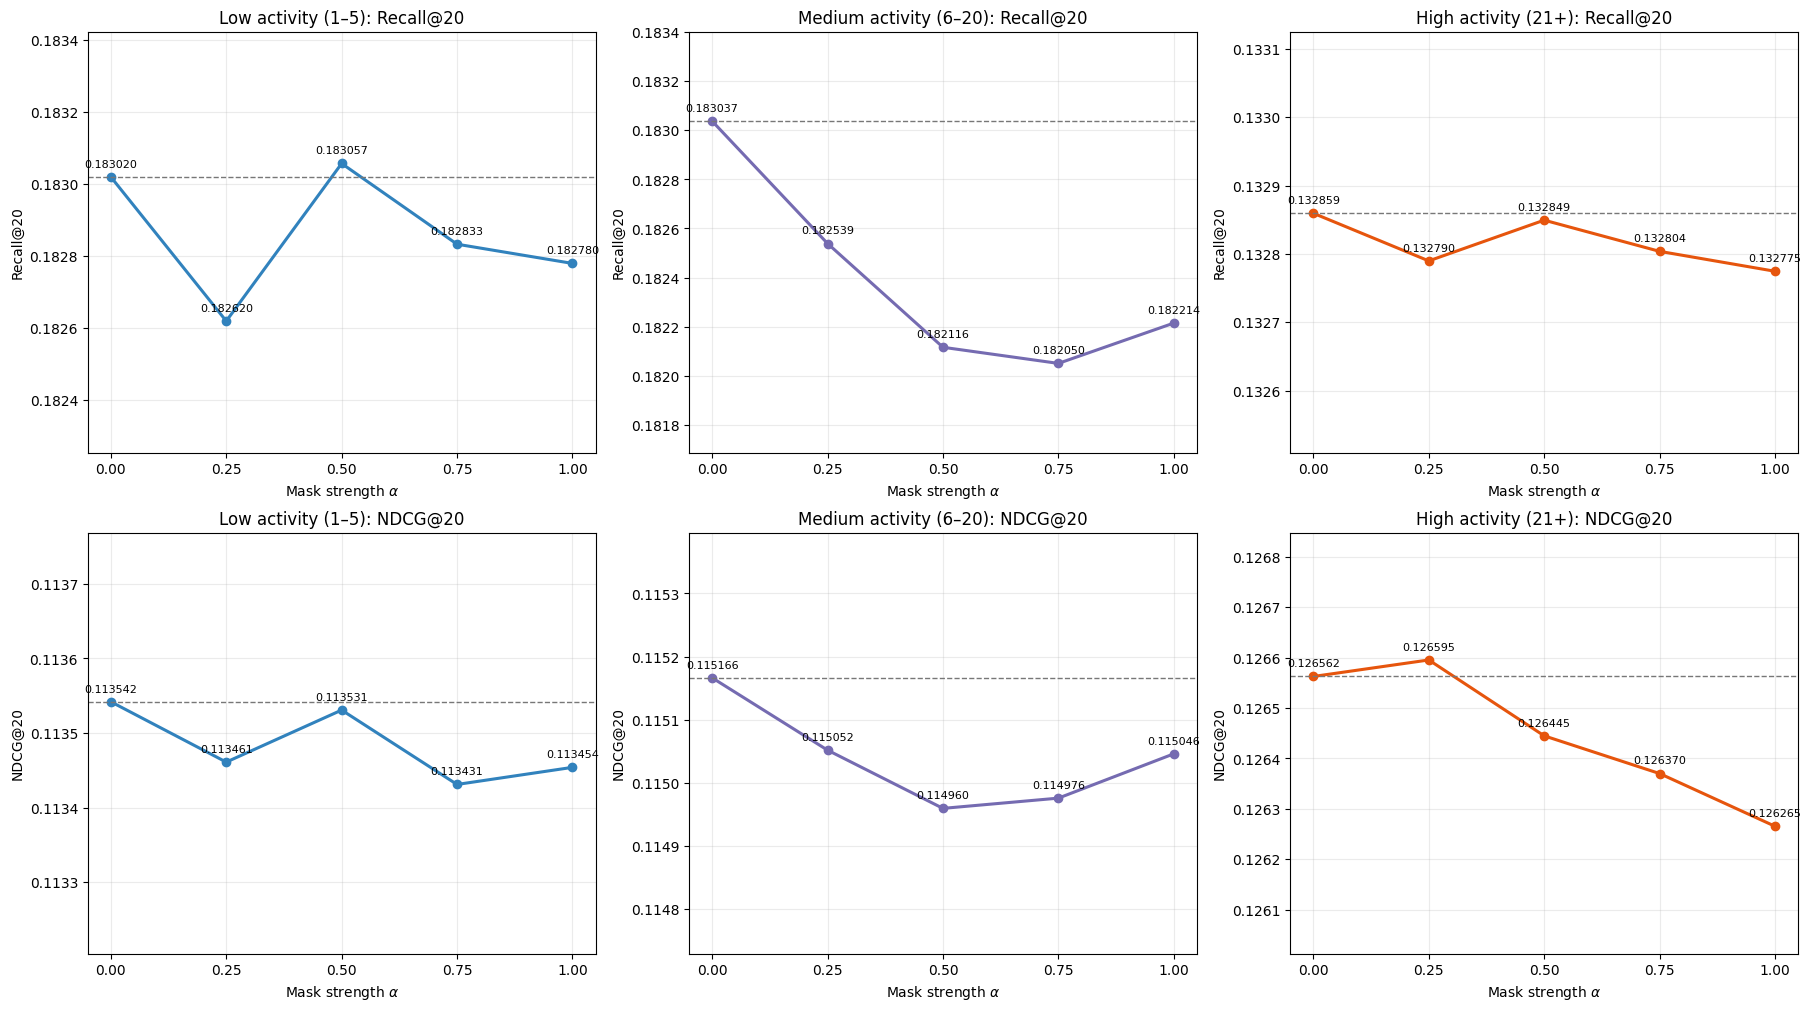

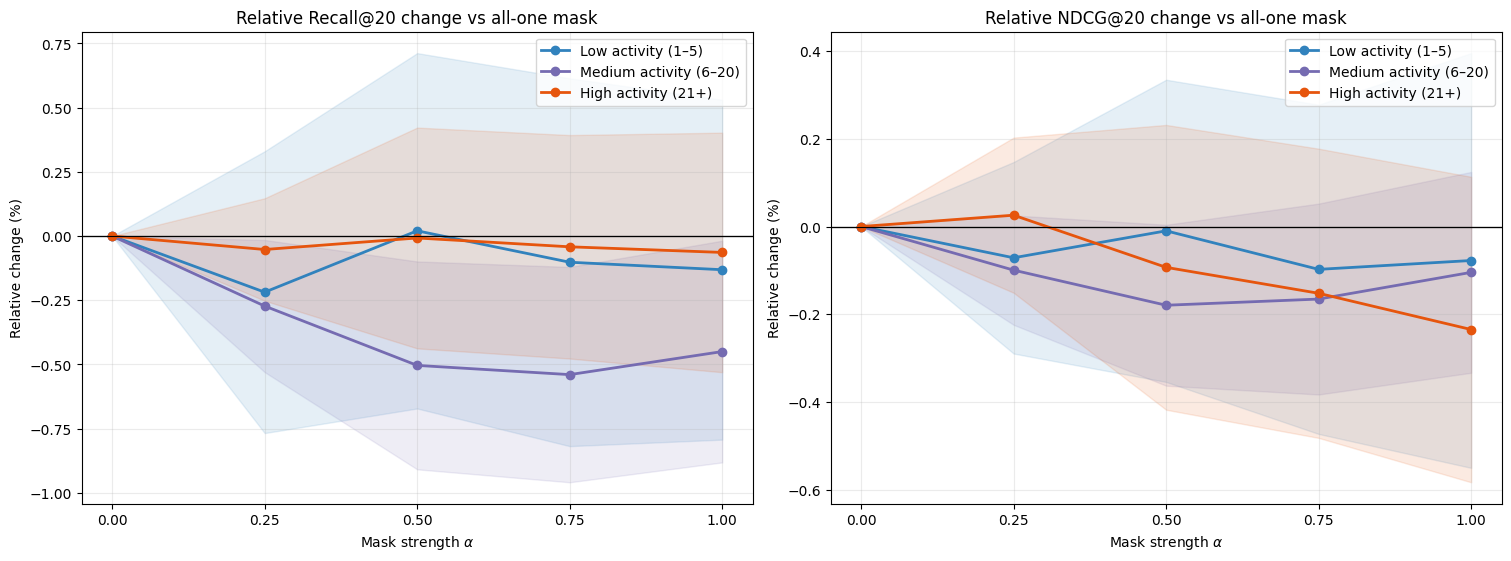

**Activity-specific mask-strength conclusions:**

- **Low activity (1–5):** learned-vs-all-one Recall -0.131%, NDCG -0.077%; both metric differences are inconclusive.
- **Medium activity (6–20):** learned-vs-all-one Recall -0.450%, NDCG -0.104%; the inference-time effect is metric-dependent.
- **High activity (21+):** learned-vs-all-one Recall -0.064%, NDCG -0.235%; both metric differences are inconclusive.

In [28]:
display(Markdown("## 15. Mask-strength curves by user activity"))

ACTIVITY_MASK_STRENGTH_GROUPS = [
    ("Low activity", "1–5", 1, 5),
    ("Medium activity", "6–20", 6, 20),
    ("High activity", "21+", 21, None),
]

activity_strength_required = (
    "mask_strength_results", "evaluation_user_ids", "user_degree",
    "model_mask_values", "paired_mean_ci95", "GROUP_METRIC_K",
    "show_markdown_table",
)
activity_strength_missing = [
    name for name in activity_strength_required if name not in globals()
]
if activity_strength_missing:
    raise RuntimeError(
        f"Missing {activity_strength_missing}. Run Analysis 14 first."
    )

activity_strength_eval_degrees = np.asarray(
    user_degree[evaluation_user_ids], dtype=np.int64
)
activity_strength_eval_masks = np.asarray(
    model_mask_values[evaluation_user_ids], dtype=np.float64
)
if activity_strength_eval_degrees.shape != evaluation_user_ids.shape:
    raise ValueError("Evaluation users and degree values are not aligned.")
for result in mask_strength_results:
    if not (
        np.asarray(result["recall_per_user"]).shape == evaluation_user_ids.shape
        and np.asarray(result["ndcg_per_user"]).shape == evaluation_user_ids.shape
    ):
        raise ValueError(f"Per-user metrics are not aligned at alpha={result['alpha']}.")

activity_strength_membership = np.zeros(evaluation_user_ids.size, dtype=np.int64)
activity_strength_group_results = []
activity_strength_summary_rows = []
activity_strength_curve_rows = []
activity_strength_endpoint_rows = []

for activity_label, degree_label, lower, upper in ACTIVITY_MASK_STRENGTH_GROUPS:
    if upper is None:
        group_rows = activity_strength_eval_degrees >= lower
    else:
        group_rows = (activity_strength_eval_degrees >= lower) & (
            activity_strength_eval_degrees <= upper
        )
    if not group_rows.any():
        raise ValueError(f"Activity group {degree_label} contains no evaluated users.")
    activity_strength_membership += group_rows.astype(np.int64)

    group_degrees = activity_strength_eval_degrees[group_rows]
    group_learned_masks = activity_strength_eval_masks[group_rows]
    baseline_recall_per_user = mask_strength_results[0]["recall_per_user"][group_rows]
    baseline_ndcg_per_user = mask_strength_results[0]["ndcg_per_user"][group_rows]
    baseline_recall = baseline_recall_per_user.mean()
    baseline_ndcg = baseline_ndcg_per_user.mean()
    group_curve = []

    for result in mask_strength_results:
        alpha = result["alpha"]
        recall_per_user = result["recall_per_user"][group_rows]
        ndcg_per_user = result["ndcg_per_user"][group_rows]
        recall = recall_per_user.mean()
        ndcg = ndcg_per_user.mean()
        recall_diff, recall_ci_low, recall_ci_high = paired_mean_ci95(
            recall_per_user - baseline_recall_per_user
        )
        ndcg_diff, ndcg_ci_low, ndcg_ci_high = paired_mean_ci95(
            ndcg_per_user - baseline_ndcg_per_user
        )
        recall_relative = recall_diff / baseline_recall * 100.0
        ndcg_relative = ndcg_diff / baseline_ndcg * 100.0
        recall_relative_ci = np.asarray(
            [recall_ci_low, recall_ci_high]
        ) / baseline_recall * 100.0
        ndcg_relative_ci = np.asarray(
            [ndcg_ci_low, ndcg_ci_high]
        ) / baseline_ndcg * 100.0
        effective_group_mask = 1.0 - alpha * (1.0 - group_learned_masks)
        curve_point = {
            "alpha": alpha, "effective_mask_mean": effective_group_mask.mean(),
            "recall": recall, "recall_diff": recall_diff,
            "recall_ci_low": recall_ci_low, "recall_ci_high": recall_ci_high,
            "recall_relative": recall_relative,
            "recall_relative_ci": recall_relative_ci,
            "ndcg": ndcg, "ndcg_diff": ndcg_diff,
            "ndcg_ci_low": ndcg_ci_low, "ndcg_ci_high": ndcg_ci_high,
            "ndcg_relative": ndcg_relative,
            "ndcg_relative_ci": ndcg_relative_ci,
        }
        group_curve.append(curve_point)
        activity_strength_curve_rows.append(
            [
                activity_label, degree_label, f"{alpha:.2f}",
                f"{effective_group_mask.mean():.8f}", f"{recall:.8f}",
                f"{recall_relative:+.4f}%", f"{ndcg:.8f}",
                f"{ndcg_relative:+.4f}%",
            ]
        )

    group_result = {
        "activity": activity_label, "degree_group": degree_label,
        "rows": group_rows, "users": int(group_rows.sum()),
        "mean_degree": group_degrees.mean(),
        "median_degree": np.median(group_degrees),
        "mean_learned_mask": group_learned_masks.mean(),
        "mean_learned_attenuation": (1.0 - group_learned_masks).mean(),
        "curve": group_curve,
    }
    activity_strength_group_results.append(group_result)
    activity_strength_summary_rows.append(
        [
            activity_label, degree_label, f"{group_rows.sum():,}",
            f"{group_degrees.mean():.3f}", f"{np.median(group_degrees):.1f}",
            f"{group_learned_masks.mean():.8f}",
            f"{(1.0 - group_learned_masks).mean():.8f}",
        ]
    )

    learned_endpoint = group_curve[-1]
    activity_strength_endpoint_rows.append(
        [
            activity_label, degree_label,
            f"{group_curve[0]['recall']:.8f}", f"{learned_endpoint['recall']:.8f}",
            f"{learned_endpoint['recall_diff']:+.8f} "
            f"[{learned_endpoint['recall_ci_low']:+.8f}, "
            f"{learned_endpoint['recall_ci_high']:+.8f}]",
            f"{learned_endpoint['recall_relative']:+.4f}%",
            f"{group_curve[0]['ndcg']:.8f}", f"{learned_endpoint['ndcg']:.8f}",
            f"{learned_endpoint['ndcg_diff']:+.8f} "
            f"[{learned_endpoint['ndcg_ci_low']:+.8f}, "
            f"{learned_endpoint['ndcg_ci_high']:+.8f}]",
            f"{learned_endpoint['ndcg_relative']:+.4f}%",
        ]
    )

if not np.all(activity_strength_membership == 1):
    raise RuntimeError("Low/medium/high activity groups must cover every test user once.")

show_markdown_table(
    [
        "activity", "degree group", "test users", "mean degree", "median degree",
        r"mean learned $m_u$", r"mean learned $1-m_u$",
    ],
    activity_strength_summary_rows,
)
show_markdown_table(
    [
        "activity", "degree group", r"$\alpha$", r"mean effective $m_u$",
        f"Recall@{GROUP_METRIC_K}", r"relative $\Delta R$ vs $\alpha=0$",
        f"NDCG@{GROUP_METRIC_K}", r"relative $\Delta N$ vs $\alpha=0$",
    ],
    activity_strength_curve_rows,
)
show_markdown_table(
    [
        "activity", "degree group", r"R at $\alpha=0$", r"R at $\alpha=1$",
        r"paired $\Delta R$ [95% CI]", r"relative $\Delta R$",
        r"N at $\alpha=0$", r"N at $\alpha=1$",
        r"paired $\Delta N$ [95% CI]", r"relative $\Delta N$",
    ],
    activity_strength_endpoint_rows,
)

activity_curve_colors = ["#3182bd", "#756bb1", "#e6550d"]
figure, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
for column, (group_result, color) in enumerate(
    zip(activity_strength_group_results, activity_curve_colors)
):
    group_alphas = np.asarray([point["alpha"] for point in group_result["curve"]])
    for row_index, (metric_prefix, metric_title) in enumerate(
        (("recall", f"Recall@{GROUP_METRIC_K}"), ("ndcg", f"NDCG@{GROUP_METRIC_K}"))
    ):
        ax = axes[row_index, column]
        values = np.asarray([point[metric_prefix] for point in group_result["curve"]])
        ax.plot(group_alphas, values, marker="o", linewidth=2.2, color=color)
        ax.axhline(values[0], color="#777777", linestyle="--", linewidth=1)
        for alpha, value in zip(group_alphas, values):
            ax.annotate(
                f"{value:.6f}", (alpha, value), xytext=(0, 7),
                textcoords="offset points", ha="center", fontsize=8,
            )
        value_span = values.max() - values.min()
        padding = max(value_span * 0.35, max(abs(values.mean()), 1e-6) * 0.002)
        ax.set_ylim(values.min() - padding, values.max() + padding)
        ax.set(
            title=f"{group_result['activity']} ({group_result['degree_group']}): {metric_title}",
            xlabel=r"Mask strength $\alpha$", ylabel=metric_title, xticks=group_alphas,
        )
        ax.grid(alpha=0.25)
plt.show()

figure, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)
for group_result, color in zip(activity_strength_group_results, activity_curve_colors):
    group_alphas = np.asarray([point["alpha"] for point in group_result["curve"]])
    for ax, metric_prefix, metric_title in (
        (axes[0], "recall", f"Recall@{GROUP_METRIC_K}"),
        (axes[1], "ndcg", f"NDCG@{GROUP_METRIC_K}"),
    ):
        relative_values = np.asarray(
            [point[f"{metric_prefix}_relative"] for point in group_result["curve"]]
        )
        relative_cis = np.asarray(
            [point[f"{metric_prefix}_relative_ci"] for point in group_result["curve"]]
        )
        ax.plot(
            group_alphas, relative_values, marker="o", linewidth=2, color=color,
            label=f"{group_result['activity']} ({group_result['degree_group']})",
        )
        ax.fill_between(
            group_alphas, relative_cis[:, 0], relative_cis[:, 1], color=color, alpha=0.12
        )
        ax.set(
            title=f"Relative {metric_title} change vs all-one mask",
            xlabel=r"Mask strength $\alpha$", ylabel="Relative change (%)",
            xticks=group_alphas,
        )
        ax.axhline(0, color="black", linewidth=0.8)
        ax.grid(alpha=0.25)
        ax.legend()
plt.show()

activity_strength_conclusions = []
for group_result in activity_strength_group_results:
    endpoint = group_result["curve"][-1]
    recall_learned_better = endpoint["recall_ci_low"] > 0
    recall_all_one_better = endpoint["recall_ci_high"] < 0
    ndcg_learned_better = endpoint["ndcg_ci_low"] > 0
    ndcg_all_one_better = endpoint["ndcg_ci_high"] < 0
    if recall_learned_better and ndcg_learned_better:
        interpretation = "learned mask reliably improves both metrics"
    elif recall_all_one_better and ndcg_all_one_better:
        interpretation = "all-one mask reliably improves both metrics"
    elif not any((recall_learned_better, recall_all_one_better,
                  ndcg_learned_better, ndcg_all_one_better)):
        interpretation = "both metric differences are inconclusive"
    else:
        interpretation = "the inference-time effect is metric-dependent"
    activity_strength_conclusions.append(
        f"- **{group_result['activity']} ({group_result['degree_group']}):** "
        f"learned-vs-all-one Recall {endpoint['recall_relative']:+.3f}%, "
        f"NDCG {endpoint['ndcg_relative']:+.3f}%; {interpretation}."
    )
display(
    Markdown(
        "**Activity-specific mask-strength conclusions:**\n\n"
        + "\n".join(activity_strength_conclusions)
    )
)